# EIT Continuous Model Complex-Valued Tests

This work aims to set first tests with EIT implementantion using FENICSx library, aiming to solve the complex valued case, explaining some of the fundamentals in the library implementation. In this context, we will be using the Continuous Model, testing initially with trivial simulated functions and simple meshes, adding more information and complexity as advancing.

More information and explanations about some steps can be seen in the FENICSx tutorial: https://jsdokken.com/dolfinx-tutorial/chapter1/complex_mode.html.

# Implementation - Direct Problem



## Importing

Run the following blocks to install and import all the libraries required.

In [1]:
try:
    import gmsh
except ImportError:
#     !wget "https://github.com/fem-on-colab/fem-on-colab.github.io/raw/75de0a3/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
    import gmsh

try:
    import dolfinx
except ImportError:
#   !wget "https://github.com/fem-on-colab/fem-on-colab.github.io/raw/75de0a3/releases/fenicsx-install-complex.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
  import dolfinx

try:
    import pyvista
except ImportError:
#     !wget "https://fem-on-colab.github.io/releases/vtk-install.sh" -O "/tmp/vtk-install.sh" && bash "/tmp/vtk-install.sh"
    import pyvista

pyvista.set_jupyter_backend("static")

import sys
import dolfinx
from mpi4py import MPI #import parallel communicator
import numpy as np
import ufl
import matplotlib.pyplot as plt
import dolfinx.fem.petsc
from dolfinx.io import gmshio
import time
import pandas as pd
import scipy as sp
import basix

print("Python version: ", sys.version)
print(f"DOLFINx version: {dolfinx.__version__} based on GIT commit: {dolfinx.git_commit_hash} of https://github.com/FEniCS/dolfinx/")


#Check type of number set in PETSc lib, returns error if not complex
from petsc4py import PETSc #Linear algebra lib
print(PETSc.ScalarType)
assert np.dtype(PETSc.ScalarType).kind == 'c'

Python version:  3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0]
DOLFINx version: 0.8.0 based on GIT commit: ubuntu of https://github.com/FEniCS/dolfinx/
<class 'numpy.complex128'>


## Setup

The block below sums up all the setup info and auxiliary functions used for solving the problem. Details and discuss on implementations are listed in the notes and code blocks along the archive.

In [2]:
# trecho do código do Eduardo
class electrodes_position():
    """
    Object that contains the position of the electrodes in the boundary.
    The position is stored as the initial and final angles of each electrode.

    :param L: Number of electrodes.
    :type L: int
    :param per_cober: Percentual covered length in the boundary by electrodes, between 0 and 1.
    :type per_cober: float
    :param rotate: Rotation angle in the original solution for electrodes (in radians).
    :type rotate: float
    :param anticlockwise: If True, the electrodes are positioned anticlockwise, else clockwise.
    :type anticlockwise: bool, optional (default is True)
    """

    def __init__(self, L, per_cober, rotate, anticlockwise=True):
        #Checks
        if not isinstance(L, int): raise ValueError("Number of electrodes must be an integer.")
        if not isinstance(per_cober, float): raise ValueError("per_cober must be a float.")
        if not isinstance(rotate, (int, float)): raise ValueError("rotate must be a float.")
        if not isinstance(anticlockwise, bool): raise ValueError("anticlockwise must be true of false.")
        if per_cober>1: raise ValueError("per_cober must be equal or less than 1. Example (75%): per_cober=0.75 ")

        self.rotate=rotate
        self.L=L
        self.per_cober=per_cober
        self.anticlockwise=anticlockwise

        self.position=self.calc_position()
        self.coordinates = [((np.cos(electrode[0]),np.sin(electrode[0])), (np.cos(electrode[1]),np.sin(electrode[1]))) for electrode in self.position]


    def calc_position(self):
        """
        Calculate the position of electrodes based on the :class:`electrodes_position` object.

        :returns: list of arrays -- Returns a list with angle initial and final of each electrode.
        """
        size_e=2*np.pi/self.L*self.per_cober       #Size electrodes
        size_gap=2*np.pi/self.L*(1-self.per_cober) #Size gaps
        rotate=self.rotate                      #Rotating original solution

        electrodes=[]
        for i in range(self.L):
            #Example electrodes=[[0, pi/4], [pi/2, pi]]
            electrodes.append([size_e*i+size_gap*i+rotate, size_e*(i+1)+size_gap*i+rotate]) #Grouping angular values for electrodes.
        if not self.anticlockwise:
            electrodes[1:] = electrodes[1:][::-1] #Keep first electrode and reverse order
        return electrodes


def setupMesh(electrodes,mesh_refining=1,bdr_refining=1):
  # if running again, you must remove the comment in the following
  gmsh.finalize()
  gmsh.initialize()
  disk = gmsh.model.occ.addDisk(0, 0, 0, 1, 1) #creates disk centered in (0,0,0) with axis (1,1)

  #create point list for electrodes.
  #primeiro, do jeito gambiarrento -
  electrodes_points = []
  for electrode in electrodes.position:
    theta_array = np.linspace(electrode[0],electrode[1],)
    electrodes_points.extend([gmsh.model.occ.addPoint(np.cos(theta),np.sin(theta),0) for theta in theta_array])

  gmsh.model.occ.synchronize()
  gdim = 2 #variable to control disk dimension, where 2 stands for surface
  gmsh.model.addPhysicalGroup(gdim, [disk], 1) # starts mesh object
  # gmsh.model.addPhysicalGroup(0, electrodes_points, 2) #electrodes

  gmsh.option.setNumber("Mesh.CharacteristicLengthMax",0.2 * mesh_refining) # control max length of cells
  gmsh.model.mesh.field.add("Distance", 1)
  gmsh.model.mesh.field.setNumbers(1, "PointsList", electrodes_points)
  gmsh.model.mesh.field.add("Threshold", 2)
  gmsh.model.mesh.field.setNumber(2, "InField", 1)
  gmsh.model.mesh.field.setNumber(2, "SizeMin", 0.03 * bdr_refining)
  gmsh.model.mesh.field.setNumber(2, "SizeMax", 0.25 * bdr_refining )
  gmsh.model.mesh.field.setNumber(2, "DistMin", 0.075 * bdr_refining )
  gmsh.model.mesh.field.setNumber(2, "DistMax", 0.1 * bdr_refining)
  gmsh.model.mesh.field.add("Min", 3)
  gmsh.model.mesh.field.setNumbers(3, "FieldsList", [2])
  gmsh.model.mesh.field.setAsBackgroundMesh(3)
  gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
  gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
  gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
  gmsh.model.mesh.generate(gdim)

  return gmshio.model_to_mesh(gmsh.model, mesh_comm, gmsh_model_rank, gdim=2)


class DirectProblem:
  def __init__(self, mesh: dolfinx.mesh.Mesh, L: int, ds: ufl.measure.Measure):
    self.mesh = mesh
    Ve = basix.ufl.element('Lagrange', "triangle", degree=1, shape=())
    V0e = basix.ufl.element('Discontinuous Lagrange', "triangle", degree=0, shape=())

    self.V0 = dolfinx.fem.functionspace(self.mesh, V0e)
    self.V = dolfinx.fem.functionspace(self.mesh, Ve)
    self.ds = ds
    self.L = L

    self.N = self.V.dofmap.index_map.size_global
    self.K = self.V0.dofmap.index_map.size_global

    self.assembled = False
    self.solved = False
    self.adjoint_set = False

  def set_problem(self, gamma, z_value):
    """
      Assemble operator matrix based on gamma and z informed
      Matrix A^H@A is saved in scipy csr sparse type object
    """
    V0 = self.V0
    self.gamma = gamma
    self.z_value = z_value

    z = dolfinx.fem.Constant(self.mesh, PETSc.ScalarType(z_value))

    u = ufl.TrialFunction(self.V) #function u_h
    v = ufl.TestFunction(self.V)

    gradu = ufl.grad(u)
    gradv = ufl.grad(v)

    #A1
    A1_sum_array = [(1/z)*ufl.inner(u,v)*self.ds(i) for i in range(self.L)]
    A1_form = (self.gamma * ufl.inner(gradu, gradv)) * ufl.dx + np.sum(A1_sum_array)
    A1_form_obj = dolfinx.fem.form(A1_form)
    A1_matrix = dolfinx.fem.petsc.assemble_matrix(A1_form_obj)
    A1_matrix.assemble()

    ###
    #A2
    A2_form_array = [-ufl.inner((1/z), v) * self.ds(i) for i in range(self.L)]
    A2_form_obj = [dolfinx.fem.form(form) for form in A2_form_array]
    A2_vector_array= [dolfinx.fem.petsc.assemble_vector(form) for form in A2_form_obj]
    A2_np_matrix = np.stack(
      [A2_vector_array[j].getValues(range(self.N)) for j in range(self.L)],
      axis=1
    )
    # A2T_matrix = A2_matrix.transpose()
    # A2T_matrix.assemble()

    ###

    #Assemble A4
    cell_area_list = []
    for i in range(self.L):
      v = ufl.TrialFunction(V0) #trial object
      s = v*self.ds(i) # creates object of the form \int_{e_i} 1*ds
      cell_area_form = dolfinx.fem.form(s)
      cell_area = dolfinx.fem.assemble_scalar(cell_area_form)
      cell_area_list.append(cell_area.real)
    cell_area_array = np.array(cell_area_list)
    A4_diagonal = np.diag(cell_area_array*(1/z_value))

    A1_np_matrix = A1_matrix.getValues(range(self.N),range(self.N))
    
    self.A_np = np.block([[A1_np_matrix, A2_np_matrix],
                    [A2_np_matrix.T, A4_diagonal]])

    self.A_op = sp.sparse.csr_matrix(self.A_np.T.conj()@self.A_np)

    self.assembled = True
    self.adjoint_set = False


  def solve_problem_current(self, I_all,save=False):
    """
      Solve the normal problem (A^h A) u = (A^h) b, given the I_all current array
      Matrix needs to have been assembled through method `set_problem`

      Params:
      - I_all: list of current patterns

      Returns:
      - u_list: list of dolfinx.fem.Function objects, for each potentital distribution
      - U_list: list of np.array objects, for each measured potential pattern array
    """
    if not self.assembled:
      raise Exception("The problem operator has not been assembled")

    u_list = []
    u_array_list = []
    U_list = []

    l = len(I_all)

    for k in range(l):
      b = np.block([np.zeros(self.N),I_all[k]])
      u_nest = sp.sparse.linalg.spsolve(self.A_op,self.A_np.T.conj()@b) #Solve A^*Au = b
      u_array, U_array = u_nest[:self.N], u_nest[self.N:] #splitting array

      # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
      S = U_array.sum()
      U_array -= S/self.L
      u_array -= S/self.L

      u_array_list.append(u_array)
      U_list.append(U_array)

    for u_array in u_array_list:
      u = dolfinx.fem.Function(self.V)
      u.x.array[:] = u_array
      u_list.append(u)


    if save:
      self.u_list = u_list
      self.U_list = U_list

    return u_list, U_list


  def solve_problem_vector(self,vector_list, save=False):
    """
      Solve the normal problem (A^h A) u = (A^h) b, given the b vector list
      Useful for solving derivative problem, for example
      Matrix needs to have been assembled through method `set_problem`

      Params:
      - vector_list: list of current patterns

      Returns:
      - u_list: list of dolfinx.fem.Function objects, for each potentital distribution
      - U_list: list of np.array objects, for each measured potential pattern array
    """
    if not self.assembled:
      raise Exception("The problem operator has not been assembled")

    u_list = []
    u_array_list = []
    U_list = []

    for b in vector_list:
      u_nest = sp.sparse.linalg.spsolve(self.A_op,self.A_np.T.conj()@b) #Solve A^*Au = b
      u_array, U_array = u_nest[:self.N], u_nest[self.N:] #splitting array

      # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
      S = U_array.sum()
      U_array -= S/self.L
      u_array -= S/self.L

      u_array_list.append(u_array)
      U_list.append(U_array)

      for u_array in u_array_list:
        u = dolfinx.fem.Function(self.V)
        u.x.array[:] = u_array
        u_list.append(u)

      if save:
        self.u_list = u_list
        self.U_list = U_list

    return u_list, U_list

  def directional_derivative(self,eta,u_list=None,use_stored_u=False):
    if use_stored_u:
      if not self.solved:
        raise Exception("There is no stored solution yet")

      u_list = self.u_list

    #Create Trial and test functions
    w = ufl.TrialFunction(self.V) #function u_h
    v = ufl.TestFunction(self.V)

    L_array = []

    #creates object representing the gradient of w, us and v functions
    gradw = ufl.grad(w)
    gradv = ufl.grad(v)
    for us in u_list:
      gradus = ufl.grad(us)

      #creating form
      L_exp = - (eta * ufl.inner(gradus,gradv)) * ufl.dx
      L_form = dolfinx.fem.form(L_exp)

      #getting rhs vector
      L_vector = dolfinx.fem.petsc.assemble_vector(L_form)
      L_nparray = L_vector.getValues(range(L_vector.getSize()))

      L_array.append(np.block([L_nparray,np.zeros(L)]))


    ws, Ws = self.solve_problem_vector(L_array)
    return ws,Ws

  def adjoint(self, sigma_list, u_list):
    """
    Get sigma_list direction, returns F'(gamma)* sigma_list
    """
    if not self.adjoint_set:
      self.setAdjointProblem()

    psi_list, Psi_list  = self.problem_adj.solve_problem_current(sigma_list)
    grad_psi_list = [compute_gradient(psi) for psi in psi_list]
    grad_u_list = [compute_gradient(u) for u in u_list]
    adj = dolfinx.fem.Function(self.V0)
    adj_j_array = np.zeros_like(adj.x.array)

    for j in range(l):
      graduj = grad_u_list[j]
      gradpsij = grad_psi_list[j]

      for k in range(adj_j_array.shape[0]):
        adj_j_array[k] = - np.vdot(graduj[k],gradpsij[k])

      adj.x.array[:] += adj_j_array

    return adj

  def setAdjointProblem(self):
    gamma_conj = dolfinx.fem.Function(self.V0)
    gamma_conj.x.array[:] = self.gamma.x.array.conj()
    problem2 = DirectProblem(self.mesh,self.L,self.ds)
    problem2.set_problem(gamma_conj,np.conj(self.z_value))
    self.problem_adj = DirectProblem(self.mesh,self.L,self.ds)
    self.problem_adj.set_problem(gamma_conj,np.conj(self.z_value))
    self.adjoint_set = True

def plot_mesh(mesh):
  # Ploting mesh

  p = pyvista.Plotter(notebook=True)
  grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh))
  p.add_mesh(grid, show_edges=True)
  p.view_xy()
  if pyvista.OFF_SCREEN:
      figure = p.screenshot("disk.png")
  p.show()

# gets theta of (x,y) in polar coord. (r,theta), with theta in interval [0,2pi]
def theta(x):
  r = (x[0]**2 + x[1]**2)**(0.5)
  inv_r = np.where(np.isclose(r,0),0,1/r)
  return np.where(x[1]>=0,np.arccos(x[0]*inv_r),2*np.pi - np.arccos(x[0]*inv_r))

def setupIntegrationDomain(mesh, electrodes):
  tol = 0.01 # tolerance for checking if in electordes

  #setting boundaries markers and indicator functions
  boundaries = [
      (i, lambda x,i=i: np.where(np.logical_and(theta(x)>=electrodes.position[i][0]-tol,theta(x)<=electrodes.position[i][1]+tol),1,0))
      for i in range(L)
  ]
  #creating facet tags
  bdr_facet_indices, bdr_facet_markers = [], []
  for (marker, locator) in boundaries:
      facets = dolfinx.mesh.locate_entities(mesh, mesh.topology.dim - 1, locator)
      bdr_facet_indices.append(facets)
      bdr_facet_markers.append(np.full_like(facets, marker))
  bdr_facet_indices = np.hstack(bdr_facet_indices).astype(np.int32)
  bdr_facet_markers = np.hstack(bdr_facet_markers).astype(np.int32)
  sorted_facets = np.argsort(bdr_facet_indices)
  facet_tag = dolfinx.mesh.meshtags(mesh, mesh.topology.dim - 1, bdr_facet_indices[sorted_facets], bdr_facet_markers[sorted_facets])

  return ufl.Measure("ds", domain=mesh, subdomain_data=facet_tag)

def plot_tent_function(u):
  # Ploting
  V_u = u.function_space
  p = pyvista.Plotter(notebook=True)
  grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(V_u))
  grid.point_data["u"] = u.x.array.real
  grid.set_active_scalars("u")
  p.add_mesh(grid, show_edges=True)
  p.view_xy()
  if pyvista.OFF_SCREEN:
      figure = p.screenshot("disk.png")
  p.show()

def plot_indicator_function(u):
  # Ploting
  u_mesh = u.function_space.mesh

  p = pyvista.Plotter(notebook=True)

  grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(u_mesh))
  grid.cell_data["u"] = u.x.array.real
  grid.set_active_scalars("u")
  p.add_mesh(grid, show_edges=True)
  p.view_xy()
  if pyvista.OFF_SCREEN:
      figure = p.screenshot("disk.png")
  p.show()

def get_boundary_data(u):
  """
  Returns an array of function values on boundary, ordered by the angle theta
  """
  V = u.function_space
  domain = V.mesh
  domain.topology.create_connectivity(domain.topology.dim-1, domain.topology.dim)
  boundary_facets = dolfinx.mesh.exterior_facet_indices(domain.topology)
  boundary_dofs_index_array = dolfinx.fem.locate_dofs_topological(V, domain.topology.dim-1, boundary_facets) #array with the vertices index
  #gets x and y coordinates for the boundary
  dofs_coordinates = V.tabulate_dof_coordinates()
  x_bdr = dofs_coordinates[boundary_dofs_index_array][:,0]
  y_bdr = dofs_coordinates[boundary_dofs_index_array][:,1]

  #gets the t in [0,2pi] from the corresponding (x,y) coordinates
  #next, gets the index of the sorted t array
  theta = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))
  sorted_theta_index = np.argsort(theta)
  return u.x.array[boundary_dofs_index_array][sorted_theta_index]

def compute_gradient(u: dolfinx.fem.Function):
  """
  Compute gradient of some tent space function
  Returns coordinates of gradient in each triangle, with array order
  beeing the same of the corresponding indicator function space
  """

  mesh = u.function_space.mesh
  adjacency_list = mesh.topology.connectivity(2,0)
  mesh_vertex_index_list = []
  for i in range(len(adjacency_list)):
    mesh_vertex_index_list.append(adjacency_list.links(i))

  cells_coordinates_list = []
  for cell_vertex_index in mesh_vertex_index_list:
    cells_coordinates_list.append(mesh.geometry.x[cell_vertex_index][:,:2])

  gradient_list = []

  for idx in mesh_vertex_index_list:
    cell_coord = mesh.geometry.x[idx][:,:2]
    system_array = np.concatenate((cell_coord,np.ones(3).reshape(3,1)),axis=1)
    u_t = u.x.array[idx]
    plane_coef = np.linalg.solve(system_array, u_t)
    gradu = plane_coef[:2]
    # gradu_x, gradu_y = plane_coef[0],plane_coef[1]

    gradient_list.append(gradu)

  return np.array(gradient_list)

def funcProduct(u,v):
  product = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(u,v) * ufl.dx))
  return product

def funcSquareNorm(u):
  return dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(u,u) * ufl.dx))

def current_method(L,l, method=1, value=1):
    """
    Create a numpy array (or a list of arrays) that represents the current pattern in the electrodes.

    :param L: Number of electrodes.
    :type L: int
    :param l: Number of measurements.
    :type l: int
    :param method: Current pattern. Possible values are 1, 2, 3, or 4 (default=1).
    :type method: int
    :param value: Current density value (default=1).
    :type value: int or float

    :returns: list of arrays or numpy array -- Return list with current density in each electrode for each measurement.

    :Method Values:
        1. 1 and -1 in opposite electrodes.
        2. 1 and -1 in adjacent electrodes.
        3. 1 in one electrode and -1/(L-1) for the rest.
        4. For measurement k, we have: (sin(k*2*pi/16) sin(2*k*2*pi/16) ... sin(16*k*2*pi/16)).

    :Example:

    Create current pattern 1 with 4 measurements and 4 electrodes:

    >>> I_all = current_method(L=4, l=4, method=1)
    >>> print(I_all)
        [array([ 1.,  0., -1.,  0.]),
        array([ 0.,  1.,  0., -1.]),
        array([-1.,  0.,  1.,  0.]),
        array([ 0., -1.,  0.,  1.])]

    Create current pattern 2 with 4 measurements and 4 electrodes:

    >>> I_all = current_method(L=4, l=4, method=2)
    >>> print(I_all)
        [array([ 1., -1.,  0.,  0.]),
        array([ 0.,  1., -1.,  0.]),
        array([0.,  0.,  1., -1.]),
        array([ 1.,  0.,  0., -1.])]

    """
    I_all=[]
    #Type "(1,0,0,0,-1,0,0,0)"
    if method==1:
        if L%2!=0: raise Exception("L must be odd.")

        for i in range(l):
            if i<=L/2-1:
                I=np.zeros(L)
                I[i], I[i+int(L/2)]=value, -value
                I_all.append(I)
            elif i==L/2:
                print("This method only accept until L/2 currents, returning L/2 currents.")
    #Type "(1,-1,0,0...)"
    if method==2:
        for i in range(l):
            if i!=L-1:
                I=np.zeros(L)
                I[i], I[i+1]=value, -value
                I_all.append(I)
            else:
                I=np.zeros(L)
                I[0], I[i]=-value, value
                I_all.append(I)
    #Type "(1,-1/15, -1/15, ....)"
    if method==3:
        for i in range(l):
            I=np.ones(L)*-value/(L-1)
            I[i]=value
            I_all.append(I)
    #Type "(sin(k*2*pi/16) sin(2*k*2*pi/16) ... sin(16*k*2*pi/16))"
    # if method==4:
    #     for i in range(l):
    #         I=np.ones(L)
    #         for k in range(L): I[k]=I[k]*sin((i+1)*(k+1)*2*pi/L)
    #         I_all.append(I)

    return I_all

In [3]:
L=8
perc=0.5

mesh_refining = 0.3 #scaling factor for all domain refinement
bdr_refining = 0.4 # scaling factor for border refining

gmsh_model_rank = 0
mesh_comm = MPI.COMM_WORLD

electrodes = electrodes_position(L,perc,0)
mesh, cell_markers, facet_markers = setupMesh(electrodes,mesh_refining,bdr_refining)
pyvista.start_xvfb()
pyvista.set_jupyter_backend("static")


topology, cell_types, x = dolfinx.plot.vtk_mesh(mesh) #convert dolfin mesh to vtk (plotting lib) manageable object
ds = setupIntegrationDomain(mesh,electrodes)


Error   : Gmsh has not been initialized


Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0282595s, CPU 0.02279s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.286357s, CPU 0.241922s)
Info    : 2511 nodes 4621 elements


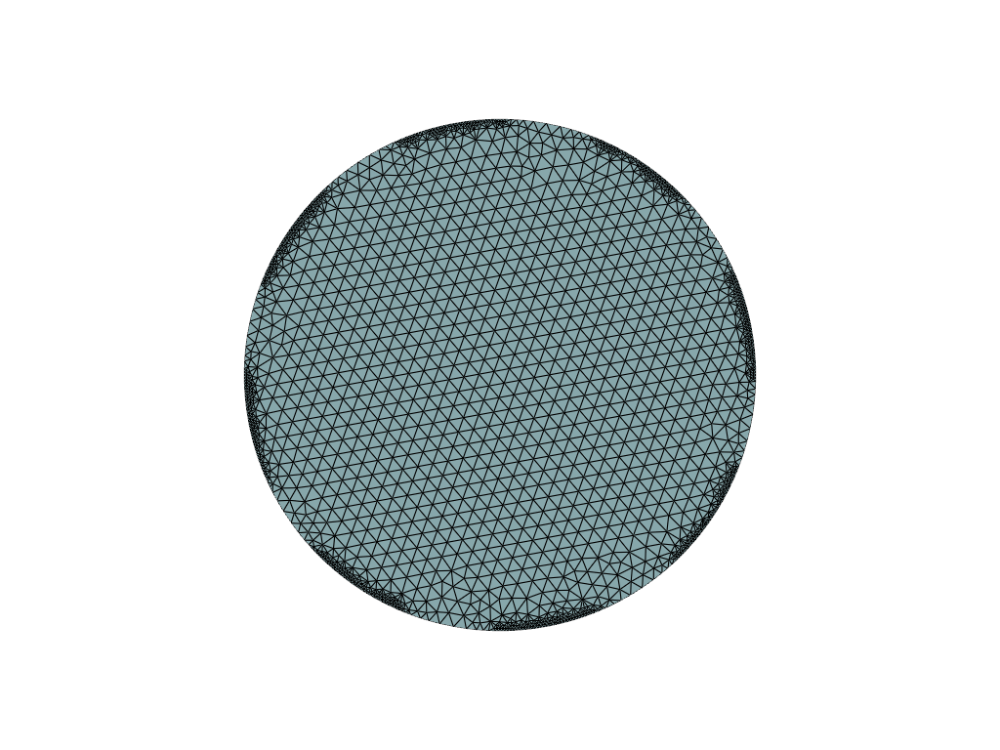

In [4]:
plot_mesh(mesh)

# Setting mesh

## Finding Eletrodes

In [ ]:
# trecho do código do Eduardo
class electrodes_position():
    """
    Object that contains the position of the electrodes in the boundary.
    The position is stored as the initial and final angles of each electrode.

    :param L: Number of electrodes.
    :type L: int
    :param per_cober: Percentual covered length in the boundary by electrodes, between 0 and 1.
    :type per_cober: float
    :param rotate: Rotation angle in the original solution for electrodes (in radians).
    :type rotate: float
    :param anticlockwise: If True, the electrodes are positioned anticlockwise, else clockwise.
    :type anticlockwise: bool, optional (default is True)

    :Example:
        >>> ele_pos = electrodes_position(L=16, per_cober=0.5, rotate=0)
        >>> print(ele_pos.position)
        [[0.0, 0.19634954084936207],
         [0.39269908169872414, 0.5890486225480862],
         [0.7853981633974483, 0.9817477042468103],
         [1.1780972450961724, 1.3744467859455345],
         [1.5707963267948966, 1.7671458676442586],
         ...,
         [5.890486225480862, 6.086835766330224]]
    """

    def __init__(self, L, per_cober, rotate, anticlockwise=True):
        #Checks
        if not isinstance(L, int): raise ValueError("Number of electrodes must be an integer.")
        if not isinstance(per_cober, float): raise ValueError("per_cober must be a float.")
        if not isinstance(rotate, (int, float)): raise ValueError("rotate must be a float.")
        if not isinstance(anticlockwise, bool): raise ValueError("anticlockwise must be true of false.")
        if per_cober>1: raise ValueError("per_cober must be equal or less than 1. Example (75%): per_cober=0.75 ")

        self.rotate=rotate
        self.L=L
        self.per_cober=per_cober
        self.anticlockwise=anticlockwise

        self.position=self.calc_position()


    def calc_position(self):
        """
        Calculate the position of electrodes based on the :class:`electrodes_position` object.

        :returns: list of arrays -- Returns a list with angle initial and final of each electrode.
        """
        size_e=2*np.pi/self.L*self.per_cober       #Size electrodes
        size_gap=2*np.pi/self.L*(1-self.per_cober) #Size gaps
        rotate=self.rotate                      #Rotating original solution

        electrodes=[]
        for i in range(self.L):
            #Example electrodes=[[0, pi/4], [pi/2, pi]]
            electrodes.append([size_e*i+size_gap*i+rotate, size_e*(i+1)+size_gap*i+rotate]) #Grouping angular values for electrodes.
        if not self.anticlockwise:
            electrodes[1:] = electrodes[1:][::-1] #Keep first electrode and reverse order
        return electrodes
L=16
perc=0.5

electrodes = electrodes_position(L,perc,0)
# print(electrodes.position)
#vetor com as coordenadas iniciais e finais de cada eletrodo
elec_coordinates = [((np.cos(electrode[0]),np.sin(electrode[0])), (np.cos(electrode[1]),np.sin(electrode[1]))) for electrode in electrodes.position]

In [ ]:
mesh_refining = 0.4 #scaling factor for all domain refinement
bdr_refining = 0.6 # scaling factor for border refining

# if running again, you must remove the comment in the following
gmsh.finalize()
gmsh.initialize()
disk = gmsh.model.occ.addDisk(0, 0, 0, 1, 1) #creates disk centered in (0,0,0) with axis (1,1)

#create point list for electrodes.
#primeiro, do jeito gambiarrento -
electrodes_points = []
for electrode in electrodes.position:
  theta_array = np.linspace(electrode[0],electrode[1],)
  electrodes_points.extend([gmsh.model.occ.addPoint(np.cos(theta),np.sin(theta),0) for theta in theta_array])

gmsh.model.occ.synchronize()
gdim = 2 #variable to control disk dimension, where 2 stands for surface
gmsh.model.addPhysicalGroup(gdim, [disk], 1) # starts mesh object
# gmsh.model.addPhysicalGroup(0, electrodes_points, 2) #electrodes


gmsh.option.setNumber("Mesh.CharacteristicLengthMax",0.2 * mesh_refining) # control max length of cells
gmsh.model.mesh.field.add("Distance", 1)
gmsh.model.mesh.field.setNumbers(1, "PointsList", electrodes_points)
gmsh.model.mesh.field.add("Threshold", 2)
gmsh.model.mesh.field.setNumber(2, "InField", 1)
gmsh.model.mesh.field.setNumber(2, "SizeMin", 0.03 * bdr_refining)
gmsh.model.mesh.field.setNumber(2, "SizeMax", 0.25 * bdr_refining )
gmsh.model.mesh.field.setNumber(2, "DistMin", 0.075 * bdr_refining )
gmsh.model.mesh.field.setNumber(2, "DistMax", 0.1 * bdr_refining)
gmsh.model.mesh.field.add("Min", 3)
gmsh.model.mesh.field.setNumbers(3, "FieldsList", [2])
gmsh.model.mesh.field.setAsBackgroundMesh(3)
gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)
gmsh.model.mesh.generate(gdim)

#start graphic server
pyvista.start_xvfb()
gmsh_model_rank = 0
mesh_comm = MPI.COMM_WORLD

#convert gmsh created mesh to dolfin/fenics mesh objects
mesh, cell_markers, facet_markers = gmshio.model_to_mesh(gmsh.model, mesh_comm, gmsh_model_rank, gdim=gdim)
topology, cell_types, x = dolfinx.plot.vtk_mesh(mesh) #convert dolfin mesh to vtk (plotting lib) manageable object

## Plotting domain

static


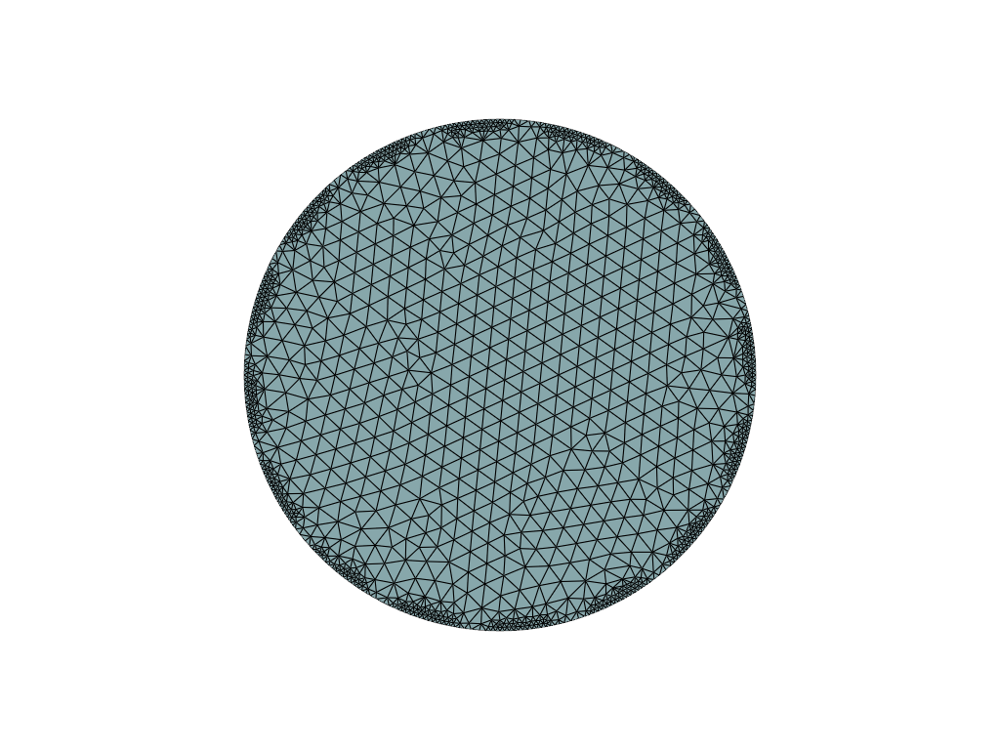

In [ ]:
#set value (plotting zero function in mesh)
num_cells_local = mesh.topology.index_map(mesh.topology.dim).size_local #get vertex array size
marker = np.zeros(num_cells_local, dtype=np.int32) #zero-full array, represents value in each vertex

# plotter object settings
# option "static" for static plots. Interactive options were not working properly in colab
pyvista.set_jupyter_backend("static")
print(pyvista.global_theme.jupyter_backend)

# Ploting mesh
p = pyvista.Plotter(notebook=True)
grid = pyvista.UnstructuredGrid(topology, cell_types, x)
p.add_mesh(grid, show_edges=True)
p.view_xy()
if pyvista.OFF_SCREEN:
    figure = p.screenshot("disk.png")
p.show()

## Getting integration domains

Based on the method explored in:
https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html

Basic idea:
- Create a indicator function for each domain, the electrodes in our case;
- Uses fenicsx `dolfinx.mesh.locate_entities(mesh, fdim, locator)` for listing the tags which lies in the electrodes;
- Creates a custom `ds` integration object, informing the electrodes tags. Then, it is possible to compute the integration in the $i-th$ domain by the command `f * ds(i)`.

In our code, the electrodes are located by their starting and ending angles, here stored in `electrodes.position` array. Then, we use the indicator function $f_k$ for the $k-th$ electrode. Beeing $\theta$ the boundary point angle, and given $\theta^{(k)}_i,\theta^{(k)}_f$ the starting and ending electrode angles respectively, $f_k(\theta)$ may be get by:
$$
f_k(\theta) = \begin{cases}
1, \text{if } \theta_i^{(k)} \leq \theta \leq \theta_f^{(k)} \\
0, else.
\end{cases}
$$

Here, as fenicsx inform an array of cartesian coordinates, we may get the corresponding $\theta$ by the function?
$$
\theta(x,y) = \begin{cases}
  \arccos(x), \text{ if } y\geq 0\\
  2\pi - \arccos(x), \text{ else}.
\end{cases}
$$
given $(x,y) = (r\cos(\theta),r\sin(\theta))$ with $\theta \in [0,2\pi )$.

In [6]:
# gets theta of (x,y) in polar coord. (r,theta), with theta in interval [0,2pi]
def theta(x):
  r = (x[0]**2 + x[1]**2)**(0.5)
  inv_r = np.where(np.isclose(r,0),0,1/r)
  return np.where(x[1]>=0,np.arccos(x[0]*inv_r),2*np.pi - np.arccos(x[0]*inv_r))

# Here is a tolerance for the test theta_i-tol <= theta <= theta_f
# this shown some better results on the integrations
tol = 0.01 # tolerance for checking if in electordes

#setting boundaries markers and indicator functions
boundaries = [
    (i, lambda x,i=i: np.where(np.logical_and(theta(x)>=electrodes.position[i][0]-tol,theta(x)<=electrodes.position[i][1]+tol),1,0))
    # (i, lambda x,i=i: np.where(theta(x)>=electrodes.position[i][0],1,0))
    for i in range(L)
]

#creating facet tags
facet_indices, facet_markers = [], []
fdim = mesh.topology.dim - 1
for (marker, locator) in boundaries:
    facets = dolfinx.mesh.locate_entities(mesh, fdim, locator)
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32)
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = dolfinx.mesh.meshtags(mesh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

In [7]:
# Create the `ds` object for integration domains
ds = ufl.Measure("ds", domain=mesh, subdomain_data=facet_tag)

### Testing domains

Testing integral over electrodes. Here, we compute
$$
\int_{e_i} 1 ds
$$
for each $e_i \subset \partial \Omega$ electrode, through the fenicsx functions
```
v = ufl.TrialFunction(V0)
s = v*ds(i)
```

Given the circular domain, with all electrodes having same side and covering a $0<p<1$ fraction of the boundary, we expect that

$$
\int_{e_i} 1 ds = \frac{2 \pi}{L}*p
$$

In [ ]:
#Computing "true" area
electrode_real_area = 2*np.pi/L * perc
print("Electrode area: ",electrode_real_area)

Electrode area:  0.19634954084936207


In [ ]:
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG", 0)) #Function space object

cell_area_list = []
for i in range(L):
  v = ufl.TrialFunction(V0) #trial object
  s = v*ds(i) # creates object of the form \int_{e_i} 1*ds

  cell_area_form = dolfinx.fem.form(s)
  cell_area = dolfinx.fem.assemble_scalar(cell_area_form)
  cell_area_list.append(cell_area.real)
  print("Electrode ", i ,": ", cell_area)

print("Sum:", sum(cell_area_list))

Electrode  0 :  (0.19170726283534886+0j)
Electrode  1 :  (0.19170726283534886+0j)
Electrode  2 :  (0.19170726283534897+0j)
Electrode  3 :  (0.1917072628353492+0j)
Electrode  4 :  (0.1917072628353487+0j)
Electrode  5 :  (0.1917072628353492+0j)
Electrode  6 :  (0.19170726283534917+0j)
Electrode  7 :  (0.19170726283534917+0j)
Electrode  8 :  (0.1917072628353483+0j)
Electrode  9 :  (0.1917072628353474+0j)
Electrode  10 :  (0.19170726283534878+0j)
Electrode  11 :  (0.1917072628353478+0j)
Electrode  12 :  (0.19170726283534875+0j)
Electrode  13 :  (0.19170726283534695+0j)
Electrode  14 :  (0.1917072628353469+0j)
Electrode  15 :  (0.1917072628353479+0j)
Sum: 3.0673162053655743


In [ ]:
cell_area_array = np.array(cell_area_list)
error_array = cell_area_array-electrode_real_area
print("Electrode length:", electrode_real_area)
electrode_area_df = pd.DataFrame({"Calculated area": cell_area_array,"Error": error_array})
electrode_area_df.head(n=L)

Electrode length: 0.19634954084936207


,Calculated area,Error
0,0.191707,-0.004642
1,0.191707,-0.004642
2,0.191707,-0.004642
3,0.191707,-0.004642
4,0.191707,-0.004642
5,0.191707,-0.004642
6,0.191707,-0.004642
7,0.191707,-0.004642
8,0.191707,-0.004642
9,0.191707,-0.004642


Here, ploting the indicator function in all domain. Note that we get not only on boundary, but interior, for where we get this "radial" plot.

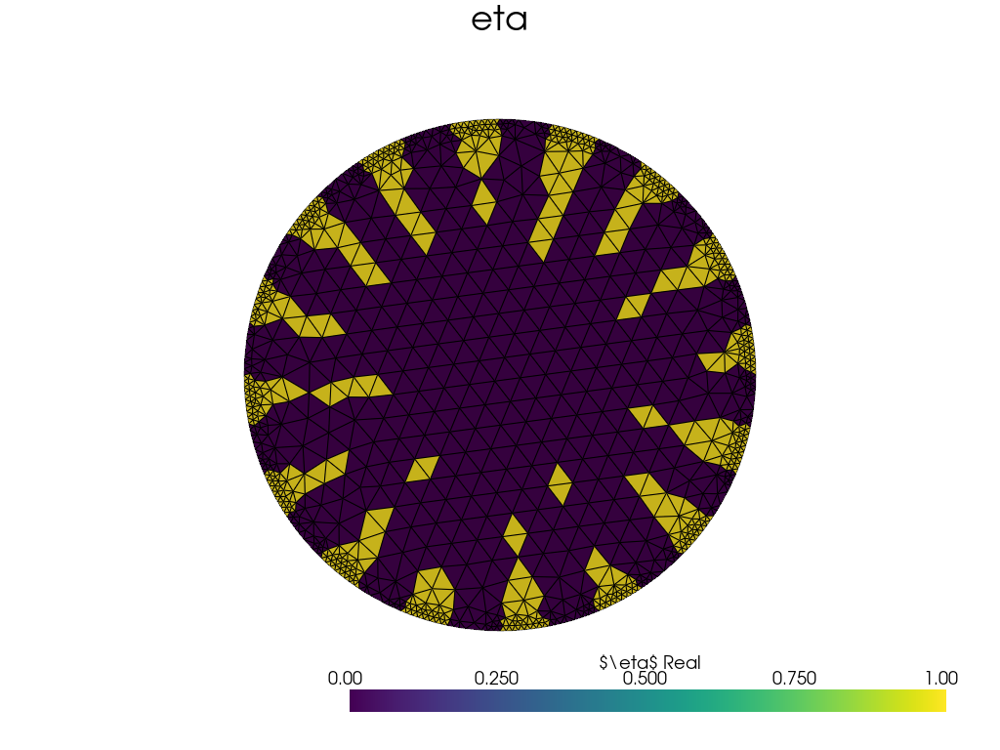

In [ ]:
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG", 0)) #space of piecewise constant functions in omega

eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space

for i in range(L):
  eta_cells = dolfinx.mesh.locate_entities(mesh,2,boundaries[i][1]) #cells that respect the indicator
  eta.x.array[eta_cells] = 1  #define the vertex with set index as 1, rest remain as 0

#Plotting eta
p_mesh = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh,mesh.topology.dim))
pyvista_cells, cell_types, geometry = dolfinx.plot.vtk_mesh(mesh)

grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["$\eta$ Real"] = eta.x.array.real
grid.cell_data["$\eta$ Imaginary"] = eta.x.array.imag

grid.set_active_scalars("$\eta$ Real")
p_real = pyvista.Plotter(notebook=True)
p_real.add_text("eta", position="upper_edge", font_size=14, color="black")
p_real.add_mesh(grid,show_edges=True)
p_real.view_xy()
# p_real.set_background("white")
if not pyvista.OFF_SCREEN:
    p_real.show(jupyter_backend="static")



Testing with functions of different values on $E_i$. I.e., computing
$$
\int_{E_i} i dx
$$

In [ ]:
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG", 0)) #Function space object

integral_list = []
for i in range(L):
  cte = dolfinx.fem.Constant(mesh, PETSc.ScalarType(i+1))
  v = ufl.TrialFunction(V0) #trial object
  s = cte * v * ds(i) # creates object of the form \int_{e_i} 1*ds

  integral_form = dolfinx.fem.form(s)
  integral = dolfinx.fem.assemble_scalar(integral_form)
  integral_list.append(integral.real)
  print("Electrode ", i ,": ", integral)


Electrode  0 :  (0.19170726283534886+0j)
Electrode  1 :  (0.3834145256706977+0j)
Electrode  2 :  (0.5751217885060469+0j)
Electrode  3 :  (0.7668290513413968+0j)
Electrode  4 :  (0.9585363141767436+0j)
Electrode  5 :  (1.1502435770120953+0j)
Electrode  6 :  (1.3419508398474442+0j)
Electrode  7 :  (1.5336581026827933+0j)
Electrode  8 :  (1.7253653655181345+0j)
Electrode  9 :  (1.9170726283534738+0j)
Electrode  10 :  (2.1087798911888362+0j)
Electrode  11 :  (2.3004871540241743+0j)
Electrode  12 :  (2.4921944168595336+0j)
Electrode  13 :  (2.6839016796948565+0j)
Electrode  14 :  (2.875608942530204+0j)
Electrode  15 :  (3.0673162053655663+0j)


In [ ]:
integral_array = np.array(integral_list)
error_array = integral_array - electrode_real_area*np.arange(1,L+1)
print("Electrode length:", electrode_real_area)
electrode_area_df = pd.DataFrame({"Calculated Integral": integral_array,"True Integral":electrode_real_area*np.arange(1,L+1),"Error": error_array})
electrode_area_df.head(n=L)

Electrode length: 0.19634954084936207


,Calculated Integral,True Integral,Error
0,0.191707,0.196350,-0.004642
1,0.383415,0.392699,-0.009285
2,0.575122,0.589049,-0.013927
3,0.766829,0.785398,-0.018569
4,0.958536,0.981748,-0.023211
5,1.150244,1.178097,-0.027854
6,1.341951,1.374447,-0.032496
7,1.533658,1.570796,-0.037138
8,1.725365,1.767146,-0.041781
9,1.917073,1.963495,-0.046423


# Direct Problem

In Hafemann EIT code done in legacy fenics (https://github.com/HafemannE/FEIT_CBM34), he used mixed spaces (analogue for $H^1(\Omega)\oplus \mathbb R^L$) for constructing the problem. Occurs that in dolfinx this still doesn't have support. Some forum questions about mixed spaces in dolfinx:

https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html

https://fenicsproject.discourse.group/t/mixed-function-space-with-dolfinx-how-to-implement-an-integral-constraint/9672

https://fenicsproject.discourse.group/t/singular-poisson-equation-in-dolfinx/12632/7

https://fenicsproject.discourse.group/t/how-can-i-use-block-forms-multiphenicsx-and-lagrange-multipliers-to-solve-poissons-equation-with-pure-neumann-boundary-conditions/12911

https://github.com/FEniCS/dolfinx/issues/1983


Stokes example (more on block matrix solvers): https://docs.fenicsproject.org/dolfinx/main/python/demos/demo_stokes.html


One alternative found is to assemble the matrix by parts, joining in an block vector. Based on following method: https://fenicsproject.discourse.group/t/is-it-possible-to-insert-a-vector-into-an-assembled-matrix/14118/6.

As described in Polydorides and Santana, the CEM discretized matrix is given by:
$$
A = \begin{bmatrix}
A^{(1)} & A^{(2)} \\
(A^{(2)})^T & A^{(4)}
\end{bmatrix}
$$
with
$$
A^{(1)}_{p,n} = \begin{bmatrix}
\left( \sum_{j=1}^{K} \gamma_j \int_{T_j} \nabla \Upsilon_p \cdot \nabla \Upsilon_n dx \right) + \left( \sum_{j=1}^{L} \frac{1}{z_j} \int_{E_j} \Upsilon_p \Upsilon_n dS \right)
\end{bmatrix} \in \mathbb{R}^{N \times N}
$$

$$
A^{(2)}_{p,n} = \begin{bmatrix}
 \left(- \frac{1}{z_n} \int_{E_n} \Upsilon_p dS \right)
\end{bmatrix}\in \mathbb{R}^{N \times L}
$$
$$
A^{(4)}_{p,k} = \begin{bmatrix}
 \left( \frac{1}{z_p} \int_{E_p} dS \right)
\end{bmatrix}\in \mathbb{R}^{L \times L}
$$

Obs:
- Only $A^{(1)}$ depends on $\gamma$. The rest may be precomputed, changing only $A^{(1)}$ in each step of inverse problem solver for different $\gamma$.

## Assembling matrices

In [88]:
Ve = basix.ufl.element('Lagrange', "triangle", degree=1, shape=())
V = dolfinx.fem.functionspace(mesh, Ve) #creates function space in mesh
V0e = basix.ufl.element('Discontinuous Lagrange', "triangle", degree=0, shape=())
V0 = dolfinx.fem.functionspace(mesh, V0e)

N = V.dofmap.index_map.size_global

z_value = 0.025+0.0025j

x = ufl.SpatialCoordinate(mesh)

# gamma = dolfinx.fem.Constant(mesh, PETSc.ScalarType(1+1j))
gamma = dolfinx.fem.Function(V0)
expr = 1+1j+ ufl.exp(-(x[0]**2+x[1]**2)/0.2)
gamma.interpolate(dolfinx.fem.Expression(expr,V0.element.interpolation_points()))

z = dolfinx.fem.Constant(mesh, PETSc.ScalarType(z_value))
I = np.zeros(L)
I[0] = 1; I[1] = -1

In [89]:
u = ufl.TrialFunction(V) #function u_h
v = ufl.TestFunction(V)

gradu = ufl.grad(u)
gradv = ufl.grad(v)

#A1
A1_sum_array = [(1/z)*ufl.inner(u,v)*ds(i) for i in range(L)]
A1_form = (gamma * ufl.inner(gradu, gradv)) * ufl.dx + np.sum(A1_sum_array)
A1_form_obj = dolfinx.fem.form(A1_form)
A1_matrix = dolfinx.fem.petsc.assemble_matrix(A1_form_obj)

# a4 = A4_matrix.getValues(range(L),range(L))


In [90]:
###
#A2
A2_form_array = [-ufl.inner((1/z), v) * ds(i) for i in range(L)]
A2_form_obj = [dolfinx.fem.form(form) for form in A2_form_array]
A2_vector_array= [dolfinx.fem.petsc.assemble_vector(form) for form in A2_form_obj]

A2_matrix = np.zeros((N,L),dtype=complex)
for j in range(L):
    A2_col = A2_vector_array[j].getValues(range(N))
    print(A2_col)
    A2_matrix[:,j] = A2_col

print(A2_matrix)

# A2_matrix.assemble()
# A2T_matrix = A2_matrix.transpose()
# A2T_matrix.assemble()

###


[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[ 0.       +0.j          0.       +0.j          0.       +0.j         ...
 -0.4748482+0.04748482j -0.4748482+0.04748482j -0.4748482+0.04748482j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
[-0.4748482+0.04748482j  0.       +0.j         -0.4748482+0.04748482j ...
  0.       +0.j          0.       +0.j          0.       +0.j        ]
[[ 0.       +0.j          0.       +0.j          0.       +0.j
  ...  0.       +0.j          0.       +0.j
  -0.4748482+0.04748482j]
 [ 0.       +0.j          0.       +0.j          0.       +0.j
  ...  0.       +0.j          0.       +0.j
   0.       +0.j        ]
 [ 0.       +0.j          0.       +0.j          0.       +0.j
  ...  0.       +0.j          0.       +0.j
  -0.4748482+0.04748482j]
 ...
 [ 0.       +0.j  

In [91]:

#A4
cell_area_list = []
for i in range(L):
  v = ufl.TrialFunction(V0) #trial object
  s = v*ds(i) # creates object of the form \int_{e_i} 1*ds
  cell_area_form = dolfinx.fem.form(s)
  cell_area = dolfinx.fem.assemble_scalar(cell_area_form)
  cell_area_list.append(cell_area.real)
cell_area_array = np.array(cell_area_list)
A4_diagonal = np.diag(cell_area_array*(1/z_value))

# A4_matrix = PETSc.Mat().create(comm=MPI.COMM_WORLD)
# A4_matrix.setSizes(L)
# A4_matrix.setValues(range(L),range(L),A4_diagonal.ravel())
# A4_matrix.assemble()


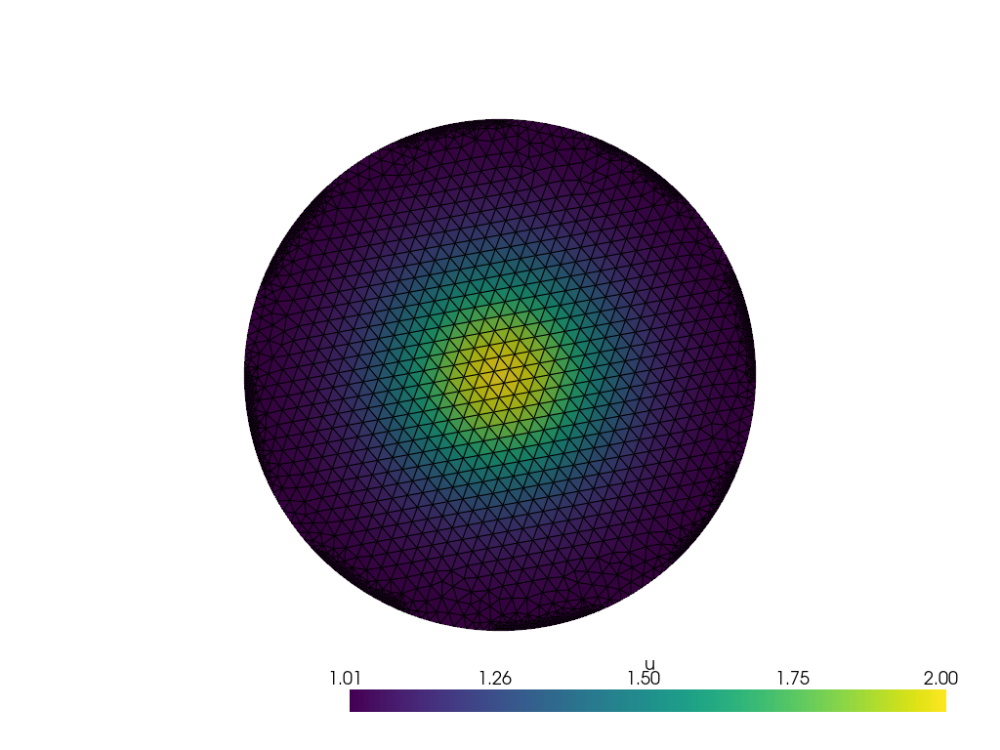

In [92]:
plot_indicator_function(gamma)

## Solving by numpy (single current)

Getting trouble while dealing with PETSc vectors. Little workaround below:
- converting PETSc matrices and vectors generated by fenics to numpy array objects;
- solving by least squares using numpy matrix structure;

This is slow and probably leads to huge error. Using only as alternative while solvig PETSc.

In [93]:
A1_matrix.assemble()
A1_np_matrix = A1_matrix.getValues(range(N),range(N))
# A2_np_matrix = A2_matrix.getValues(range(N),range(L))
A2_np_matrix = A2_matrix

A_np = np.block([[A1_np_matrix, A2_np_matrix],
                [A2_np_matrix.T, A4_diagonal]])

b = np.block([np.zeros(N),I])

In [94]:
u_nest = np.linalg.lstsq(A_np,b)[0] #least square solution of Au=b
u_array, U_array = u_nest[:N], u_nest[N:] #splitting array

# translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
S = U_array.sum()
U_array -= S/L
u_array -= S/L

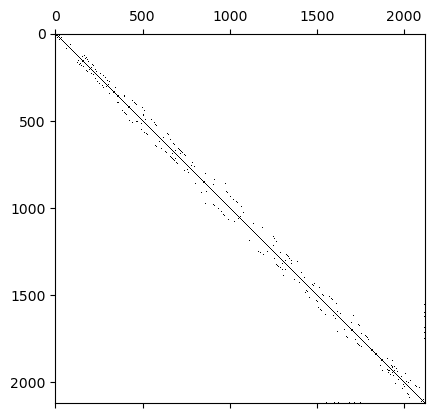

In [95]:
plt.spy(A_np)

U measured array: [ 0.38986076-0.29337948j -0.38974009+0.29322255j -0.09325028+0.07493296j
 -0.0402717 +0.02989621j -0.01176759+0.00838261j  0.01173297-0.00833805j
  0.04023611-0.02985082j  0.09319983-0.07486598j]
U sum:  (-6.938893903907228e-18+2.0816681711721685e-17j)


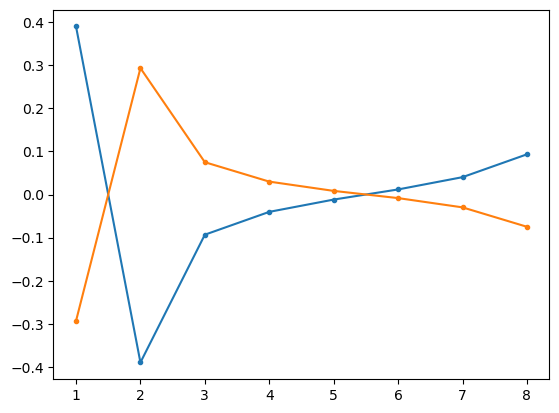

In [96]:
print("U measured array:",U_array)
print("U sum: ", U_array.sum())
plt.plot(np.arange(1,L+1),U_array.real, marker='.')
plt.plot(np.arange(1,L+1),U_array.imag, marker='.')
plt.show()

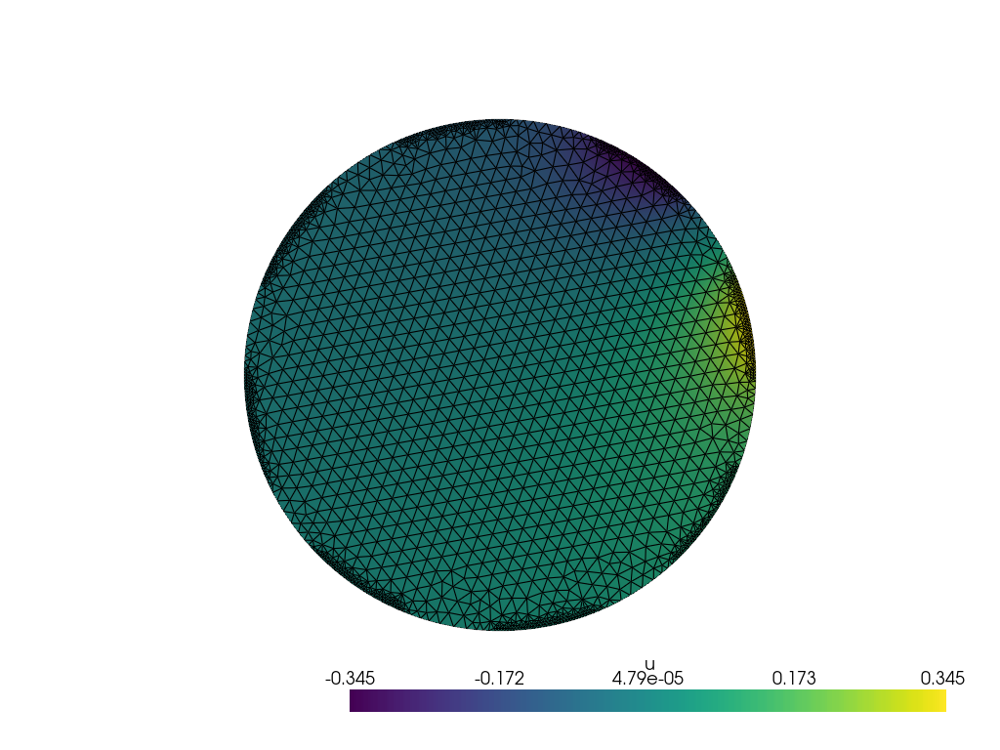

In [97]:
u_func = dolfinx.fem.Function(V)
u_func.x.array[:] = u_array

plot_tent_function(u_func)

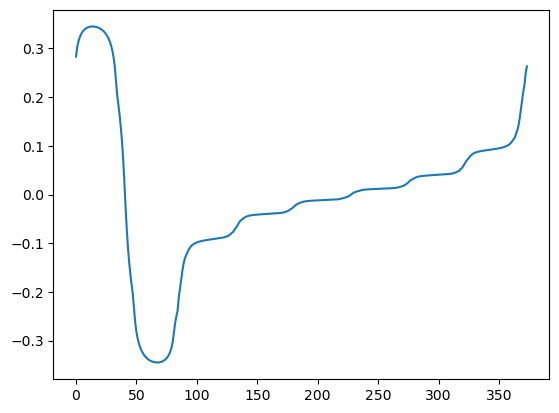

In [98]:
u_bdr_array = get_boundary_data(u_func)
plt.plot(u_bdr_array)

## Consistency tests

### Test 1: integral x current
$$
\int_{e_j} \gamma \frac{\partial u}{\partial \eta} dS = I_j
$$

In [99]:
int_array = []
n = ufl.FacetNormal(mesh)
for j in range(L):
  form = dolfinx.fem.form((gamma * ufl.inner(ufl.grad(u_func),n)) * ds(j))
  value = dolfinx.fem.assemble_scalar(form)
  int_array.append(value)

int_array = np.array(int_array)

int_df = pd.DataFrame({"Currents Array (I)":I, "Integral Array": int_array, "Error":I-int_array,"Norm":np.linalg.norm(I-int_array)})
# int_df['norm_error'] = np.linalg.norm(int_df["Error"])
int_df.head(n=L)
# print("Currents array: ",I)
# print("Integral array:", int_array)
# print("Error:", I-int_array)

,Currents Array (I),Integral Array,Error,Norm
0,1.0,0.923973+0.012565j,0.076027-0.012565j,0.106673
1,-1.0,-0.927358-0.012430j,-0.072642+0.012430j,0.106673
2,0.0,-0.002149+0.000358j,0.002149-0.000358j,0.106673
3,0.0,-0.000419+0.000122j,0.000419-0.000122j,0.106673
4,0.0,0.000070+0.000006j,-0.000070-0.000006j,0.106673
5,0.0,0.000018-0.000019j,-0.000018+0.000019j,0.106673
6,0.0,0.000478-0.000200j,-0.000478+0.000200j,0.106673
7,0.0,0.002077-0.000416j,-0.002077+0.000416j,0.106673


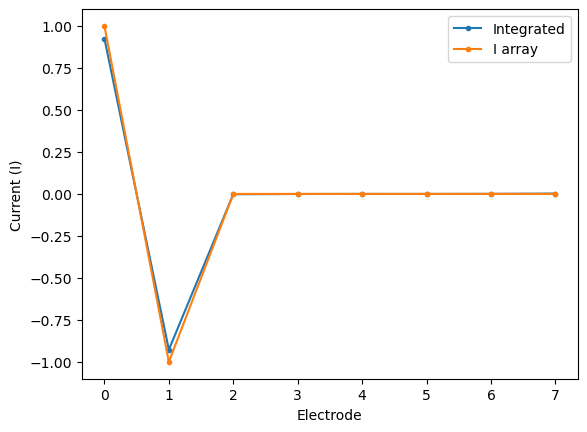

In [101]:

plt.plot(int_array.real, label="Integrated",marker='.')
plt.plot(I, label="I array",marker='.')
plt.legend()
plt.ylabel("Current (I)")
plt.xlabel("Electrode")
plt.show()

### Test 2: flux in gaps

Verifying plot of $\gamma \nabla u \cdot \eta$ on boundary

Couldn't use the fenics projections, computing it using analytic geometry stuff.

Getting index of triangles with facet on boundary

Idea from https://fenicsproject.discourse.group/t/define-a-boundary-from-dg-elements/5723/2

In [102]:
# The code below gets all triangles with a facet (edge) contained in boundary.
mesh.topology.create_connectivity(1, mesh.topology.dim)
facet_to_cell = mesh.topology.connectivity(1, mesh.topology.dim)
def boundary_locator(x):
    return np.isclose(x[0]**2+x[1]**2, 1)

boundary_facets = dolfinx.mesh.locate_entities(mesh, 1, boundary_locator)
boundary_cells = []
for facet in boundary_facets:
    boundary_cells.append(facet_to_cell.links(facet))
boundary_cells = np.hstack(boundary_cells)

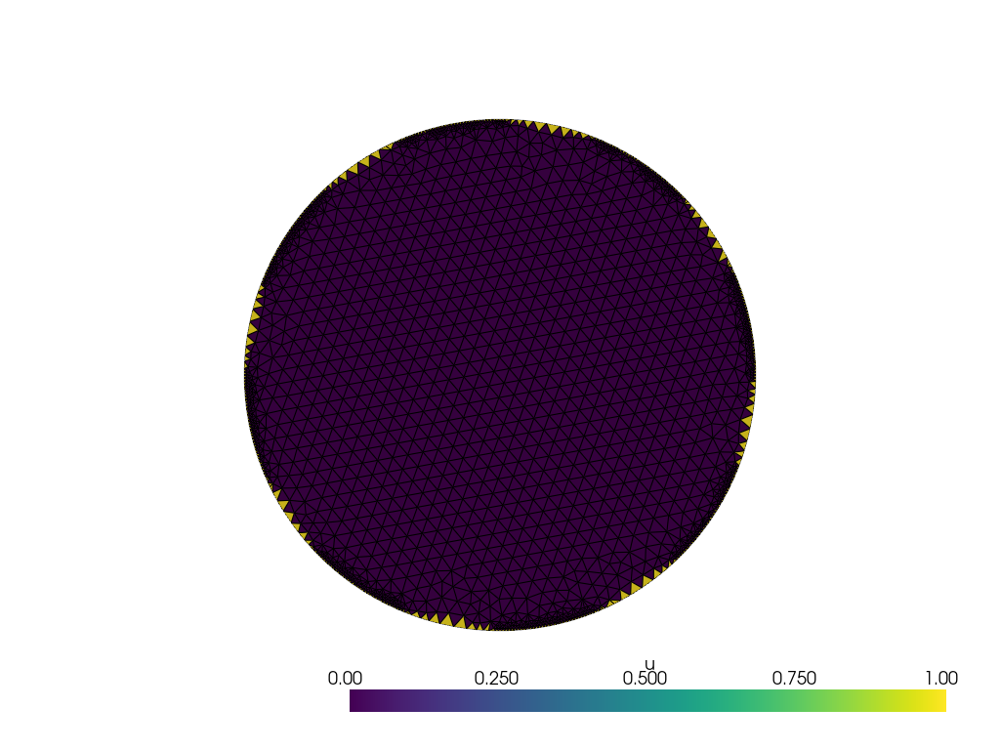

In [103]:
# indicator function on the selected cells
test_func = dolfinx.fem.Function(V0)
test_func.x.array[boundary_cells] = 1
plot_indicator_function(test_func)

In [104]:
adjacency_list = mesh.topology.connectivity(2,0)
mesh_vertex_index_list = []
for i in range(len(adjacency_list)):
  mesh_vertex_index_list.append(adjacency_list.links(i))

cells_coordinates_list = []
for cell_vertex_index in mesh_vertex_index_list:
  cells_coordinates_list.append(mesh.geometry.x[cell_vertex_index][:,:2])

#Compute grad(u_func)
# gradu_list = []
flux_list = []
j=0
for idx in mesh_vertex_index_list:
  cell_coord = mesh.geometry.x[idx][:,:2]
  system_array = np.concatenate((cell_coord,np.ones(3).reshape(3,1)),axis=1)
  u_t = u_func.x.array[idx]
  plane_coef = np.linalg.solve(system_array, u_t)
  gradu = plane_coef[:2]
  # gradu_x, gradu_y = plane_coef[0],plane_coef[1]

  #checks outer segment, compute normal vector pointing outward the domain
  idx_interior_point = np.argmin(np.linalg.norm(cell_coord,axis=1)) #idx of vertex on interior (closer to 0)
  interior_point = cell_coord[idx_interior_point]
  bdr_point_A, bdr_point_B = np.delete(cell_coord,[idx_interior_point],axis=0)
  AB = bdr_point_B - bdr_point_A
  AI = interior_point - bdr_point_A
  t = np.vdot(AB,AI)/np.vdot(AB,AB)
  projAB = bdr_point_A + t*AB
  Normal = projAB - interior_point
  normal = Normal/np.linalg.norm(Normal)

  gamma_x = gamma.x.array[j]
  # gamma_x = 1+1j

  flux_list.append(gamma_x * (np.vdot(normal,gradu)))
  j+=1

flux_array = np.array(flux_list)

In [105]:
len(mesh_vertex_index_list)

3846

In [106]:
idx

array([2108, 2098, 2110], dtype=int32)

In [107]:
#get angle of cell in each
dofs_coordinates = V0.tabulate_dof_coordinates()
x_bdr = dofs_coordinates[boundary_cells][:,0]
y_bdr = dofs_coordinates[boundary_cells][:,1]
theta = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))

In [108]:
#checks if angle in some electrode
electrode_marker = []
for angle in theta:
  inElectrode = False
  for (theta_i,theta_f) in electrodes.position:
    if theta_i<=angle and angle<=theta_f:
      inElectrode = True
      break
  electrode_marker.append(inElectrode)

electrode_marker = np.array(electrode_marker)

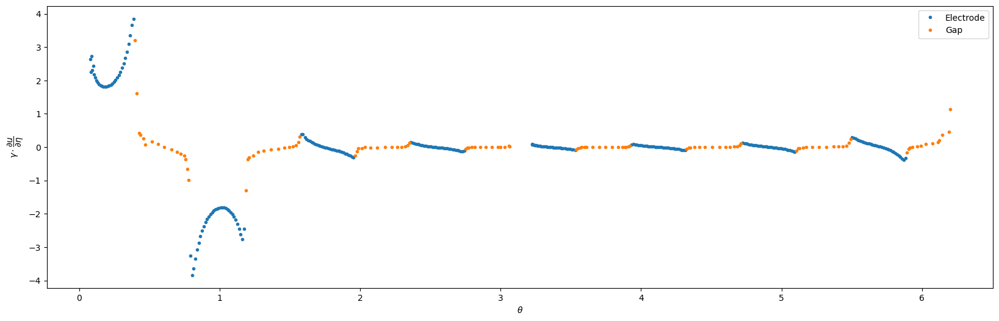

In [109]:
theta_cells_in_electrode = theta[electrode_marker]
theta_cells_out_electrode = theta[~electrode_marker]
flux_in_electrode = flux_array[boundary_cells][electrode_marker]
flux_out_electrode = flux_array[boundary_cells][~electrode_marker]


plt.figure(figsize=(20,6))
plt.plot(theta_cells_in_electrode,flux_in_electrode.real,marker='.',linestyle='',label="Electrode")
plt.plot(theta_cells_out_electrode,flux_out_electrode.real,marker='.',linestyle='',label='Gap')
plt.xlabel("$\\theta$")
plt.ylabel("$\gamma \cdot \dfrac{\partial u}{\partial \eta}$")
plt.legend()
plt.show()

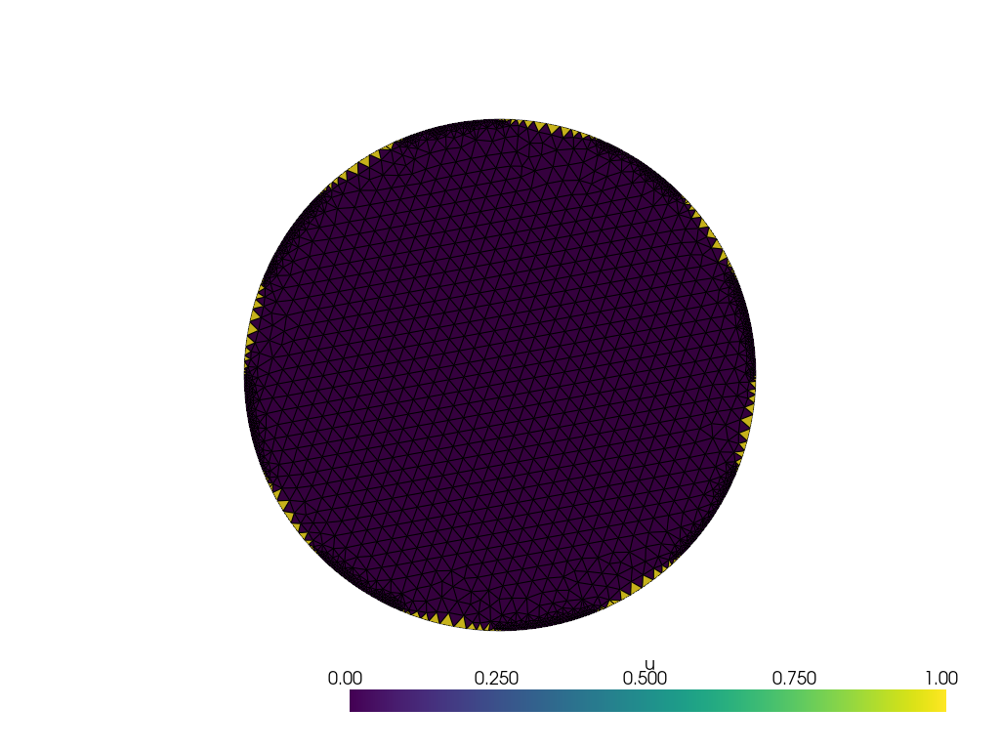

In [ ]:
# indicator function on the selected cells
test_func = dolfinx.fem.Function(V0)
test_func.x.array[boundary_cells] = ~electrode_marker
plot_indicator_function(test_func)


### Test 3: potential in electrodes

Testing if
$$
U_j = u|_{e_j} + z_j \gamma \frac{\partial u}{\partial \eta}
$$


As $u$ is defined on the vertices and $\gamma \frac{\partial u}{\partial \eta}$ is constant in each edge, needs to chose which vertex and adjacent facet to evaluate.

Getting the following:
- order vertices and facets by angle;
- chose $u_j$ and $\gamma_j$ in the order set above.



In [110]:
#create connection
mesh.topology.create_connectivity(mesh.topology.dim-1, mesh.topology.dim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)
boundary_dofs_index_array = dolfinx.fem.locate_dofs_topological(V, mesh.topology.dim-1, boundary_facets) #array with the vertices index

#gets x and y coordinates for the boundary
V_dofs_coordinates = V.tabulate_dof_coordinates()
x_bdr = V_dofs_coordinates[boundary_dofs_index_array][:,0]
y_bdr = V_dofs_coordinates[boundary_dofs_index_array][:,1]
theta = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))
sorted_theta_vtx_index = np.argsort(theta)

#get angle of cell in each
V0_dofs_coordinates = V0.tabulate_dof_coordinates()
x_bdr = V0_dofs_coordinates[boundary_cells][:,0]
y_bdr = V0_dofs_coordinates[boundary_cells][:,1]
theta_cells = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))
sorted_theta_cll_index = np.argsort(theta_cells)


In [113]:
sorted_bdr_vtx_idx = boundary_dofs_index_array[sorted_theta_vtx_index]
sorted_bdr_cll_idx = boundary_cells[sorted_theta_cll_index]
U_star = u_func.x.array[sorted_bdr_vtx_idx] + z_value*flux_array[sorted_bdr_cll_idx]

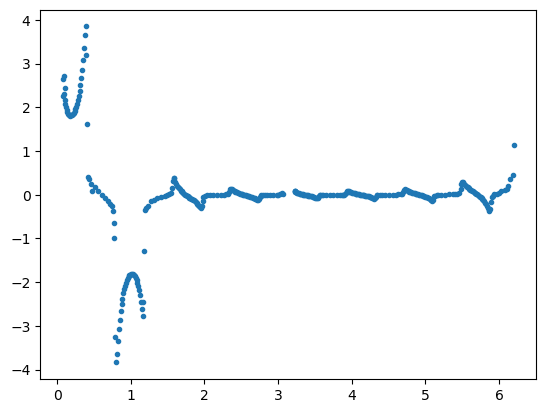

In [114]:
plt.plot(theta_cells[sorted_theta_cll_index],flux_array[sorted_bdr_cll_idx],linestyle='',marker='.')
plt.show()

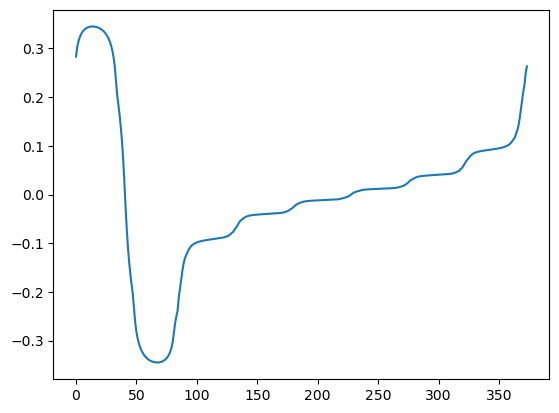

In [115]:
plt.plot(u_func.x.array[sorted_bdr_vtx_idx])
plt.show()

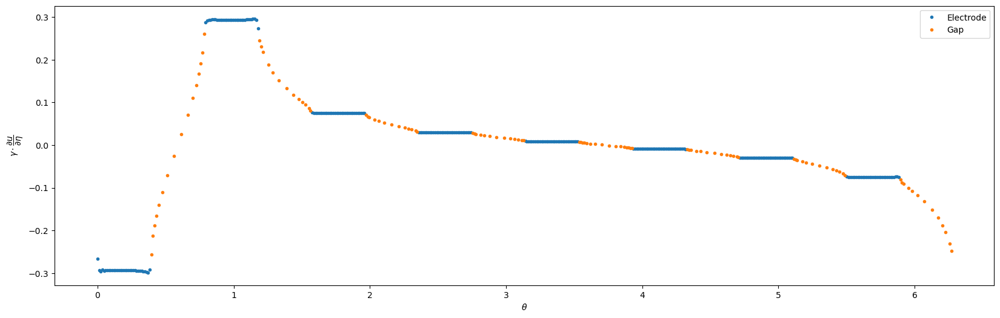

In [116]:
theta=np.sort(theta)

electrode_marker = []
for angle in theta:
  inElectrode = False
  for (theta_i,theta_f) in electrodes.position:
    if theta_i<=angle and angle<=theta_f:
      inElectrode = True
      break
  electrode_marker.append(inElectrode)
electrode_marker = np.array(electrode_marker)

theta_in_electrode = theta[electrode_marker]
theta_out_electrode = theta[~electrode_marker]
Ustar_in_electrode = U_star[electrode_marker]
Ustar_out_electrode = U_star[~electrode_marker]


plt.figure(figsize=(20,6))
plt.plot(theta_in_electrode,Ustar_in_electrode.imag,marker='.',linestyle='',label="Electrode")
plt.plot(theta_out_electrode,Ustar_out_electrode.imag,marker='.',linestyle='',label='Gap')
plt.xlabel("$\\theta$")
plt.ylabel("$\gamma \cdot \dfrac{\partial u}{\partial \eta}$")
plt.legend()
plt.show()

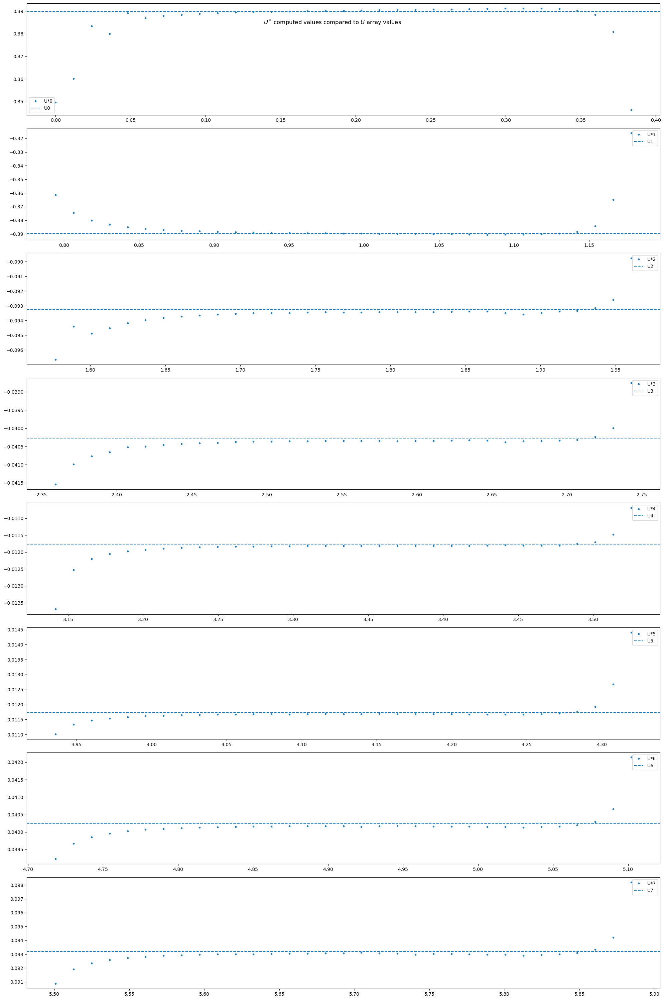

In [117]:
t = theta
fig,axs = plt.subplots(L,1,figsize=(20,30))

for j in range(L):
  theta_i,theta_f = electrodes.position[j]
  theta_j_idx = np.logical_and(t>=theta_i,t<=theta_f)#index of theta in electrode j
  axs[j].plot(t[theta_j_idx],U_star.real[theta_j_idx],label=f"U*{j}",linestyle='',marker='.')
  axs[j].axhline(U_array[j].real,label=f'U{j}',linestyle='--')
  axs[j].legend()
  # axs[j].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])

  # axs[1].plot(t,f(t),label="exact")
  # axs[1].plot(t,u_bdr_real_array,label="calculated")
  # axs[1].set_title("realinary part")
  # axs[1].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])
fig.tight_layout()
fig.suptitle("$U^*$ computed values compared to $U$ array values")
plt.show()

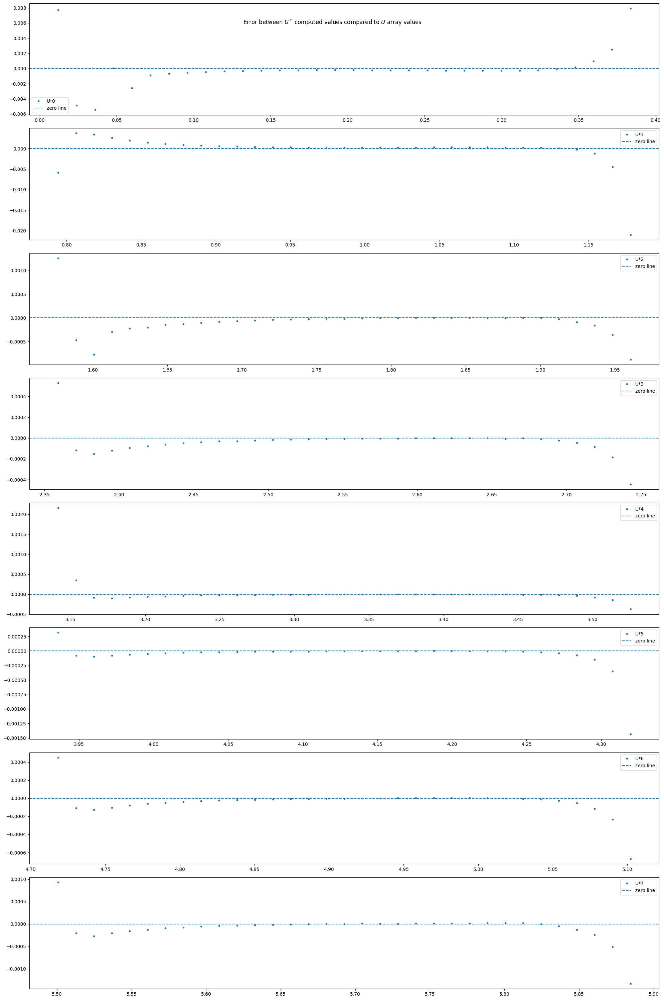

In [ ]:
#eror
t = theta
fig,axs = plt.subplots(L,1,figsize=(20,30))

for j in range(L):
  theta_i,theta_f = electrodes.position[j]
  theta_j_idx = np.logical_and(t>=theta_i,t<=theta_f)#index of theta in electrode j
  axs[j].plot(t[theta_j_idx],U_star.imag[theta_j_idx]-U_array[j].imag,label=f"U*{j}",linestyle='',marker='.')
  axs[j].axhline(0,label=f'zero line',linestyle='--')
  axs[j].legend()
  # axs[j].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])

  # axs[1].plot(t,f(t),label="exact")
  # axs[1].plot(t,u_bdr_imag_array,label="calculated")
  # axs[1].set_title("imaginary part")
  # axs[1].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])
fig.tight_layout()
fig.suptitle("Error between $U^*$ computed values compared to $U$ array values")
plt.show()

## Solving by numpy (multiple currents)

In [ ]:
A1_matrix.assemble()
A1_np_matrix = A1_matrix.getValues(range(N),range(N))
A2_np_matrix = A2_matrix.getValues(range(N),range(L))

A_np = np.block([[A1_np_matrix, A2_np_matrix],
                [A2_np_matrix.T, A4_diagonal]])


### Performance Comparison

Solving for multiple currents $I$:
- by getting $A^\dagger$ pseudoinverse through `np.linalg.pinv` method;
- by solving by least squares with `np.linalg.lstsq` for each vector;
- by solving the normal equation $A^*A\hat u = A^*\hat b$ each time

In [ ]:
I_all = []
l=4
value = 1

for i in range(l):
  if i!=L-1:
    I=np.zeros(L)
    I[i], I[i+1]=value, -value
    I_all.append(I)
  else:
    I=np.zeros(L)
    I[0], I[i]=-value, value
    I_all.append(I)

Computing pseudoinverse, apllying to each b vector

In [ ]:
%%time
pinv_u_list = []
pinv_U_list = []

A_pinv = np.linalg.pinv(A_np)

for k in range(l):
  b = np.block([np.zeros(N),I_all[k]])
  u_nest = A_pinv@b #least square solution of Au=b
  u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
  # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
  S = U_array.sum()
  U_array -= S/L
  u_array -= S/L
  pinv_u_list.append(u_array)
  pinv_U_list.append(U_array)

CPU times: user 42.4 s, sys: 4.35 s, total: 46.7 s
Wall time: 27.6 s


Solving each time using `np.linalg.lstsq` method

In [ ]:
%%time
lstsq_u_list = []
lstsq_U_list = []

for k in range(l):
  b = np.block([np.zeros(N),I_all[k]])
  u_nest = np.linalg.lstsq(A_np,b)[0] #least square solution of Au=b
  u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
  # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
  S = U_array.sum()
  U_array -= S/L
  u_array -= S/L

  lstsq_u_list.append(u_array)
  lstsq_U_list.append(U_array)

CPU times: user 1min 31s, sys: 7.51 s, total: 1min 38s
Wall time: 1min 3s


Solving each time the normal equation by `np.linalg.solve`

In [ ]:
%%time
normaleq_u_list = []
normaleq_U_list = []

for k in range(l):
  b = np.block([np.zeros(N),I_all[k]])
  u_nest = np.linalg.solve(A_np.T.conj()@A_np,A_np.T.conj()@b) #least square solution of Au=b
  u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
  # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
  S = U_array.sum()
  U_array -= S/L
  u_array -= S/L

  normaleq_u_list.append(u_array)
  normaleq_U_list.append(U_array)

CPU times: user 20.8 s, sys: 2.01 s, total: 22.9 s
Wall time: 13.4 s


In [ ]:
pinv_lstsq_err = []
pinv_neq_err = []
lstsq_neq_err = []

for k in range(l):
  pinv_lstsq_err.append(np.linalg.norm(pinv_u_list[k] - lstsq_u_list[k]))
  pinv_neq_err.append(np.linalg.norm(pinv_u_list[k] - normaleq_u_list[k]))
  lstsq_neq_err.append(np.linalg.norm(normaleq_u_list[k] - lstsq_u_list[k]))

print("Error comparison of u solution arrays (2-norm error)")
err_df = pd.DataFrame({"Pseudoinverse x lstsq":pinv_lstsq_err, "Pseudoinverse x normal eq.":pinv_neq_err, "Normal eq x lstsq":lstsq_neq_err})
err_df.head(n=l)

Error comparison of u solution arrays (2-norm error)


,Pseudoinverse x lstsq,Pseudoinverse x normal eq.,Normal eq x lstsq
0,2.591606e-13,1.279759e-10,1.279824e-10
1,3.648653e-13,6.167788e-10,6.168336e-10
2,5.581480e-13,2.654259e-10,2.655685e-10
3,4.990623e-13,2.130654e-10,2.126883e-10


In [ ]:
pinv_lstsq_err = []
pinv_neq_err = []
lstsq_neq_err = []

for k in range(l):
  pinv_lstsq_err.append(np.linalg.norm(pinv_U_list[k] - lstsq_U_list[k]))
  pinv_neq_err.append(np.linalg.norm(pinv_U_list[k] - normaleq_U_list[k]))
  lstsq_neq_err.append(np.linalg.norm(normaleq_U_list[k] - lstsq_U_list[k]))

print("Error comparison of U solution arrays (2-norm error)")
err_df = pd.DataFrame({"Pseudoinverse x lstsq":pinv_lstsq_err, "Pseudoinverse x normal eq.":pinv_neq_err, "Normal eq x lstsq":lstsq_neq_err})
err_df.head(n=l)

Error comparison of U solution arrays (2-norm error)


,Pseudoinverse x lstsq,Pseudoinverse x normal eq.,Normal eq x lstsq
0,1.867646e-14,9.289052e-12,9.289181e-12
1,2.545600e-14,4.388391e-11,4.388749e-11
2,3.763440e-14,1.894486e-11,1.895423e-11
3,3.387494e-14,1.539792e-11,1.537373e-11


#### Testing sparse

In [ ]:
import scipy as sp
A_sp = sp.sparse.csr_matrix(A_np)

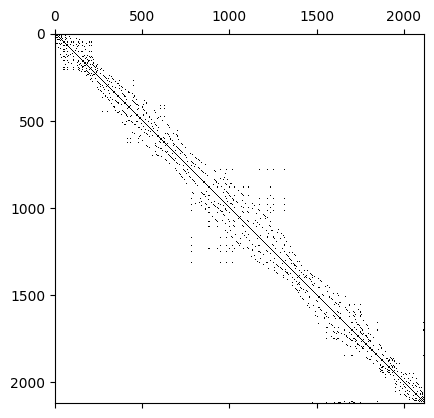

In [ ]:
plt.spy(A_np.T.conj()@A_np,A_np.T.conj())

In [ ]:
# A_sp = A^* A
A_sp = sp.sparse.csr_matrix(A_np.T.conj()@A_np)

In [ ]:
%%time
sparse_normaleq_u_list = []
sparse_normaleq_U_list = []

for k in range(l):
  b = np.block([np.zeros(N),I_all[k]])
  u_nest = sp.sparse.linalg.spsolve(A_sp,A_np.T.conj()@b) #Solve A^*Au = b
  u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
  # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
  S = U_array.sum()
  U_array -= S/L
  u_array -= S/L

  sparse_normaleq_u_list.append(u_array)
  sparse_normaleq_U_list.append(U_array)

CPU times: user 500 ms, sys: 643 ms, total: 1.14 s
Wall time: 917 ms


  return np.asarray(x, float)



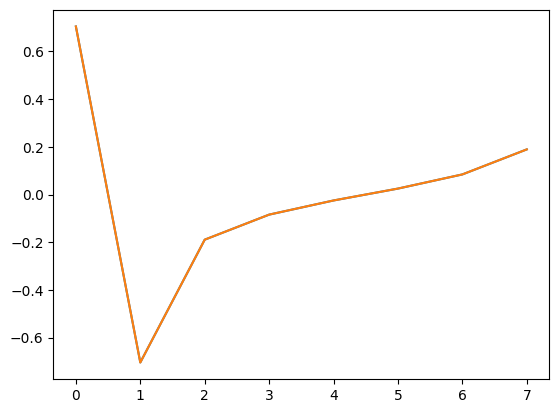

In [ ]:
plt.plot(sparse_normaleq_U_list[0])
plt.plot(normaleq_U_list[0])
plt.show()

In [ ]:
sparse_neq_err = []

for k in range(l):
  sparse_neq_err.append(np.linalg.norm(normaleq_u_list[k] - sparse_normaleq_u_list[k]))

print("Error comparison of u solution arrays (2-norm error)")
err_df = pd.DataFrame(sparse_neq_err)
err_df.head(n=l)

Error comparison of u solution arrays (2-norm error)


,0
0,1.315172e-10
1,6.936311e-10
2,1.883463e-10
3,2.912161e-10


In [ ]:
sparse_neq_err = []

for k in range(l):
  sparse_neq_err.append(np.linalg.norm(normaleq_U_list[k] - sparse_normaleq_U_list[k]))

print("Error comparison of U solution arrays (2-norm error)")
err_df = pd.DataFrame(sparse_neq_err)
err_df.head(n=l)

Error comparison of U solution arrays (2-norm error)


,0
0,9.519947e-12
1,4.926502e-11
2,1.345687e-11
3,2.107591e-11


### Consistency tests

#### Solving direct problem

Currents:
$$
I_1 = [1 , -1 ,0\; \dots 0] \\
I_2 = [0,1,-1, \dots, 0]\\
\vdots
$$

In [ ]:
A1_matrix.assemble()
A1_np_matrix = A1_matrix.getValues(range(N),range(N))
A2_np_matrix = A2_matrix.getValues(range(N),range(L))
A_np = np.block([[A1_np_matrix, A2_np_matrix],
                [A2_np_matrix.T, A4_diagonal]])

I_all = []
l=4
value = 1

for i in range(l):
  if i!=L-1:
    I=np.zeros(L)
    I[i], I[i+1]=value, -value
    I_all.append(I)
  else:
    I=np.zeros(L)
    I[0], I[i]=-value, value
    I_all.append(I)

u_array_list = []
u_func_list = []
U_array_list = []

# for k in range(l):

#   b = np.block([np.zeros(N),I_all[k]])
#   u_nest = np.linalg.solve(A_np.T.conj()@A_np,A_np.T.conj()@b) #least square solution of Au=b
#   u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
#   # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
#   S = U_array.sum()
#   U_array -= S/L
#   u_array -= S/L

for k in range(l):
  b = np.block([np.zeros(N),I_all[k]])
  u_nest = sp.sparse.linalg.spsolve(A_sp,A_np.T.conj()@b) #Solve A^*Au = b
  u_array, U_array = u_nest[:N], u_nest[N:] #splitting array
  # translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
  S = U_array.sum()
  U_array -= S/L
  u_array -= S/L

  u_func = dolfinx.fem.Function(V)
  u_func.x.array[:] = u_array

  u_array_list.append(u_array)
  u_func_list.append(u_func)
  U_array_list.append(U_array)



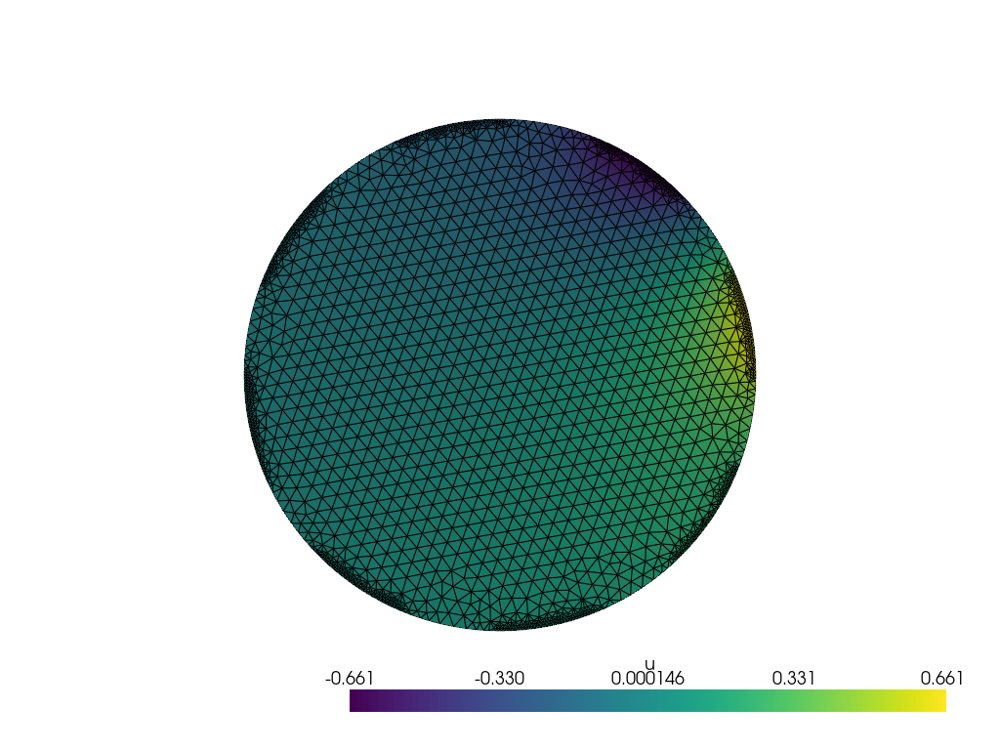

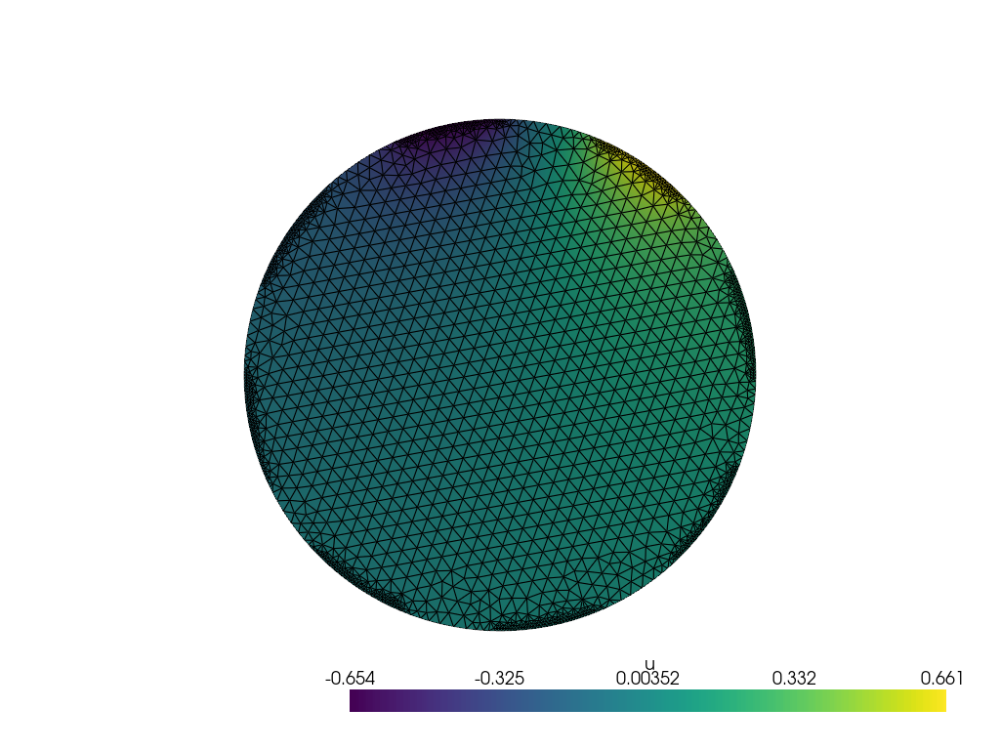

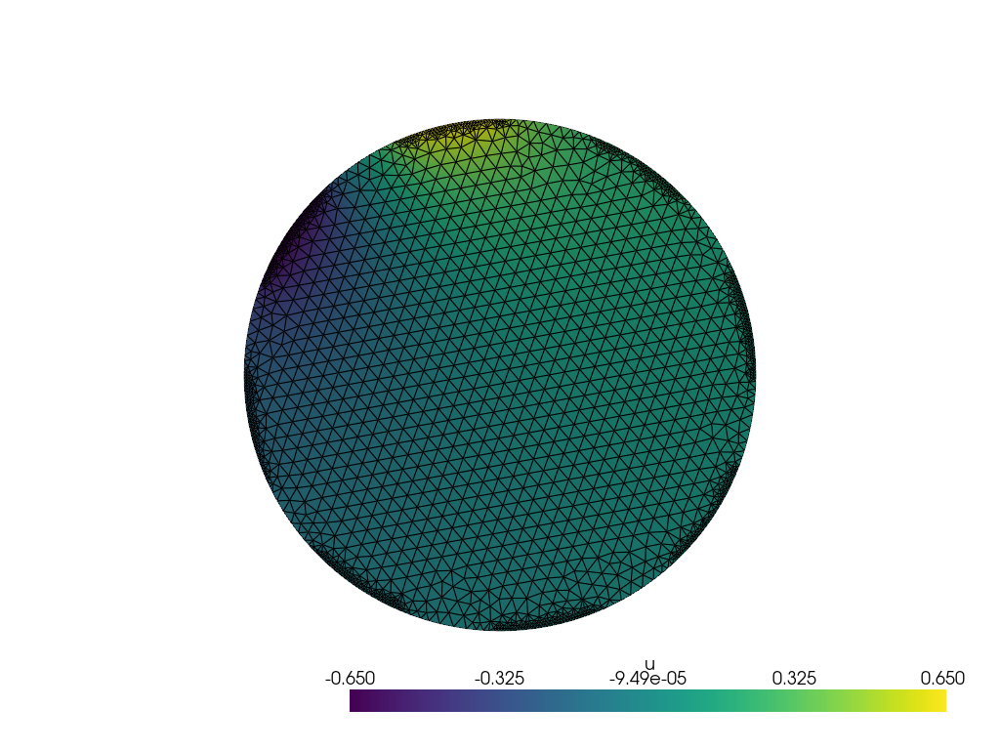

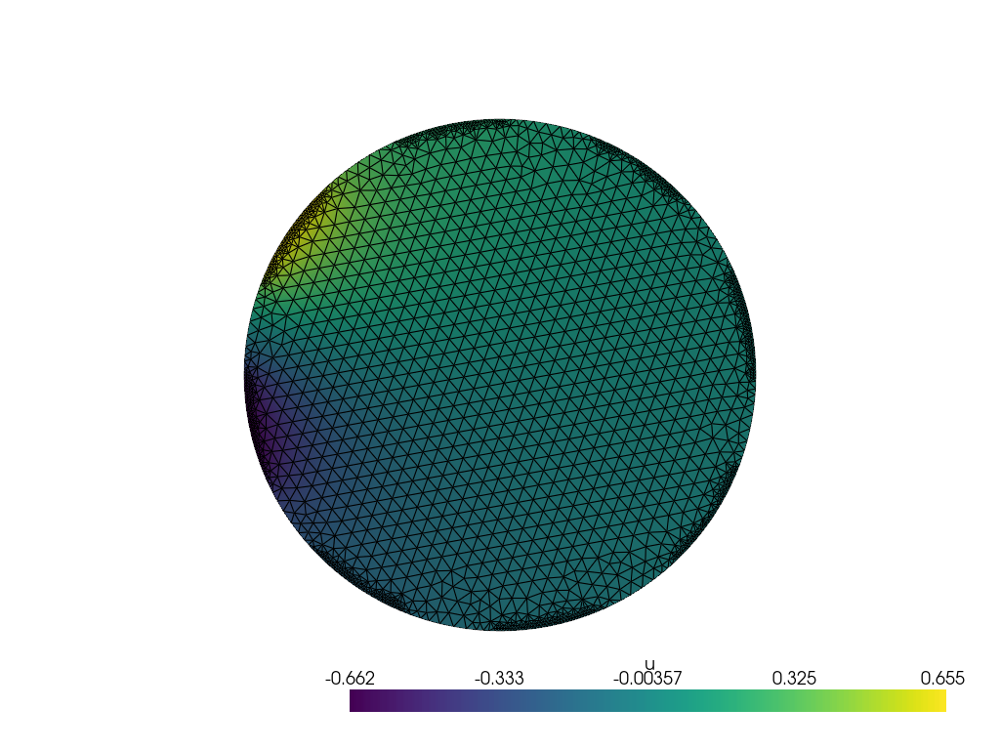

In [ ]:
for k in range(l):
  plot_tent_function(u_func_list[k])

  return np.asarray(x, float)



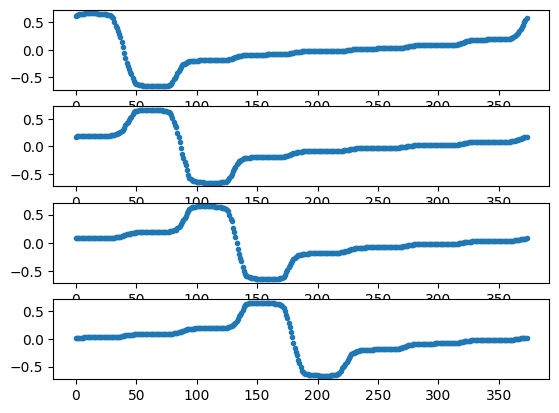

In [ ]:
fig,ax = plt.subplots(l,1)

for k in range(l):
  uk_array = get_boundary_data(u_func_list[k])
  ax[k].plot(uk_array,linestyle='',marker='.')

plt.show()

#### Test 1: integral x current
$$
\int_{e_j} \gamma \frac{\partial u}{\partial \eta} dS = I_j
$$

In [ ]:
int_array = []
I_all_array = np.array(I_all)

n = ufl.FacetNormal(mesh)
for k in range(l):
  int_k_list = [ ]
  for j in range(L):
    form = dolfinx.fem.form(ufl.inner(gamma, ufl.inner(ufl.grad(u_func_list[k]),n)) *ds(j))
    value = dolfinx.fem.assemble_scalar(form)
    int_k_list.append(value)

  int_array.append(int_k_list)

int_array = np.array(int_array)

for k in range(l):
  print("Current",k)
  int_df = pd.DataFrame({"Currents Array (I)":I_all_array[k], "Integral Array": int_array[k], "Error":I_all_array[k]-int_array[k]})
  print(int_df.head(n=L))
  # print("Currents array: ",I)
  # print("Integral array:", int_array)
  # print("Error:", I-int_array)

Current 0
   Currents Array (I)      Integral Array               Error
0                 1.0  0.916505+0.000000j  0.083495+0.000000j
1                -1.0 -0.919467+0.000000j -0.080533+0.000000j
2                 0.0 -0.002191+0.000000j  0.002191+0.000000j
3                 0.0 -0.000471+0.000000j  0.000471+0.000000j
4                 0.0  0.000088+0.000000j -0.000088+0.000000j
5                 0.0  0.000024+0.000000j -0.000024+0.000000j
6                 0.0  0.000607+0.000000j -0.000607+0.000000j
7                 0.0  0.002193+0.000000j -0.002193+0.000000j
Current 1
   Currents Array (I)      Integral Array               Error
0                 0.0  0.002014+0.000000j -0.002014+0.000000j
1                 1.0  0.920918+0.000000j  0.079082+0.000000j
2                -1.0 -0.920685+0.000000j -0.079315+0.000000j
3                 0.0 -0.002450+0.000000j  0.002450+0.000000j
4                 0.0 -0.000168+0.000000j  0.000168+0.000000j
5                 0.0 -0.000138+0.000000j  0.00013

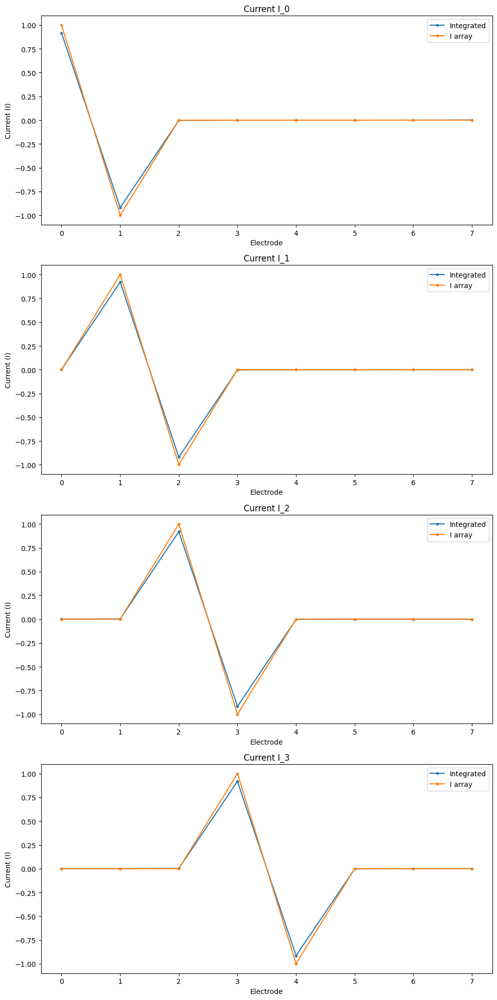

In [ ]:
fig,ax = plt.subplots(l,1,figsize=(10,20))

for k in range(l):
  ax[k].plot(int_array[k].real, label="Integrated",marker='.')
  ax[k].plot(I_all[k], label="I array",marker='.')
  ax[k].legend()
  ax[k].set_ylabel("Current (I)")
  ax[k].set_xlabel("Electrode")
  ax[k].set_title(f"Current I_{k}")

fig.tight_layout()
plt.show()

#### Test 2: flux in gaps

Verifying plot of $\gamma \nabla u \cdot \eta$ on boundary

Couldn't use the fenics projections, computing it using analytic geometry stuff.

Getting index of triangles with facet on boundary

Idea from https://fenicsproject.discourse.group/t/define-a-boundary-from-dg-elements/5723/2

In [ ]:
# The code below gets all triangles with a facet (edge) contained in boundary.
mesh.topology.create_connectivity(1, mesh.topology.dim)
facet_to_cell = mesh.topology.connectivity(1, mesh.topology.dim)
def boundary_locator(x):
    return np.isclose(x[0]**2+x[1]**2, 1)

boundary_facets = dolfinx.mesh.locate_entities(mesh, 1, boundary_locator)
boundary_cells = []
for facet in boundary_facets:
    boundary_cells.append(facet_to_cell.links(facet))
boundary_cells = np.hstack(boundary_cells)

In [ ]:
adjacency_list = mesh.topology.connectivity(2,0)
mesh_vertex_index_list = []
for i in range(len(adjacency_list)):
  mesh_vertex_index_list.append(adjacency_list.links(i))

cells_coordinates_list = []
for cell_vertex_index in mesh_vertex_index_list:
  cells_coordinates_list.append(mesh.geometry.x[cell_vertex_index][:,:2])

#Compute grad(u_func)
# gradu_list = []

flux_list = []
for k in range(l):
  flux_k_list = []

  for idx in mesh_vertex_index_list:
    cell_coord = mesh.geometry.x[idx][:,:2]
    system_array = np.concatenate((cell_coord,np.ones(3).reshape(3,1)),axis=1)
    u_t = u_func_list[k].x.array[idx]
    plane_coef = np.linalg.solve(system_array, u_t)
    gradu = plane_coef[:2]
    # gradu_x, gradu_y = plane_coef[0],plane_coef[1]

    #checks outer segment, compute normal vector pointing outward the domain
    idx_interior_point = np.argmin(np.linalg.norm(cell_coord,axis=1)) #idx of vertex on interior (closer to 0)
    interior_point = cell_coord[idx_interior_point]
    bdr_point_A, bdr_point_B = np.delete(cell_coord,[idx_interior_point],axis=0)
    AB = bdr_point_B - bdr_point_A
    AI = interior_point - bdr_point_A
    t = np.vdot(AB,AI)/np.vdot(AB,AB)
    projAB = bdr_point_A + t*AB
    N = projAB - interior_point
    normal = N/np.linalg.norm(N)

    # gamma_x = gamma.x.array[idx]
    gamma_x = 1

    flux_k_list.append(gamma_x * (np.vdot(normal,gradu)))

  flux_k_array = np.array(flux_k_list)
  flux_list.append(flux_k_array)

In [ ]:
#get angle of cell in each
dofs_coordinates = V0.tabulate_dof_coordinates()
x_bdr = dofs_coordinates[boundary_cells][:,0]
y_bdr = dofs_coordinates[boundary_cells][:,1]
theta = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))

In [ ]:
#checks if angle is in some electrode
electrode_marker = []
for angle in theta:
  inElectrode = False
  for (theta_i,theta_f) in electrodes.position:
    if theta_i<=angle and angle<=theta_f:
      inElectrode = True
      break
  electrode_marker.append(inElectrode)

electrode_marker = np.array(electrode_marker)

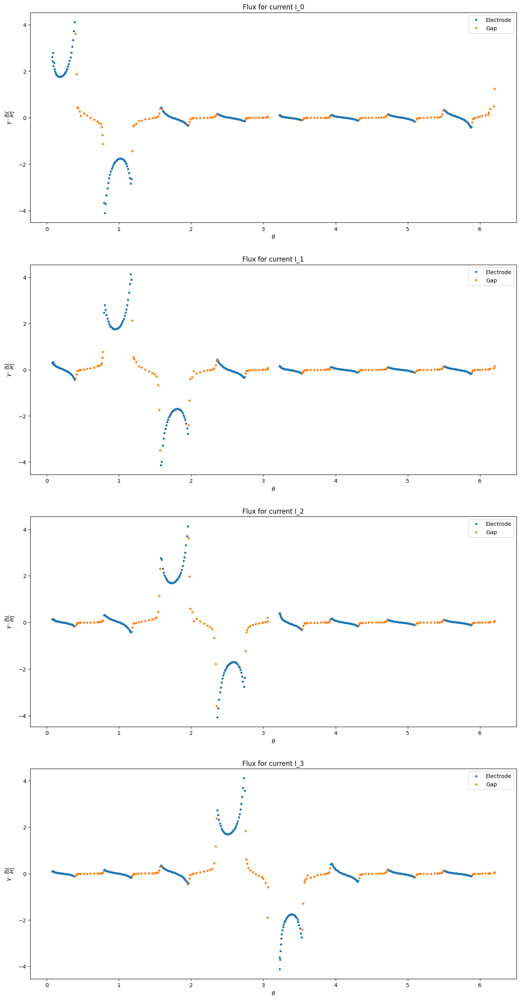

In [ ]:
fig,ax = plt.subplots(l,1,figsize=(16,32))


for k in range(l):
  flux_array = flux_list[k]
  theta_cells_in_electrode = theta[electrode_marker]
  theta_cells_out_electrode = theta[~electrode_marker]
  flux_in_electrode = flux_array[boundary_cells][electrode_marker]
  flux_out_electrode = flux_array[boundary_cells][~electrode_marker]


  ax[k].plot(theta_cells_in_electrode,flux_in_electrode.real,marker='.',linestyle='',label="Electrode")
  ax[k].plot(theta_cells_out_electrode,flux_out_electrode.real,marker='.',linestyle='',label='Gap')
  ax[k].set_xlabel("$\\theta$")
  ax[k].set_ylabel("$\gamma \cdot \dfrac{\partial u}{\partial \eta}$")
  ax[k].legend()
  ax[k].set_title(f'Flux for current I_{k}')

plt.show()

#### Test 3: potential in electrodes

Testing if
$$
U_j = u|_{e_j} + z_j \gamma \frac{\partial u}{\partial \eta}
$$


As $u$ is defined on the vertices and $\gamma \frac{\partial u}{\partial \eta}$ is constant in each edge, needs to chose which vertex and adjacent facet to evaluate.

Getting the following:
- order vertices and facets by angle;
- chose $u_j$ and $\gamma_j$ in the order set above.



In [ ]:
#create connection
mesh.topology.create_connectivity(mesh.topology.dim-1, mesh.topology.dim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(mesh.topology)
boundary_dofs_index_array = dolfinx.fem.locate_dofs_topological(V, mesh.topology.dim-1, boundary_facets) #array with the vertices index

#gets x and y coordinates for the boundary
V_dofs_coordinates = V.tabulate_dof_coordinates()
x_bdr = V_dofs_coordinates[boundary_dofs_index_array][:,0]
y_bdr = V_dofs_coordinates[boundary_dofs_index_array][:,1]
theta = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))
sorted_theta_vtx_index = np.argsort(theta)

#get angle of cell in each
V0_dofs_coordinates = V0.tabulate_dof_coordinates()
x_bdr = V0_dofs_coordinates[boundary_cells][:,0]
y_bdr = V0_dofs_coordinates[boundary_cells][:,1]
theta_cells = np.where(y_bdr>=0,np.arccos(x_bdr),2*np.pi - np.arccos(x_bdr))
sorted_theta_cll_index = np.argsort(theta_cells)


In [ ]:
sorted_bdr_vtx_idx = boundary_dofs_index_array[sorted_theta_vtx_index]
sorted_bdr_cll_idx = boundary_cells[sorted_theta_cll_index]
U_star_list = []
for k in range(l):
  flux_array = flux_list[k]
  U_star = u_func_list[k].x.array[sorted_bdr_vtx_idx] + z_value*flux_array[sorted_bdr_cll_idx]
  U_star_list.append(U_star)

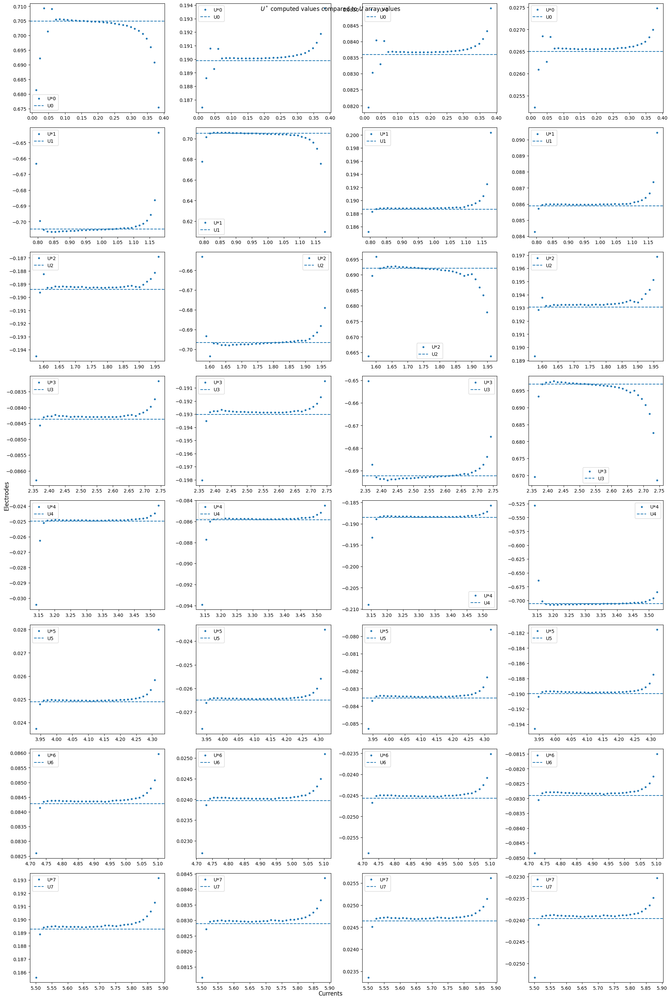

In [ ]:
t = theta[sorted_theta_vtx_index]
fig,axs = plt.subplots(L,l,figsize=(20,30))

for k in range(l):
  U_star = U_star_list[k]
  U_array = U_array_list[k]

  for j in range(L):
    theta_i,theta_f = electrodes.position[j]
    theta_j_idx = np.logical_and(t>=theta_i,t<=theta_f)#index of theta in electrode j
    axs[j][k].plot(t[theta_j_idx],U_star.real[theta_j_idx],label=f"U*{j}",linestyle='',marker='.')
    axs[j][k].axhline(U_array[j].real,label=f'U{j}',linestyle='--')
    axs[j][k].legend()
    # axs[j].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])

    # axs[1].plot(t,f(t),label="exact")
    # axs[1].plot(t,u_bdr_imag_array,label="calculated")
    # axs[1].set_title("imaginary part")
    # axs[1].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])
fig.suptitle("$U^*$ computed values compared to $U$ array values")
fig.supylabel("Electrodes")
fig.supxlabel("Currents")

fig.tight_layout()

plt.show()

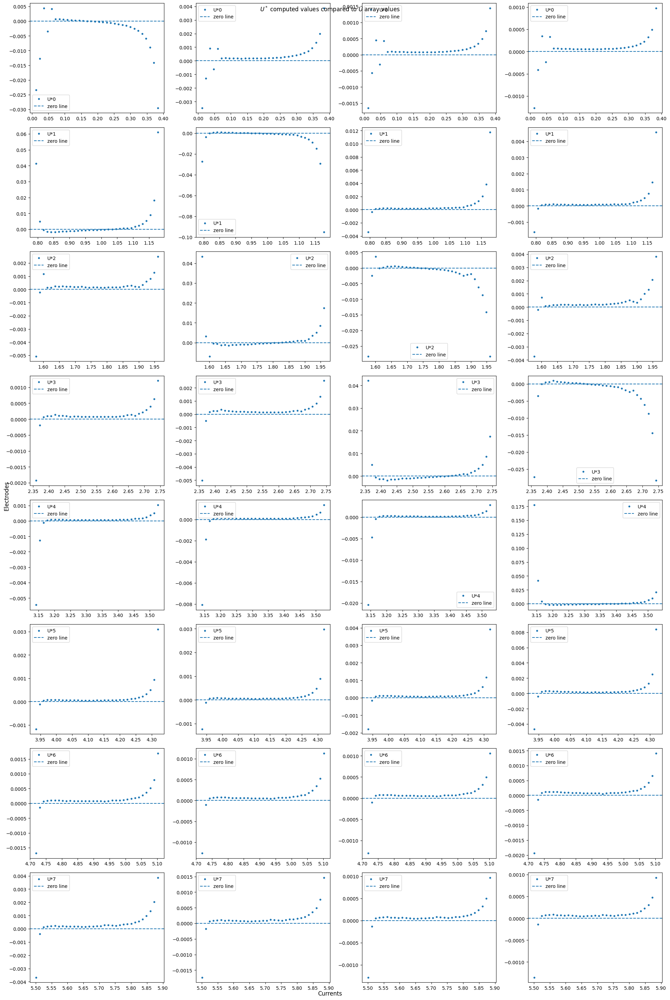

In [ ]:
t = theta[sorted_theta_vtx_index]
fig,axs = plt.subplots(L,l,figsize=(20,30))

for k in range(l):
  U_star = U_star_list[k]
  U_array = U_array_list[k]

  for j in range(L):
    theta_i,theta_f = electrodes.position[j]
    theta_j_idx = np.logical_and(t>=theta_i,t<=theta_f)#index of theta in electrode j
    # axs[j][k].plot(t[theta_j_idx],U_star.real[theta_j_idx],label=f"U*{j}",linestyle='',marker='.')
    # axs[j][k].axhline(U_array[j].real,label=f'U{j}',linestyle='--')
    axs[j][k].plot(t[theta_j_idx],U_star.real[theta_j_idx]-U_array[j].real,label=f"U*{j}",linestyle='',marker='.')
    axs[j][k].axhline(0,label=f'zero line',linestyle='--')
    axs[j][k].legend()
    # axs[j].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])

    # axs[1].plot(t,f(t),label="exact")
    # axs[1].plot(t,u_bdr_imag_array,label="calculated")
    # axs[1].set_title("imaginary part")
    # axs[1].set_xticks(np.linspace(0,2*np.pi,5),["0","$\\frac{\pi}{2}$","$\pi$","$\\frac{3\pi}{2}$","$2\pi$"])
fig.suptitle("$U^*$ computed values compared to $U$ array values")
fig.supylabel("Electrodes")
fig.supxlabel("Currents")

fig.tight_layout()

plt.show()

## Solving by PETSc

In [ ]:
# Assembling matrix A
A = PETSc.Mat()
A.createNest([[A1_matrix,     A2_matrix],
              [A2_matrix.transpose(), A4_matrix]])
A.setUp()
A.assemble()

In [ ]:

#Assembling b vector
I_vec = PETSc.Vec().create(comm=MPI.COMM_WORLD)
I_vec.setSizes(L)
I_vec.setUp()
I_vec.setArray(I)
# I_vec.setValues(range(N+1,N+L+1),I)
I_vec.assemble()

zero_vec = PETSc.Vec().create(comm=MPI.COMM_WORLD)
zero_vec.setSizes(N)
zero_vec.setUp()
zero_vec.setArray(np.zeros(N))
# zero_vec.setValues(range(N+1,N+L+1),I)
zero_vec.assemble()

b_nested = PETSc.Vec()
b_nested.createNest([zero_vec,I_vec])
b_nested.setUp()


TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [ ]:
# Solving problem

#Create solution vector
u_vec = PETSc.Vec().create(comm=MPI.COMM_WORLD)
u_vec.setSizes(N)
U_vec = PETSc.Vec().create(comm=MPI.COMM_WORLD)
U_vec.setSizes(L)
u_vec.setUp()
U_vec.setUp()
u_nested = PETSc.Vec().create(comm=MPI.COMM_WORLD)
u_nested.createNest([u_vec, U_vec]) #x0 and x1 are petsc vectors for your solution
u_nested.setUp()

ksp = PETSc.KSP().create(mesh.comm)
ksp.setType(PETSc.KSP.Type.CG)
ksp.setTolerances(rtol=1e-14)
ksp.setOperators(A)
ksp.setFromOptions()
ksp.solve(b_nested,u_nested)

# ksp = PETSc.KSP().create(mesh.comm)
# ksp.setOperators(A)
# ksp.setType("cg")
# ksp.setTolerances(rtol=1e-9)
# ksp.getPC().setType("fieldsplit")
# ksp.getPC().setFieldSplitType(PETSc.PC.CompositeType.ADDITIVE)

Error: error code 60
[0] KSPSolve() at /tmp/petsc-src/src/ksp/ksp/interface/itfunc.c:1082
[0] KSPSolve_Private() at /tmp/petsc-src/src/ksp/ksp/interface/itfunc.c:910
[0] KSPSolve_CG() at /tmp/petsc-src/src/ksp/ksp/impls/cg/cg.c:248
[0] KSP_MatMult() at /tmp/petsc-src/include/petsc/private/kspimpl.h:347
[0] MatMult() at /tmp/petsc-src/src/mat/interface/matrix.c:2608
[0] MatMult_Nest() at /tmp/petsc-src/src/mat/impls/nest/matnest.c:51
[0] MatMultAdd() at /tmp/petsc-src/src/mat/interface/matrix.c:2770
[0] Nonconforming object sizes
[0] Mat mat,Vec v1: global dim 1056 16

# Derivative

## Solving direct problem

In [ ]:
V = dolfinx.fem.FunctionSpace(mesh, ("CG", 1)) #creates function space in mesh
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
z_value = 0.025+0.0025j
x = ufl.SpatialCoordinate(mesh)

# gamma = dolfinx.fem.Constant(mesh, PETSc.ScalarType(1+1j))
gamma = dolfinx.fem.Function(V0)
expr = 1+1j+ ufl.exp(-(x[0]**2+x[1]**2)/0.2)
gamma.interpolate(dolfinx.fem.Expression(expr,V0.element.interpolation_points()))

I_all = current_method(L,4,method=2,value=1)

problem = DirectProblem(mesh, L,ds)

problem.set_problem(gamma, z_value)

u_list, U_list = problem.solve_problem_current(I_all)



## Directional derivative

I can be shown that the derivative $\mathcal W^{(i)} = F_i'(\gamma)\eta$ at some point $\gamma$ in direction $\eta$ is part of the solution $(\omega^{(i)}, \mathcal W^{(i)})$ of
$$
B_\gamma ((\omega^{(i)}, \mathcal W^{(i)}),(v,V)) = - \int \eta \nabla u^{(i)} \nabla v dx
$$
for each $(v,V)\in H1(\Omega)\oplus \mathbb C_\diamond^L$, where $u^{(i)}$ is solution of the direct problem for $\gamma$ by the $i$-th current pattern ($F_i(\gamma) = u^{(i)}$).

The discretization follows similar as above in the direct problem,
$$
A \hat \omega^{(i)}  = b^{(i)}
$$
where $A$ is the same matrix of direct problem and beeing

$$
\mathcal W^{(i)} = \begin{bmatrix} w^i_{pj} \end{bmatrix} =\begin{bmatrix}
- \sum_{n=1}^N u_n^{i} \int_{T_j} \nabla \Upsilon_p \nabla \Upsilon_n dx
\end{bmatrix}
$$

we set

$$
b^{(i)} = \mathcal W^{(i)} \hat \eta
$$

**Obs:** Here, as defined $b^{(i)}$ is a $N$ sized vector, but $A$ is a $N+L$ matrix. The following experiments are setting
$$
\hat b^{(i)}  = \begin{bmatrix}
b^{(i)} \\
0
\end{bmatrix}
$$

In [ ]:
#us
us = u_list[0]

#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the triangle with index 900 as 1, rest remain as 0

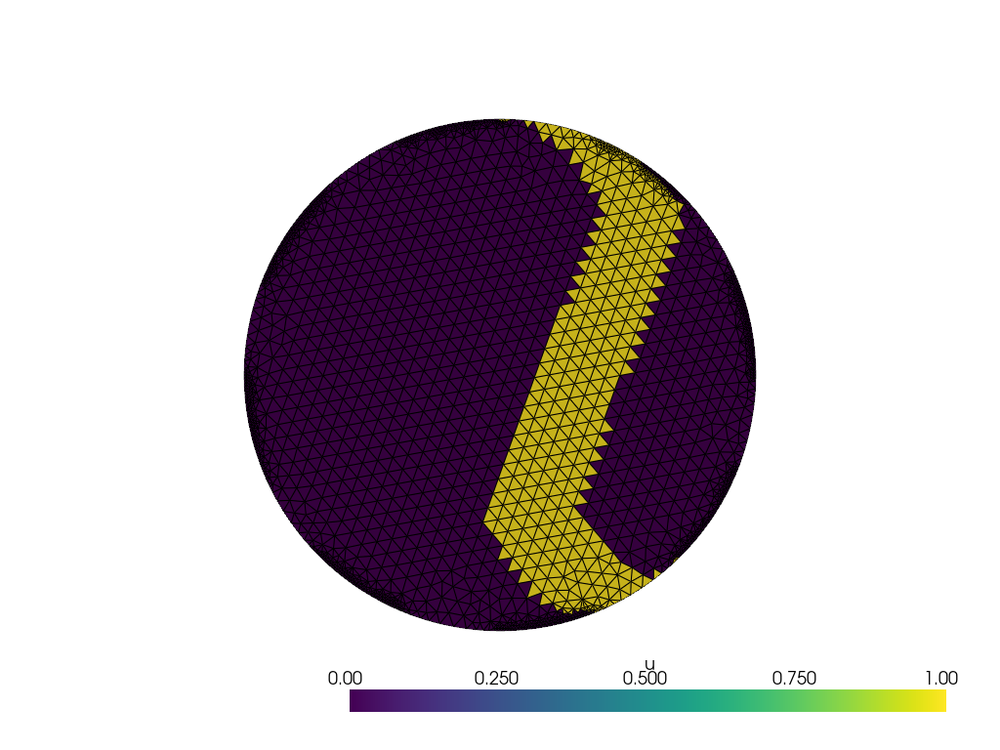

In [ ]:
plot_indicator_function(eta)

In [ ]:
#Create Trial and test functions
w = ufl.TrialFunction(V) #function u_h
v = ufl.TestFunction(V)

#creates object representing the gradient of w, us and v functions
gradw = ufl.grad(w)
gradv = ufl.grad(v)
gradus = ufl.grad(us)

#creating form
L_exp = - (eta * ufl.inner(gradus,gradv)) * ufl.dx
L_form = dolfinx.fem.form(L_exp)

#getting rhs vector
L_vector = dolfinx.fem.petsc.assemble_vector(L_form)
L_nparray = L_vector.getValues(range(L_vector.getSize()))

L_array = np.block([L_nparray,np.zeros(L)])

In [ ]:
ws, Ws = problem.solve_problem_vector([L_array])

### Derivative test

Here, we compare the calculated derivative $\omega^{(i)}$ with the numerical derivative, given by:
$$
\frac{F_i(\gamma + t\eta) - F_i(\gamma -t \eta)}{2t},
$$
for some $t\in \mathbb R_+^*$ close to $0$.

The proposed test is, from the previusly set $\gamma$ and $\eta$, create a sequence $t_k$ such that $t_k \to 0$, analysing the sequence
$$
e_k = \left \| \frac{F_i(\gamma + t_k\eta) - F_i(\gamma -t_k \eta)}{2t} - \omega^{(i)}\right \|_2
$$
calculating $F_i(\gamma + t_k\eta)$ and $F_i(\gamma - t_k\eta)$ in each step through the process described before.


In [ ]:
N = 30
err_array = np.zeros(N)
for i in range(N):
  t = 1/2**i

  problem.set_problem(gamma+t*eta, z_value)
  u_list_fwd, U_list_fwd = problem.solve_problem_current(I_all[0:1])

  problem.set_problem(gamma-t*eta, z_value)
  u_list_bwd, U_list_bwd = problem.solve_problem_current(I_all[0:1])

  err_array[i] = np.linalg.norm( (U_list_fwd[0] - U_list_bwd[0])/(2*t) - Ws[0])

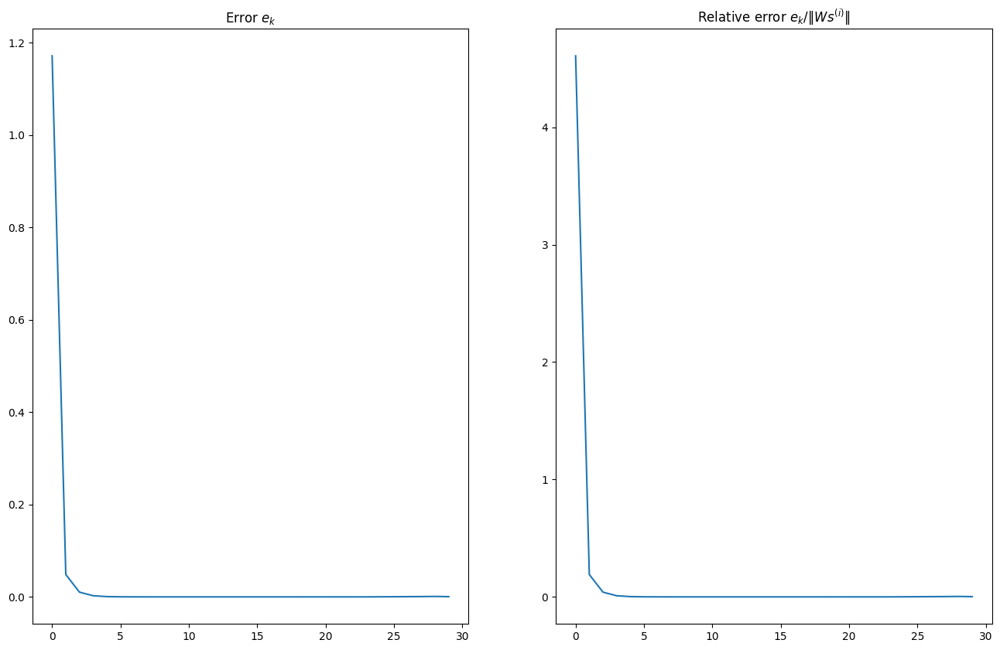

0.010240046832216323


In [ ]:
Ws_norm = np.linalg.norm(Ws[0])

fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array[0:40])
ax[0].set_title("Error $e_k$")
ax[1].plot(err_array[0:40]/Ws_norm)
ax[1].set_title("Relative error $e_k/\|Ws^{(i)}\|$")
plt.show()

print(max(err_array[2:]))

In [ ]:
N = 30
err_array_real = np.zeros(N)
err_array_imag = np.zeros(N)
for i in range(N):
  t = 1/2**i

  problem.set_problem(gamma+t*eta, z_value)
  u_list_fwd, U_list_fwd = problem.solve_problem_current(I_all[0:1])

  problem.set_problem(gamma-t*eta, z_value)
  u_list_bwd, U_list_bwd = problem.solve_problem_current(I_all[0:1])

  err_array_real[i] = np.linalg.norm( (U_list_fwd[0].real - U_list_bwd[0].real)/(2*t) - Ws[0].real)
  err_array_imag[i] = np.linalg.norm( (U_list_fwd[0].imag - U_list_bwd[0].imag)/(2*t) - Ws[0].imag)

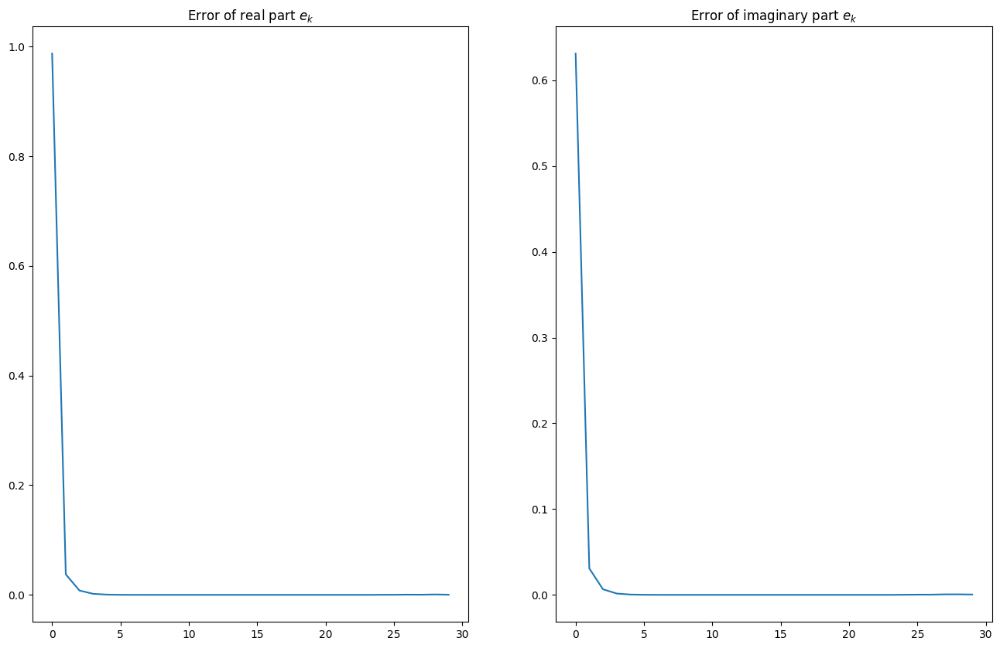

0.010240046832216323


In [ ]:
fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array_real[0:40])
ax[0].set_title("Error of real part $e_k$")
ax[1].plot(err_array_imag[0:40])
ax[1].set_title("Error of imaginary part $e_k$")
plt.show()

print(max(err_array[2:]))

<a name="computing-jacobian"></a>

## Computing Jacobian


### Traditional method

Here doing the usual method. General proceeding is:
- Create a generic function `xi` in `V0` space (discontinuos Garlekig degree 0). It will have a array of coefficients `xi.x.array` with size equal to number of dofs (cells)
- Iterate through every entry of `xi.x.array`, set as "1", then solve the derivative for it.


In other words, computes $F'(\gamma) \chi_i$ for each indicator base function $\chi_i$, through the variational form explored above
.

In [ ]:
#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the triangle with index 900 as 1, rest remain as 0

xi = dolfinx.fem.Function(V0, dtype=np.complex128)
M = xi.x.array.shape[0]
L = problem.L
l = len(u_list)

Jacobian = np.zeros((l*L,M),dtype=np.complex128)
for j in range(M):
  print("Starting iteration ",j)
  xi.x.array[j] = 1

  for i in range(l):
    us = u_list[i]

    w = ufl.TrialFunction(V) #function u_h
    v = ufl.TestFunction(V)

    #creates object representing the gradient of w, us and v functions
    gradw = ufl.grad(w)
    gradv = ufl.grad(v)
    gradus = ufl.grad(us)

    #creating form
    L_exp = - (xi * ufl.inner(gradus,gradv)) * ufl.dx
    L_form = dolfinx.fem.form(L_exp)

    #getting rhs vector
    L_vector = dolfinx.fem.petsc.assemble_vector(L_form)
    L_nparray = L_vector.getValues(range(L_vector.getSize()))
    L_array = np.block([L_nparray,np.zeros(L)])

    ws, Ws = problem.solve_problem_vector([L_array])

    Jacobian[i*L:(i+1)*L,j] = Ws[0]

  xi.x.array[j] = 0


NameError: name 'problem' is not defined

In [ ]:
# Testing concatenating multiple arrays at once
#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the triangle with index 900 as 1, rest remain as 0

xi = dolfinx.fem.Function(V0, dtype=np.complex128)
M = xi.x.array.shape[0]
L = problem.L
l = len(u_list)

L_matrix = []
for j in range(M):
  print("Starting iteration ",j)
  xi.x.array[j] = 1
  L_col = []
  for i in range(l):
    us = u_list[i]

    w = ufl.TrialFunction(V) #function u_h
    v = ufl.TestFunction(V)

    #creates object representing the gradient of w, us and v functions
    gradw = ufl.grad(w)
    gradv = ufl.grad(v)
    gradus = ufl.grad(us)

    #creating form
    L_exp = - (xi * ufl.inner(gradus,gradv)) * ufl.dx
    L_form = dolfinx.fem.form(L_exp)

    #getting rhs vector
    L_vector = dolfinx.fem.petsc.assemble_vector(L_form)
    L_nparray = L_vector.getValues(range(L_vector.getSize()))
    L_array = np.block([L_nparray,np.zeros(L)])
    L_col.append(L_array)
  L_matrix.append(L_col)
  xi.x.array[j] = 0


In [ ]:
for j in range(M):
  print("Iteration",j)
  for i in range(l):
    L_array = L_matrix[k][i]

problem.solve_problem_vector([L_array])

u_nest = sp.sparse.linalg.spsolve(self.A_op,self.A_np.T.conj()@b) #Solve A^*Au = b
u_array, U_array = u_nest[:self.N], u_nest[self.N:] #splitting array

# translating solutions (U = (U1 + S/L,...,UL + S/L)), with S = U1+...+UL
S = U_array.sum()
U_array -= S/self.L
u_array -= S/self.L

u_array_list.append(u_array)
U_list.append(U_array)

for u_array in u_array_list:
  u = dolfinx.fem.Function(self.V)
  u.x.array[:] = u_array
  u_list.append(u)

In [ ]:
np.savetxt("jacobian.csv", Jacobian, delimiter=",")
from google.colab import files
files.download("sample_data/california_housing_train.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Jacobian = np.loadtxt('/content/drive/MyDrive/IC - EITx/jacobian(1).csv',dtype=complex,delimiter=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First test, fixed a given $\eta$, will compare $F'(\gamma)\eta$ calculated with the $\omega |_{\partial \Omega}$ get through variational formulation

In [ ]:
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the triangle with index 900 as 1, rest remain as 0

In [ ]:
#Create Trial and test functions
w = ufl.TrialFunction(V) #function u_h
v = ufl.TestFunction(V)

us = u_list[0]
#creates object representing the gradient of w, us and v functions
gradw = ufl.grad(w)
gradv = ufl.grad(v)
gradus = ufl.grad(us)

#creating form
L_exp = - (eta * ufl.inner(gradus,gradv)) * ufl.dx
L_form = dolfinx.fem.form(L_exp)

#getting rhs vector
L_vector = dolfinx.fem.petsc.assemble_vector(L_form)
L_nparray = L_vector.getValues(range(L_vector.getSize()))

L_array = np.block([L_nparray,np.zeros(L)])

In [ ]:
ws, Ws = problem.solve_problem_vector([L_array])

In [ ]:
Jacobian = np.loadtxt('jacobian.csv',dtype=complex,delimiter=',')

FileNotFoundError: jacobian.csv not found.

In [ ]:
Jacobian.shape

(32, 3846)

In [ ]:
jacobianeta = Jacobian[:L,:] @ eta.x.array

error = jacobianeta - Ws[0]
normerror = np.linalg.norm(error)/np.linalg.norm(Ws[0])
print(normerror)

1.3863026824601594e-09


Next test is comparing with the numerical derivative. For this, we set a $t_k\to 0$ sequence and analyze the error:
$$
e_k = \left \| \frac{F(\gamma + t_k\eta) - F(\gamma -t_k \eta)}{2t} - F'(\gamma)\eta \right \|
$$

In [ ]:
N = 30
err_array = np.zeros(N)
err_array_real = np.zeros(N)
err_array_imag = np.zeros(N)
for i in range(N):
  t = 1/2**i

  problem.set_problem(gamma+t*eta, z_value)
  u_list_fwd, U_list_fwd = problem.solve_problem_current(I_all)

  problem.set_problem(gamma-t*eta, z_value)
  u_list_bwd, U_list_bwd = problem.solve_problem_current(I_all)

  err_array[i] = np.linalg.norm( (np.concatenate(U_list_fwd) - np.concatenate(U_list_bwd))/(2*t) - jacobianeta)

  err_array_real[i] = np.linalg.norm( (np.concatenate(U_list_fwd).real - np.concatenate(U_list_bwd).real)/(2*t) - jacobianeta.real)
  err_array_imag[i] = np.linalg.norm( (np.concatenate(U_list_fwd).imag - np.concatenate(U_list_bwd).imag)/(2*t) - jacobianeta.imag)

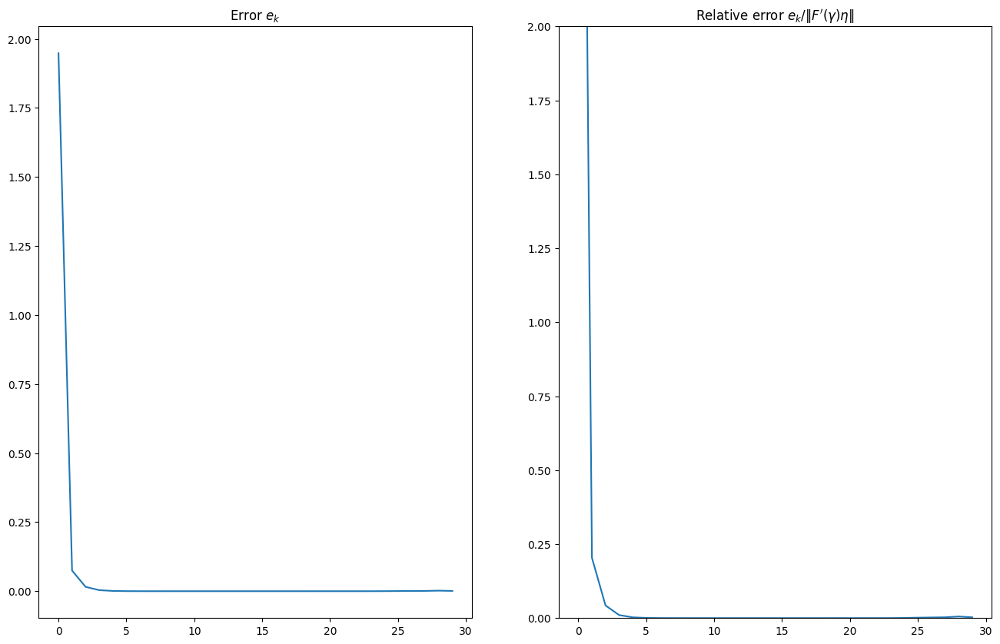

0.01563244542533103


In [ ]:
Ws_norm = np.linalg.norm(jacobianeta)

fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array[0:40])
ax[0].set_title("Error $e_k$")
ax[1].plot(err_array[0:40]/Ws_norm)
ax[1].set_title("Relative error $e_k/\|F'(\gamma)\eta\|$")
ax[1].set_ylim(0,2)
plt.show()

print(max(err_array[2:]))

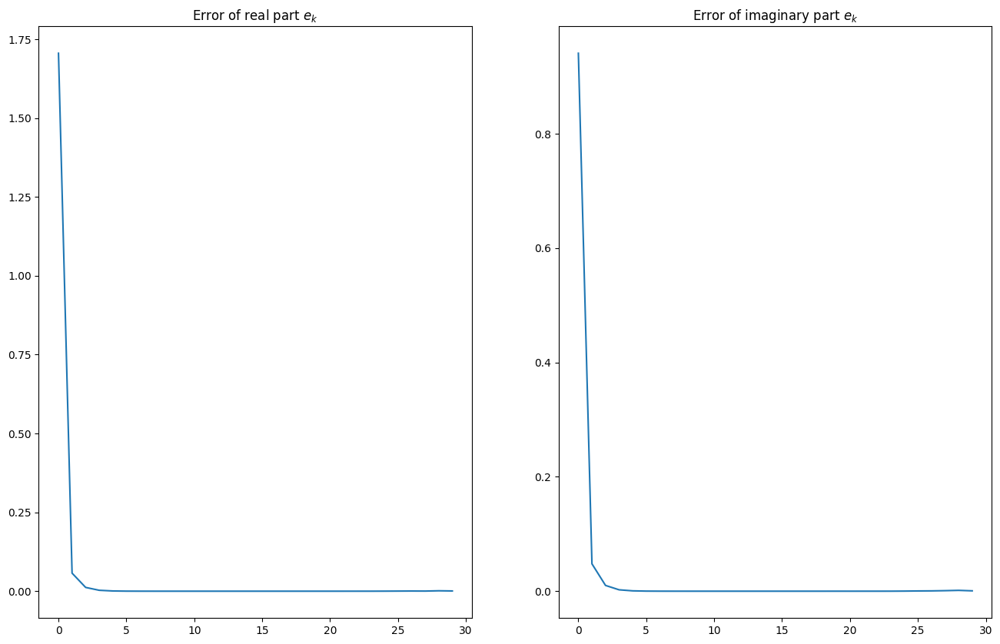

0.01563244542533103


In [ ]:
fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array_real[0:40])
ax[0].set_title("Error of real part $e_k$")
ax[1].plot(err_array_imag[0:40])
ax[1].set_title("Error of imaginary part $e_k$")
plt.show()

print(max(err_array[2:]))

### Alternative method

Now, computing by the Polydorides technique. Let $(y_i, Y_i) \in H^1(\Omega) \oplus \mathbb C_\diamond^L$ be the solution of
$$
B_\gamma((y^{(i)},Y^{(i)}),(v,V)) =  d_i \cdot V
$$
beeing $d_i$ the $i-th$ vector of canonical basis of $\mathbb C^L$. Then, for the $i-th$ current and each triangle $T_j$:
$$
F'_{i}(\gamma)\chi_j = - \left(\int_{T_j} \nabla u^{i} \cdot \nabla y^{(1)} dx, \dots, \int_{T_j} \nabla u^{i} \cdot \nabla y^{(L)}dx\right)
$$.

Notice that, as in the the discretion the gradients become constant at each triangle, we have
$$
\int_{T_j} \nabla u^{(i)} \cdot \nabla y^{(L)} dx = \nabla u^{(i)}_j \cdot \nabla y^{(k)}_j \int_{T_j}dx = \nabla u^{(i)}_j \cdot \nabla y^{(k)}_j A(T_j).
$$

With this, we first comput the discretized $\nabla u^{(i)},\nabla y^{(k)}$ coefficient arrays through method `compute_gradient` (which does it by geometric analytic techniques). Next, we compute an array with the area of each triangle. Then, iterate through the index to compute each column.

Computing Jacobian as: Get $(y^j, Y^J)$ as solution of
$$
B_{\overline \gamma} ((y,Y),(v,V)) = \langle d^j, V\rangle
$$
being $d^j$ the $j$-th canonical base element of $\mathbb C^L$

Then, being $u^i$ solution of direct problem
$$
B_{\gamma} ((u,U),(v,V)) = \langle I^i, V\rangle
$$
we compute
$$
F_i'(\gamma)\chi_{T_j} = - \left(\int_{T_j} \nabla u^{i} \cdot \nabla \overline y^{(1)} dx, \dots, \int_{T_j} \nabla u^{i} \cdot \nabla \overline y^{(L)}dx\right)
$$

In [ ]:
gamma_conj = dolfinx.fem.Function(V0)
gamma_conj.x.array[:] = gamma.x.array.conj()
problem2 = DirectProblem(mesh,L,ds)
problem2.set_problem(gamma_conj,np.conj(z_value))

u_conj_list, U_conj_list = problem2.solve_problem_current(I_all)

In [ ]:
id_matrix = np.eye(L) -1/L
y_list, Y_list = problem2.solve_problem_current(list(id_matrix))
grad_y_list = [compute_gradient(y_func) for y_func in y_list]

In [ ]:
L = problem.L
gradu_list =[compute_gradient(us) for us in u_list]

In [ ]:
v = ufl.TrialFunction(V0)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
print(cell_area_array)

[7.61960960e-05 6.13961046e-05 6.13961046e-05 ... 6.11338264e-05
 6.20261002e-05 6.13961046e-05]


In [ ]:
np.sum(cell_area_array)

3.1411620793434194

In [ ]:
us = u_list[0]
y = y_list[0]
gradprod = dolfinx.fem.Function(V0)
expr = -ufl.inner(ufl.grad(us),ufl.grad(y))
gradprod.interpolate(dolfinx.fem.Expression(expr,V0.element.interpolation_points()))

l=4
# for i in range(l):
#   gradus = gradu_list[i]
#   graduj = gradus[0]
#   # jac_column_j = [
#   #     dolfinx.fem.assemble_scalar(dolfinx.fem.form(-xi*ufl.inner(ufl.grad(u_list[i]),ufl.grad(y))*ufl.dx))
#   #     for y in y_list
#   #   ]
#   jac_column_j = [np.vdot(grady[0],graduj) for grady in grad_y_list]

l = len(I_all)
for h in range(1): #For each experiment
  derivada=[]
  for j in range(L): #for each electrode
    derivada.append(-1*np.sum(gradu_list[h]*grad_y_list[j].conj(), axis=1))

np.linalg.norm(derivada[0] - gradprod.x.array)

5.295206898204999e-13

In [ ]:
%%time
#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
M = V0.dofmap.index_map.size_global
l = len(u_list)
xi = dolfinx.fem.Function(V0)

Jacobian_alt = np.zeros((l*L,M),dtype=np.complex128)
for j in range(M):
  # print("Starting iteration ",j)

  xi.x.array[j] = 1
  for i in range(l):
    gradus = gradu_list[i]
    graduj = gradus[j]
    # jac_column_j = [
    #     dolfinx.fem.assemble_scalar(dolfinx.fem.form(-xi*ufl.inner(ufl.grad(u_list[i]),ufl.grad(y))*ufl.dx))
    #     for y in y_list
    #   ]
    jac_column_j = [np.vdot(grady[j],graduj)*cell_area_array[j] for grady in grad_y_list]
    Jacobian_alt[L*i:L*(i+1),j] = - np.array(jac_column_j)

  xi.x.array[j] = 0


CPU times: user 486 ms, sys: 1.79 ms, total: 488 ms
Wall time: 541 ms


Comparing same process, but each $\int_{T_j} \nabla u^{i} \cdot \nabla \overline y^{(1)} dx$ is computed through Fenics integration, instead of analytical gradients

In [ ]:
%%time
#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
M = V0.dofmap.index_map.size_global
l = len(u_list)
xi = dolfinx.fem.Function(V0)

Jacobian_alt0 = np.zeros((l*L,M),dtype=np.complex128)
for j in range(M):
  # print("Starting iteration ",j)

  xi.x.array[j] = 1
  for i in range(l):
    # gradus = gradu_list[i]
    # graduj = gradus[j]
    jac_column_j = [
        dolfinx.fem.assemble_scalar(dolfinx.fem.form(-xi*ufl.inner(ufl.grad(u_list[i]),ufl.grad(y))*ufl.dx))
        for y in y_list
      ]
    # jac_column_j = [np.vdot(grady[j],graduj)*cell_area_array[j] for grady in grad_y_list]
    Jacobian_alt0[L*i:L*(i+1),j] = np.array(jac_column_j)

  xi.x.array[j] = 0


CPU times: user 4min 17s, sys: 16 s, total: 4min 33s
Wall time: 4min 59s


In [ ]:
np.linalg.norm(Jacobian_alt-Jacobian_alt0)/np.linalg.norm(Jacobian_alt)

2.5603658392209137e-15

Computing Jacobian as: Get $(y^j, Y^J)$ as solution of
$$
B_{\gamma} ((y,Y),(v,V)) = \langle d^j, V\rangle
$$
being $d^j$ the $j$-th canonical base element of $\mathbb C^L$

Then, being $u^i$ solution of adjoint problem
$$
B_{\overline \gamma} ((u,U),(v,V)) = \langle I^i, V\rangle
$$
we compute
$$
F_i'(\gamma)\chi_{T_j} = - \left(\int_{T_j} \nabla \overline u^{i} \cdot \nabla  y^{(1)} dx, \dots, \int_{T_j} \nabla \overline u^{i} \cdot \nabla y^{(L)}dx\right)
$$

In [ ]:
id_matrix = np.eye(L)
y_list, Y_list = problem.solve_problem_current(list(id_matrix))
grad_y_list = [compute_gradient(y_func) for y_func in y_list]

In [ ]:
L = problem.L
gradu_list =[compute_gradient(us) for us in u_conj_list]

In [ ]:
v = ufl.TrialFunction(V0)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
print(cell_area_array)

[7.61960960e-05 6.13961046e-05 6.13961046e-05 ... 6.11338264e-05
 6.20261002e-05 6.13961046e-05]


In [ ]:
# %%time
#eta
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
M = V0.dofmap.index_map.size_global
l = len(u_list)

Jacobian_alt1 = np.zeros((l*L,M),dtype=np.complex128)
for j in range(M):
  # print("Starting iteration ",j)
  for i in range(l):
    gradus = gradu_list[i]
    graduj = gradus[j]
    jac_column_j = [np.vdot(graduj,grady[j])*cell_area_array[j] for grady in grad_y_list]
    Jacobian_alt1[L*i:L*(i+1),j] = - np.array(jac_column_j)


## Comparisons

### Comparison between the two alternative Jacobian:

In [ ]:
Jacobian_alt0-Jacobian_alt1

array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]])

### Comparison with the traditional Jacobian:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Jacobian = np.loadtxt('/content/drive/MyDrive/IC - EITx/jacobian(1).csv',dtype=complex,delimiter=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Comparing matrices
print("Difference Norm",np.linalg.norm(Jacobian-Jacobian_alt))
print("Relative error",np.linalg.norm(Jacobian-Jacobian_alt)/np.linalg.norm(Jacobian))
print("Max error",np.max(abs(Jacobian-Jacobian_alt)))

#Comparing applied to some eta
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the triangle with index 900 as 1, rest remain as 0
print("\nDifference norm between Jacobians applied to same eta", np.linalg.norm(Jacobian@eta.x.array-Jacobian_alt@eta.x.array))
print("\nRelative difference norm ", np.linalg.norm(Jacobian@eta.x.array-Jacobian_alt@eta.x.array)/np.linalg.norm(Jacobian_alt@eta.x.array))

Difference Norm 3.615217348667686e-11
Relative error 7.347547596498348e-10
Max error 5.614978951603561e-12

Difference norm between Jacobians applied to same eta 5.226333934586697e-10

Relative difference norm  1.4273187443087164e-09


### Alternative: Splitting real and imaginary

In [ ]:
#Comparing matrices
print("Real part error")
print("Difference Norm",np.linalg.norm(Jacobian.real-Jacobian_alt.real))
print("Relative error",np.linalg.norm(Jacobian.real-Jacobian_alt.real)/np.linalg.norm(Jacobian.real))
print("Max error",np.max(abs(Jacobian.real-Jacobian_alt.real)))

#Comparing matrices
print("\nImaginary part error")
print("Difference Norm",np.linalg.norm(Jacobian.imag-Jacobian_alt.imag))
print("Relative error",np.linalg.norm(Jacobian.imag-Jacobian_alt.imag)/np.linalg.norm(Jacobian.imag))
print("Max error",np.max(abs(Jacobian.imag-Jacobian_alt.imag)))

Real part error
Difference Norm 3.709264099235352e-12
Relative error 9.066630060608335e-10
Max error 5.082884525602072e-13

Imaginary part error
Difference Norm 3.5961382171058205e-11
Relative error 7.334167732880724e-10
Max error 5.612551656070108e-12


In [ ]:
eta = dolfinx.fem.Function(V0, dtype=np.complex128) #create a null function in the space
eta.x.array[900:1500] = 1+1j #define the indexed triangle as 1, rest remain as 0
jacobianeta = Jacobian_alt@eta.x.array
print("Norm of J_alt @ eta",np.linalg.norm(jacobianeta))

Norm of J_alt @ eta 0.37136227664160965


First compute $F'(\gamma)\eta$ derivate by variational formulae, then compare to Jacobian applied to $\eta$ array

In [ ]:
ws_list, Ws_list = problem.directional_derivative(eta, u_list)

Ws_array = np.array(Ws_list).flatten()
print("Error with Jacobian", np.linalg.norm(Jacobian@eta.x.array - Ws_array))
print("Relative error with Jacobian",np.linalg.norm(Jacobian@eta.x.array - Ws_array)/np.linalg.norm(Ws_array))
print("\nError with Jacobian_alt", np.linalg.norm(Jacobian_alt@eta.x.array - Ws_array))
print("Relative error with Jacobian_alt",np.linalg.norm(Jacobian_alt@eta.x.array - Ws_array)/np.linalg.norm(Ws_array))


Error with Jacobian 5.224198978965463e-10
Relative error with Jacobian 1.4267356850900408e-09

Error with Jacobian_alt 0.061915512552055206
Relative error with Jacobian_alt 0.1690920877522753


### Numerical derivative test

In [ ]:
N = 30
err_array = np.zeros(N)
err_array_real = np.zeros(N)
err_array_imag = np.zeros(N)
gamma_kplus = dolfinx.fem.Function(V0)
gamma_kminus = dolfinx.fem.Function(V0)

for i in range(N):
  t = 1/2**i
  gamma_kplus.x.array[:] = gamma.x.array+t*eta.x.array
  gamma_kminus.x.array[:] = gamma.x.array-t*eta.x.array
  problem.set_problem(gamma_kplus, z_value)

  u_list_fwd, U_list_fwd = problem.solve_problem_current(I_all)

  problem.set_problem(gamma_kminus, z_value)
  u_list_bwd, U_list_bwd = problem.solve_problem_current(I_all)

  err_array[i] = np.linalg.norm( (np.concatenate(U_list_fwd) - np.concatenate(U_list_bwd))/(2*t) - jacobianeta)

  err_array_real[i] = np.linalg.norm( (np.concatenate(U_list_fwd).real - np.concatenate(U_list_bwd).real)/(2*t) - jacobianeta.real)
  err_array_imag[i] = np.linalg.norm( (np.concatenate(U_list_fwd).imag - np.concatenate(U_list_bwd).imag)/(2*t) - jacobianeta.imag)

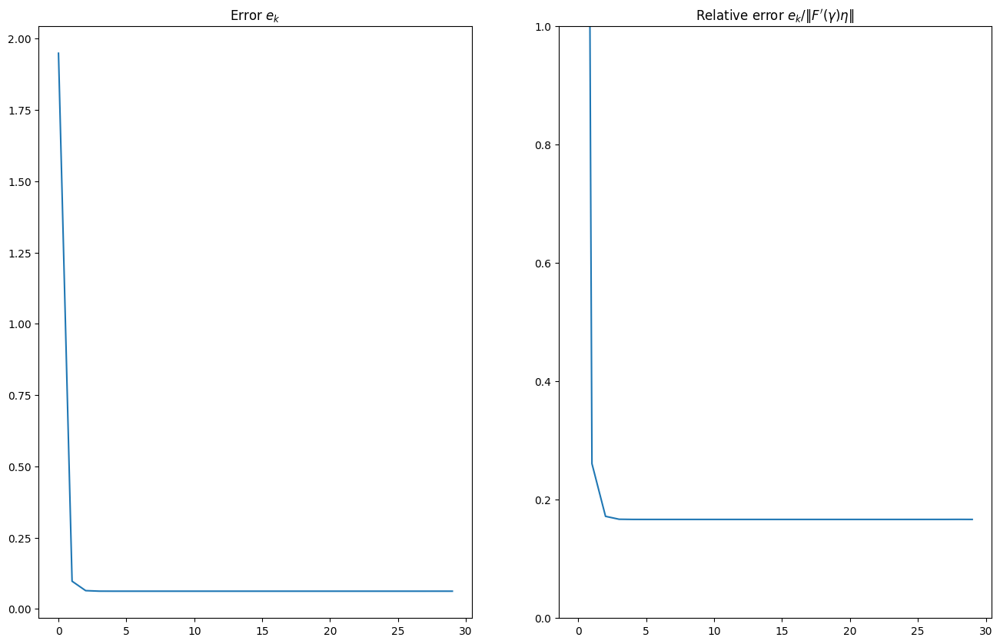

0.0638584689831724


In [ ]:
Ws_norm = np.linalg.norm(jacobianeta)

fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array[0:40])
ax[0].set_title("Error $e_k$")
ax[1].plot(err_array[0:40]/Ws_norm)
ax[1].set_title("Relative error $e_k/\|F'(\gamma)\eta\|$")
ax[1].set_ylim(0,1)
plt.show()

print(max(err_array[2:]))

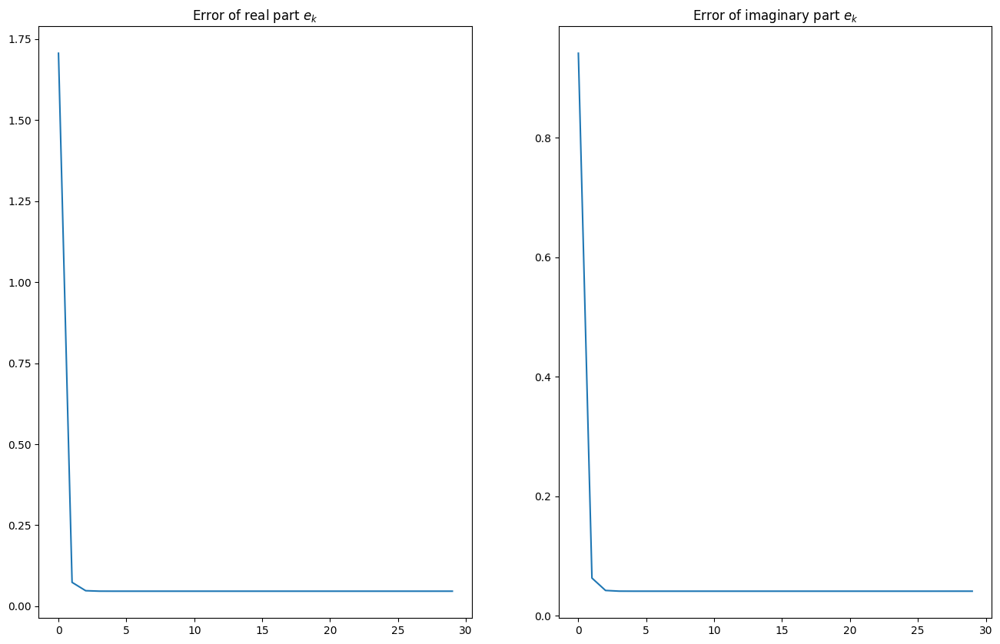

0.0638584689831724


In [ ]:
fig,ax = plt.subplots(1,2,figsize= (16,10))

ax[0].plot(err_array_real[0:40])
ax[0].set_title("Error of real part $e_k$")
ax[1].plot(err_array_imag[0:40])
ax[1].set_title("Error of imaginary part $e_k$")
plt.show()

print(max(err_array[2:]))

# Adjoint

Given $\sigma = (\sigma^{(1)},\dots,\sigma^{(\ell)}) \in \mathbb (\mathbb C^L_\diamond)^\ell$, for each $i \in \{1,\dots,\ell\}$ we get the solution $(\psi^{(i)},\Psi^{(i)})$ for
$$
B_{\overline \gamma, \overline z}((u,U)(v,V)) = \langle \sigma^{(i)}, V \rangle_{\mathbb C^L}
$$

and get $F'(\gamma)^* \sigma^{(i)} = - \nabla \overline u^{(i)} \nabla \psi^{(i)}$

Then,
$$
F'(\gamma)^* \sigma = - \sum_i^\ell \nabla \overline u^{(i)} \nabla \psi^{(i)}
$$

## Direct problem

In [ ]:
#Solving direct problem
V = dolfinx.fem.FunctionSpace(mesh, ("CG", 1)) #creates function space in mesh
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
z_value = 0.025+0.0025j
x = ufl.SpatialCoordinate(mesh)

# gamma = dolfinx.fem.Constant(mesh, PETSc.ScalarType(1+1j))
gamma = dolfinx.fem.Function(V0)
expr = 1+1j+ ufl.exp(-(x[0]**2+x[1]**2)/0.2)
gamma.interpolate(dolfinx.fem.Expression(expr,V0.element.interpolation_points()))

I_all = current_method(L,4,method=2,value=1)
problem = DirectProblem(mesh, L, ds)
problem.set_problem(gamma, z_value)
u_list, U_list = problem.solve_problem_current(I_all)

l=4

In [ ]:
problem.setAdjointProblem()
# u_conj2, U_conj2 = problem.problem_adj.solve_problem_current(I_all)

## Single current

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Jacobian = np.loadtxt('/content/drive/MyDrive/IC - EITx/jacobian(1).csv',dtype=complex,delimiter=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# setting sigma_i
sigma_i = np.zeros(L,dtype=complex)
sigma_i[0] = 1+1j
sigma_i[5] = -1-1j
print(sigma_i)

[ 1.+1.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.-1.j  0.+0.j  0.+0.j]


In [ ]:
eta = dolfinx.fem.Function(V0)
eta.x.array[200:800] = 1+1j
weta, Weta = problem.directional_derivative(eta,u_list)

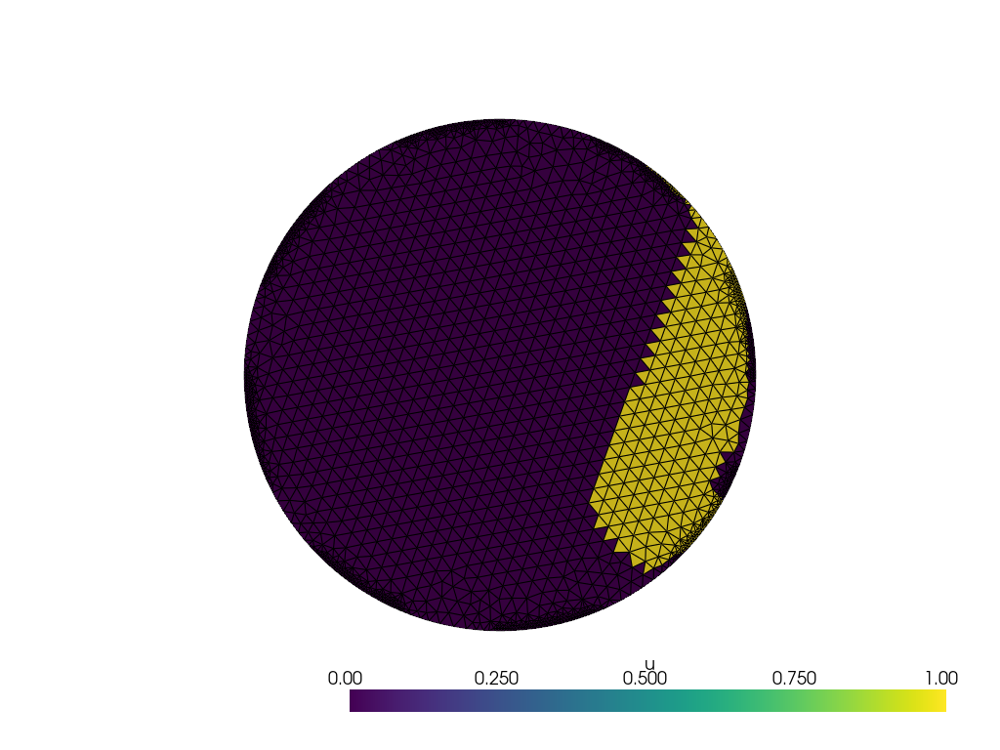

In [ ]:
plot_indicator_function(eta)

In [ ]:
psi_list, Psi_list  = problem.problem_adj.solve_problem_current([sigma_i])
grad_psi_list = [compute_gradient(psi) for psi in psi_list]
grad_u_list = [compute_gradient(u) for u in u_list]

graduj = grad_u_list[0]
gradpsij = grad_psi_list[0]

adj_i = dolfinx.fem.Function(V0)
adj_i_array = np.zeros_like(adj_i.x.array)
for k in range(adj_i_array.shape[0]):
  adj_i_array[k] = - np.vdot(graduj[k],gradpsij[k])
adj_i.x.array[:] = adj_i_array

In [ ]:
#comparing with jacobian apllied to vector
jacobian_adj = dolfinx.fem.Function(V0)
jacobian_adj.x.array[:] = Jacobian[:L,:].T.conj()@sigma_i

form_error = dolfinx.fem.form(ufl.inner(adj_i-jacobian_adj, adj_i-jacobian_adj)*ufl.dx)
value_error = dolfinx.fem.assemble_scalar(form_error)**0.5

form_norm = dolfinx.fem.form(ufl.inner(adj_i, adj_i)*ufl.dx)
value_norm = dolfinx.fem.assemble_scalar(form_norm)**0.5


print("L2 error norm: ",value_error)
print("L2 error norm (relative): ",value_error/value_norm)

L2 error norm:  (2.956688848303038+0j)
L2 error norm (relative):  (0.999336406134645+0j)


In [ ]:
Jacobian[:L,:].shape

(8, 3846)

In [ ]:
#comparing inner products
form_p1 = dolfinx.fem.form(ufl.inner(eta, adj_i)*ufl.dx)
value_p1 = dolfinx.fem.assemble_scalar(form_p1)

value_p2 = np.vdot(sigma_i, Jacobian[:L,:]@eta.x.array)

print("<eta, F'(gamma)* \sigma>=", value_p1)
print("< F'(gamma) \eta, \sigma>=", value_p2)

print("Error=",value_p1-value_p2)
print("Error norm=",abs(value_p1-value_p2))

<eta, F'(gamma)* \sigma>= (-0.02112851099395739+0.4661337770648447j)
< F'(gamma) \eta, \sigma>= (-0.021128510995571947+0.46613377707037235j)
Error= (1.6145591807958937e-12-5.527633906154961e-12j)
Error norm= 5.758605555928124e-12


In [ ]:
#testing for different random sigma_i
for j in range(10):
  #generate random sigma with sum 0
  sigma_i = np.random.rand(L) * np.random.randint(1,20)
  sigma_i -= np.sum(sigma_i)/L
  print("Sigma: ", sigma_i)

  #solve adjoint problem and compute gradients
  psi_list, Psi_list  = problem2.solve_problem_current([sigma_i])
  grad_psi_list = [compute_gradient(psi) for psi in psi_list]
  grad_u_list = [compute_gradient(u) for u in u_list]

  #selects only first gradient from each list
  graduj = grad_u_list[0]
  gradpsij = grad_psi_list[0]

  #compute adjoint
  adj_i = dolfinx.fem.Function(V0)
  adj_i_array = np.zeros_like(adj_i.x.array)
  for k in range(adj_i_array.shape[0]):
    adj_i_array[k] = - np.vdot(graduj[k],gradpsij[k])
  adj_i.x.array[:] = adj_i_array

  #comparing inner products
  form_p1 = dolfinx.fem.form(ufl.inner(eta, adj_i)*ufl.dx)
  value_p1 = dolfinx.fem.assemble_scalar(form_p1)
  value_p2 = np.vdot(sigma_i, Weta[0])

  print("<eta, F'(gamma)* \sigma>=", value_p1)
  print("< F'(gamma) \eta, \sigma>=", value_p2)

  print("Error=",value_p1-value_p2)
  print("Error norm=",abs(value_p1-value_p2))
  print("\n")

Sigma:  [ 0.72035079  2.85875948  1.1225566  -2.72892536 -2.96381807  4.29323271
 -1.51613948 -1.78601667]
<eta, F'(gamma)* \sigma>= (-0.013693541497176543+0.005589388680139824j)
< F'(gamma) \eta, \sigma>= (-0.013693541496047401+0.0055893886794723124j)
Error= (-1.1291419188541596e-12+6.675111852150195e-13j)
Error norm= 1.311690762070395e-12


Sigma:  [ 0.05024124  4.0075917   3.6605836  -1.97011586 -2.82583382 -2.41122736
 -4.6531728   4.1419333 ]
<eta, F'(gamma)* \sigma>= (-0.024161136147553334+0.0024176642618754306j)
< F'(gamma) \eta, \sigma>= (-0.02416113614669292+0.002417664261112909j)
Error= (-8.604124357436405e-13+7.625215563134002e-13j)
Error norm= 1.1496732942122794e-12


Sigma:  [ 0.21673171 -2.57295615  4.50553882  2.3999408  -2.31505646 -1.61844069
  2.90965131 -3.52540934]
<eta, F'(gamma)* \sigma>= (0.05026211909080745-0.03539396278740773j)
< F'(gamma) \eta, \sigma>= (0.050262119088015006-0.035393962784861316j)
Error= (2.7924468293250015e-12-2.546414468174163e-12j)
Error no

## Multiple currents

In [ ]:
# setting sigma_i
sigma_list = [np.zeros(L,dtype=complex) for i in range(l)]
for i in range(l):
  sigma_list[i][0] = 1 +1j
  sigma_list[i][2+i] = -1 -1j

print(sigma_list)

[array([ 1.+1.j,  0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        0.+0.j]), array([ 1.+1.j,  0.+0.j,  0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j,  0.+0.j,
        0.+0.j]), array([ 1.+1.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j,
        0.+0.j]), array([ 1.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.-1.j,  0.+0.j,
        0.+0.j])]


In [ ]:
eta = dolfinx.fem.Function(V0)
eta.x.array[:] = 1+1j
eta.x.array[200:800] = 2+2j
weta, Weta = problem.directional_derivative(eta,u_list)

In [ ]:
psi_list, Psi_list  = problem.problem_adj.solve_problem_current(sigma_list)
grad_psi_list = [compute_gradient(psi) for psi in psi_list]
grad_u_list = [compute_gradient(u) for u in u_list]
adj = dolfinx.fem.Function(V0)
adj_j_array = np.zeros_like(adj.x.array)

for j in range(l):
  graduj = grad_u_list[j]
  gradpsij = grad_psi_list[j]

  for k in range(adj_j_array.shape[0]):
    adj_j_array[k] = - np.vdot(graduj[k],gradpsij[k])

  adj.x.array[:] += adj_j_array


In [ ]:
problem.

In [ ]:
sigma_array = np.array(sigma_list).flatten()
sigma_array

array([ 1.+1.j,  0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        0.+0.j,  1.+1.j,  0.+0.j,  0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j,
        0.+0.j,  0.+0.j,  1.+1.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.-1.j,
        0.+0.j,  0.+0.j,  0.+0.j,  1.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,
        0.+0.j, -1.-1.j,  0.+0.j,  0.+0.j])

In [ ]:
#comparing with jacobian apllied to vector
jacobian_adj = dolfinx.fem.Function(V0)
jacobian_adj.x.array[:] = Jacobian.T.conj()@sigma_array

form_error = dolfinx.fem.form(ufl.inner(adj-jacobian_adj, adj-jacobian_adj)*ufl.dx)
value_error = dolfinx.fem.assemble_scalar(form_error)**0.5

form_norm = dolfinx.fem.form(ufl.inner(adj, adj)*ufl.dx)
value_norm = dolfinx.fem.assemble_scalar(form_norm)**0.5


print("L2 error norm: ",value_error)
print("L2 error norm (relative): ",value_error/value_norm)

L2 error norm:  (1.0186936301844618+0j)
L2 error norm (relative):  (0.999205925604671+0j)


In [ ]:
plot_indicator_function(adj)

In [ ]:
#comparing inner products
form_p1 = dolfinx.fem.form(ufl.inner(eta, adj)*ufl.dx)
value_p1 = dolfinx.fem.assemble_scalar(form_p1)

# value_p2 = np.vdot(sigma_array, np.array(Weta))
value_p2 = np.vdot(sigma_array, Jacobian@eta.x.array)

print("<eta, F'(gamma)* \sigma>=", value_p1)
print("< F'(gamma) \eta, \sigma>=", value_p2)

print("Error=",value_p1-value_p2)
print("Error norm=",abs(value_p1-value_p2))

<eta, F'(gamma)* \sigma>= (-0.01787938079054892+1.759153818145207j)
< F'(gamma) \eta, \sigma>= (-0.2311616811208912+1.9060399000011767j)
Error= (0.2132823003303423-0.14688608185596963j)
Error norm= 0.2589688411319032


In [ ]:
#comparing inner products
form_p1 = dolfinx.fem.form(ufl.inner(eta, jacobian_adj)*ufl.dx)
value_p1 = dolfinx.fem.assemble_scalar(form_p1)

# value_p2 = np.vdot(sigma_array, np.array(Weta))
value_p2 = np.vdot(sigma_array, Jacobian@eta.x.array)

print("<eta, F'(gamma)* \sigma>=", value_p1)
print("< F'(gamma) \eta, \sigma>=", value_p2)

print("Error=",value_p1-value_p2)
print("Error norm=",abs(value_p1-value_p2))

<eta, F'(gamma)* \sigma>= (-2.8454676897548093e-05+0.0005199699062484604j)
< F'(gamma) \eta, \sigma>= (-0.030162543368805472+0.505002240873569j)
Error= (0.030134088691907923-0.5044822709673206j)
Error norm= 0.505381464857623


## Adjoint Matrix

In [ ]:
V0 = dolfinx.fem.FunctionSpace(mesh, ("DG",0))
M = V0.dofmap.index_map.size_global
adj_matrix = np.zeros((M, l*L),dtype=np.complex128)

id_matrix = np.eye(l*L)

for j in range(l*L):
  sigma_j = np.split(id_matrix[j],l)
  adj = problem.adjoint(sigma_j,u_list)
  adj_matrix[:,j] = adj.x.array

KeyboardInterrupt: 

### Comparing applied to vector

In [ ]:
# setting sigma_i
sigma_list = [np.zeros(L,dtype=complex) for i in range(l)]
for i in range(l):
  sigma_list[i][0] = 1 +1j
  sigma_list[i][2+i] = -1 -1j


adj_variational = problem.adjoint(sigma_list, u_list)

adj_func = dolfinx.fem.Function(V0)
adj_func.x.array[:] = adj_matrix @ np.array(sigma_list).flatten()

In [ ]:
np.linalg.norm(adj_func.x.array - adj_variational.x.array)/np.linalg.norm(adj_variational.x.array)

4.983818802626226e-13

In [ ]:
err = dolfinx.fem.Function(V0)
err.x.array[:] = adj_func.x.array - adj_variational.x.array
dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(err,err)*ufl.dx))

(3.679087141052645e-25+0j)

### Comparing to Jacobian

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Jacobian = np.loadtxt('/content/drive/MyDrive/IC - EITx/jacobian(1).csv',dtype=complex,delimiter=',')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
np.linalg.norm(Jacobian.T.conj()-adj_matrix)

162.38632734441234

# Inverse Problem

## Setting

In [5]:
l=7
Ve = basix.ufl.element('Lagrange', "triangle", degree=1, shape=())
V = dolfinx.fem.functionspace(mesh, Ve) #creates function space in mesh
V0e = basix.ufl.element('Discontinuous Lagrange', "triangle", degree=0, shape=())
V0 = dolfinx.fem.functionspace(mesh, V0e)
z_value = 0.025+0.0025j
x = ufl.SpatialCoordinate(mesh)

# gamma = dolfinx.fem.Constant(mesh, PETSc.ScalarType(1+1j))
def gamma_locator(x):
  return (x[0]+0.3)**2 + (x[1]+0.3)**2<=0.3**2

def gamma_locator_2(x):
  return (x[0]-0.3)**2 + (x[1]-0.3)**2<=0.2**2

gamma = dolfinx.fem.Function(V0)
# gamma_cells = np.loadtxt("/content/drive/MyDrive/IC - EITx/gamma(1).csv")
gamma_cells = gamma_locator(V0.tabulate_dof_coordinates().T).astype(int)
gamma_cells2 = gamma_locator_2(V0.tabulate_dof_coordinates().T).astype(int)
gamma.x.array[:] = 1 + 1j + gamma_cells + 2j*gamma_cells2



In [6]:

# gamma = dolfinx.fem.Function(V0)
# expr = (1+1j)*(1+ ufl.exp(-(x[0]**2+x[1]**2)/0.2))
# gamma.interpolate(dolfinx.fem.Expression(expr,V0.element.interpolation_points()))

I_all = current_method(L,l,method=2,value=1)

problem = DirectProblem(mesh, L, ds)
problem.set_problem(gamma, z_value)


In [7]:
u_list, U_list = problem.solve_problem_current(I_all)
U_array = np.array(U_list).flatten()

In [8]:
L=8
perc=0.5

mesh_refining = 0.6 #scaling factor for all domain refinement
bdr_refining = 0.8 # scaling factor for border refining

gmsh_model_rank = 0
mesh_comm = MPI.COMM_WORLD

mesh_inv, cell_markers_inv, facet_markers_inv = setupMesh(electrodes,mesh_refining,bdr_refining)

topology, cell_types, x = dolfinx.plot.vtk_mesh(mesh) #convert dolfin mesh to vtk (plotting lib) manageable object
ds_inv = setupIntegrationDomain(mesh_inv,electrodes)


Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.0257974s, CPU 0.026564s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.142222s, CPU 0.146762s)
Info    : 1278 nodes 2155 elements


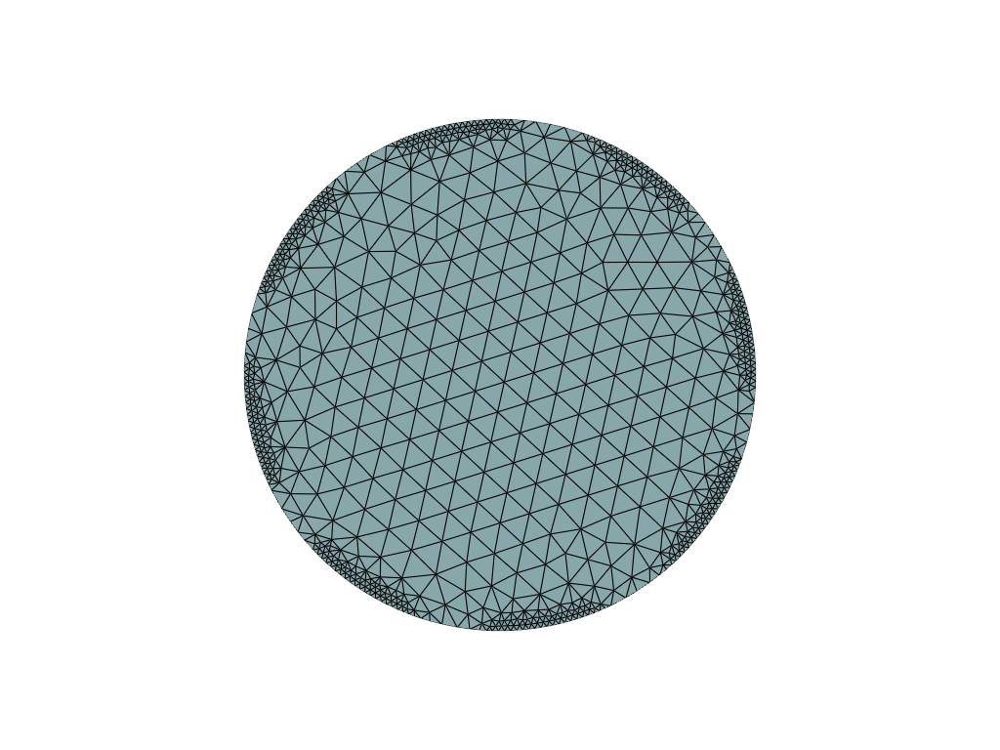

In [9]:
plot_mesh(mesh_inv)

In [10]:
Ve_inv = basix.ufl.element('Lagrange', "triangle", degree=1, shape=())
V_inv = dolfinx.fem.functionspace(mesh_inv, Ve) #creates function space in mesh_inv
V0e_inv = basix.ufl.element('Discontinuous Lagrange', "triangle", degree=0, shape=())
V0_inv = dolfinx.fem.functionspace(mesh_inv, V0e)
z_value = 0.025+0.0025j

problem_inv = DirectProblem(mesh_inv, L, ds_inv)
problem_inv_adj = DirectProblem(mesh_inv, L, ds_inv)

In [11]:
#interpolating gamma to V0_inv
gamma_inv = dolfinx.fem.Function(V0_inv)
gamma_inv.interpolate(gamma,nmm_interpolation_data=dolfinx.fem.create_nonmatching_meshes_interpolation_data(
    mesh_inv,
    V0_inv.element,
    mesh))

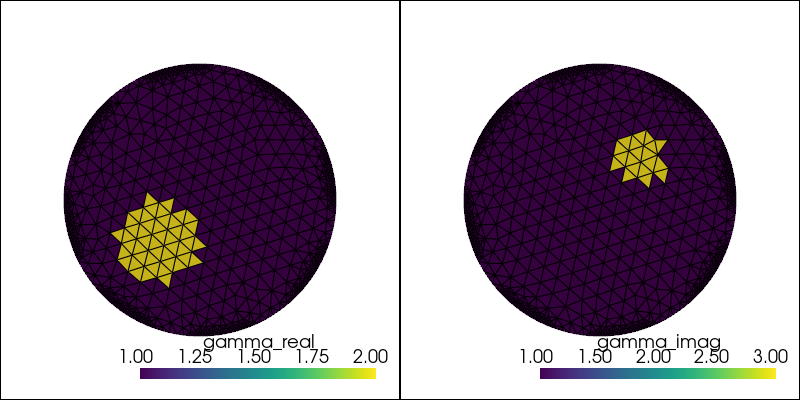

In [12]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_inv.x.array.real
grid.cell_data["gamma_imag"] = gamma_inv.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


## Landweber

### Using Jacobian

In [101]:

#starting gamma_k and its conjugate
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)
gamma_k = gamma0
gamma_k_conj = dolfinx.fem.Function(V0_inv)

#LW parameters
step = 200
n_iter = 10

#starting error and residual arrays
err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

#Setup for Jacobian
v = ufl.TrialFunction(V0_inv)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
id_matrix = np.eye(L) - 1/L

for i in range(n_iter):
  problem_inv.set_problem(gamma_k,z_value)

  uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
  Uk_array = np.array(Uk_list).flatten()

  error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
  err_array[i] = dolfinx.fem.assemble_scalar(error_form).real**0.5

  res_array[i] = np.linalg.norm(Uk_array - U_array)

  residual_list = np.split(Uk_array-U_array,l)

  ### COMPUTE JACOBIAN
  gamma_k_conj.x.array[:] = np.conj(gamma_k.x.array)
  problem_inv_adj.set_problem(gamma_k_conj,np.conj(z_value))
  u_conj_list, U_conj_list = problem_inv.solve_problem_current(I_all)

  y_list, Y_list = problem_inv_adj.solve_problem_current(list(id_matrix))
  grad_y_list = [compute_gradient(y_func) for y_func in y_list]
  grad_u_list = [compute_gradient(u) for u in u_conj_list]
  M = V0_inv.dofmap.index_map.size_global

  Jacobian = np.zeros((l*L,M),dtype=np.complex128)
  for j in range(M):
    # print("Starting iteration ",j)
    for i in range(l):
      gradus = grad_u_list[i]
      graduj = gradus[j]
      jac_column_j = [np.vdot(grady[j],graduj)*cell_area_array[j] for grady in grad_y_list]
      Jacobian[L*i:L*(i+1),j] = - np.array(jac_column_j)
  adj.x.array[:] = Jacobian.T.conj() @ (Uk_array-U_array)


  ## UPDATE GAMMA_K
  gamma_k.x.array[:] = gamma_k.x.array - step*adj.x.array



KeyboardInterrupt: 

In [35]:
problem_inv.set_problem(gamma_k,z_value)

uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
Uk_array = np.array(Uk_list).flatten()

error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
err_array[-1] = dolfinx.fem.assemble_scalar(error_form).real**0.5

res_array[-1] = np.linalg.norm(Uk_array - U_array)

Text(0.5, 0.98, 'Comparação')

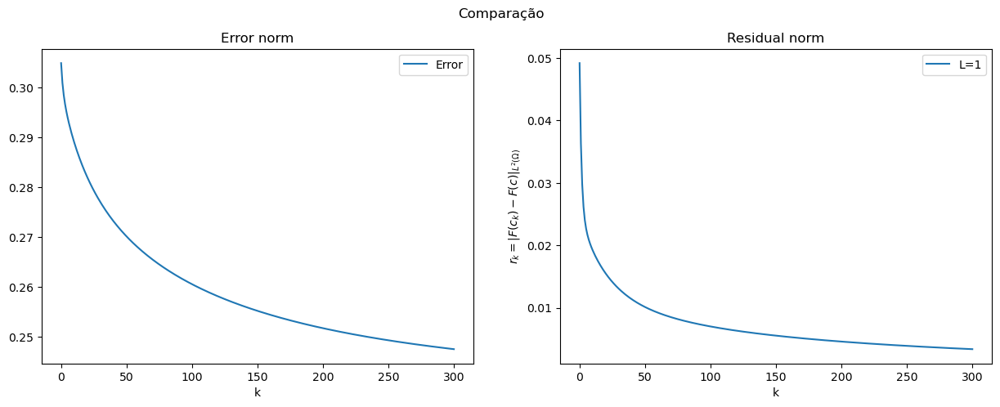

In [36]:
gamma_norm = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(gamma_inv, gamma_inv)*ufl.dx)).real**0.5
U_norm = np.linalg.norm(U_array)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array/gamma_norm,label='Error')
ax[0].set_title("Error norm")
ax[0].set_xlabel("k")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array/U_norm,label ='L=1')
ax[1].set_title("Residual norm")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparação")

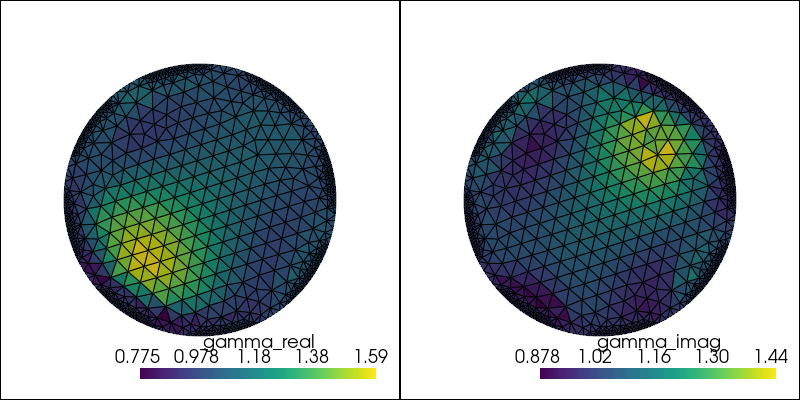

In [37]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_k.x.array.real
grid.cell_data["gamma_imag"] = gamma_k.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


### Using adjoint

In [ ]:
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)

step = 2.25
n_iter = 250

err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

gamma_k = gamma0
gamma_k_conj = dolfinx.fem.Function(V0_inv)


for i in range(n_iter):
  problem_inv.set_problem(gamma_k,z_value)

  uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
  Uk_array = np.array(Uk_list).flatten()

  error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
  err_array[i] = dolfinx.fem.assemble_scalar(error_form).real**0.5
  res_array[i] = np.linalg.norm(Uk_array - U_array)
  residual_list = np.split(Uk_array-U_array,l)

  ### COMPUTE ADJOINT
  gamma_k_conj.x.array[:] = np.conj(gamma_k.x.array)
  problem_inv_adj.set_problem(gamma_k_conj,np.conj(z_value))
  psi_list, Psi_list  = problem_inv_adj.solve_problem_current(residual_list)
  grad_psi_list = [compute_gradient(psi) for psi in psi_list]
  grad_u_list = [compute_gradient(u) for u in uk_list]
  adj_j_array = np.zeros_like(adj.x.array)
  adj.x.array[:] = 0
  for j in range(l):
    graduj = grad_u_list[j]
    gradpsij = grad_psi_list[j]
    for k in range(adj_j_array.shape[0]):
      adj_j_array[k] = - np.vdot(graduj[k],gradpsij[k])
    adj.x.array[:] += adj_j_array

  ## UPDATE GAMMA_K
  gamma_k.x.array[:] = gamma_k.x.array - step*adj.x.array



In [ ]:
problem_inv.set_problem(gamma_k,z_value)

uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
Uk_array = np.array(Uk_list).flatten()

error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
err_array[-1] = dolfinx.fem.assemble_scalar(error_form).real**0.5

res_array[-1] = np.linalg.norm(Uk_array - U_array)

Text(0.5, 0.98, 'Comparação')

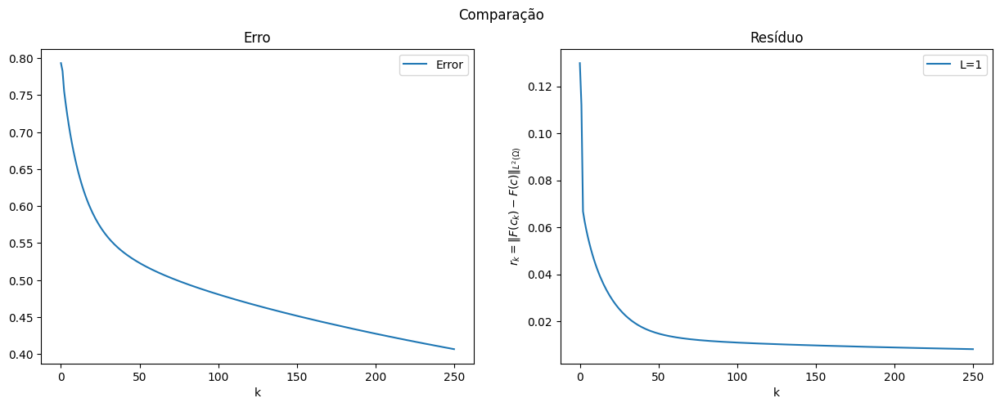

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array,label='Error')
ax[0].set_title("Erro")
ax[0].set_xlabel("k")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array,label ='L=1')
ax[1].set_title("Resíduo")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparação")

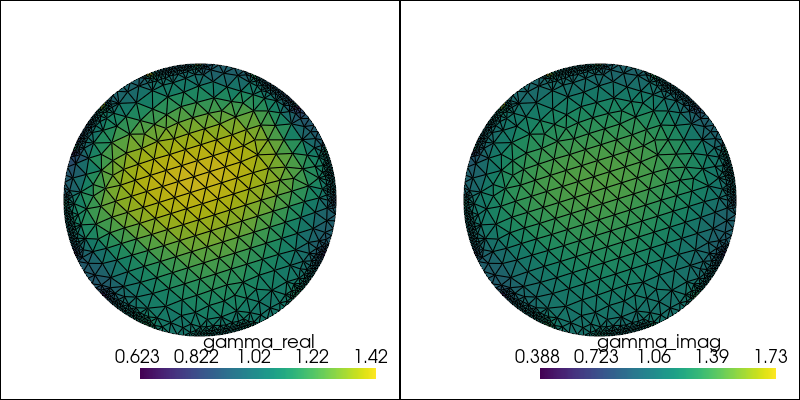

In [ ]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_k.x.array.real
grid.cell_data["gamma_imag"] = gamma_k.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


## Levenberg Marquardt

### Jacobian

In [103]:
#starting gamma_k and its conjugate
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)
gamma_k = gamma0
gamma_k_conj = dolfinx.fem.Function(V0_inv)

#LM parameters
alpha =  1e-5
alpha_ratio = 0.75
n_iter = 10

#starting error and residual arrays
err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

#Setup for Jacobian
v = ufl.TrialFunction(V0_inv)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
id_matrix = np.eye(L) - 1/L
M = V0_inv.dofmap.index_map.size_global
l = len(I_all)

for i in range(n_iter):
  #compute gamma_k
  problem_inv.set_problem(gamma_k,z_value)
  uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
  Uk_array = np.array(Uk_list).flatten()

  #compute error and residual
  error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
  err_array[i] = dolfinx.fem.assemble_scalar(error_form).real**0.5
  res_array[i] = np.linalg.norm(Uk_array - U_array)

  residual = Uk_array-U_array
  residual_list = np.split(residual,l)


  ### COMPUTE JACOBIAN
  gamma_k_conj.x.array[:] = np.conj(gamma_k.x.array)
  problem_inv_adj.set_problem(gamma_k_conj,np.conj(z_value))
  y_list, Y_list = problem_inv_adj.solve_problem_current(list(id_matrix))
  grad_y_list = [compute_gradient(y_func) for y_func in y_list]
  grad_u_list = [compute_gradient(u) for u in uk_list]

  Jacobian = np.zeros((l*L,M),dtype=np.complex128)
  for h in range(l): #For each experiment
    derivada=[]
    for j in range(L): #for each electrode
      Jacobian[h*L+j] = -1*np.sum(grad_u_list[h]*grad_y_list[j].conj(), axis=1)*cell_area_array
  # for j in range(M):
  #   # print("Starting iteration ",j)
  #   for i in range(l):
  #     gradus = grad_u_list[i]
  #     graduj = gradus[j]
  #     jac_column_j = [np.vdot(grady[j],graduj)*cell_area_array[j] for grady in grad_y_list]
  #     Jacobian[L*i:L*(i+1),j] = - np.array(jac_column_j)

  sk_array = np.linalg.solve(Jacobian.T.conj()@Jacobian + alpha * np.eye(M,M),Jacobian.T.conj()@(-residual))
  alpha *= alpha_ratio

  ## UPDATE GAMMA_K
  gamma_k.x.array[:] = gamma_k.x.array + sk_array



In [104]:
problem_inv.set_problem(gamma_k,z_value)

uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
Uk_array = np.array(Uk_list).flatten()

error_form = dolfinx.fem.form(ufl.inner(gamma_k-gamma_inv, gamma_k-gamma_inv)*ufl.dx)
err_array[-1] = dolfinx.fem.assemble_scalar(error_form).real**0.5

res_array[-1] = np.linalg.norm(Uk_array - U_array)

Text(0.5, 0.98, 'Comparação')

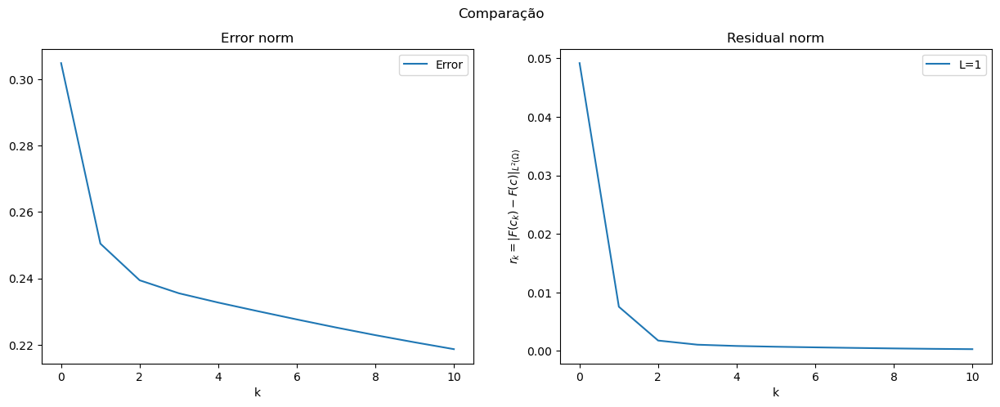

In [105]:
gamma_norm = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(gamma_inv, gamma_inv)*ufl.dx)).real**0.5
U_norm = np.linalg.norm(U_array)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array/gamma_norm,label='Error')
ax[0].set_title("Error norm")
ax[0].set_xlabel("k")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array/U_norm,label ='L=1')
ax[1].set_title("Residual norm")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparação")

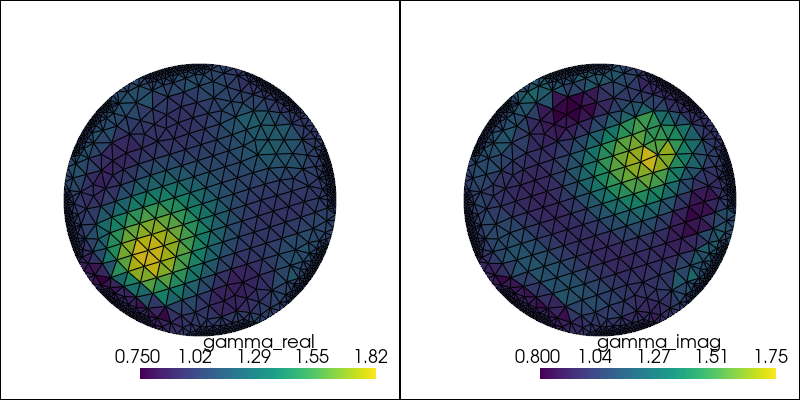

In [106]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_k.x.array.real
grid.cell_data["gamma_imag"] = gamma_k.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


### Adjoint+CG

In [ ]:
tikhonovOp(gamma_inv,problem_inv, uk_list,alpha)

NameError: name 'uk_list' is not defined

In [ ]:
!rm /root/.cache/fenics/libffcx_forms_ef797f98a253bef711f46ff579ffdc3387b823f5.c

Text(0.5, 0.98, 'Comparação')

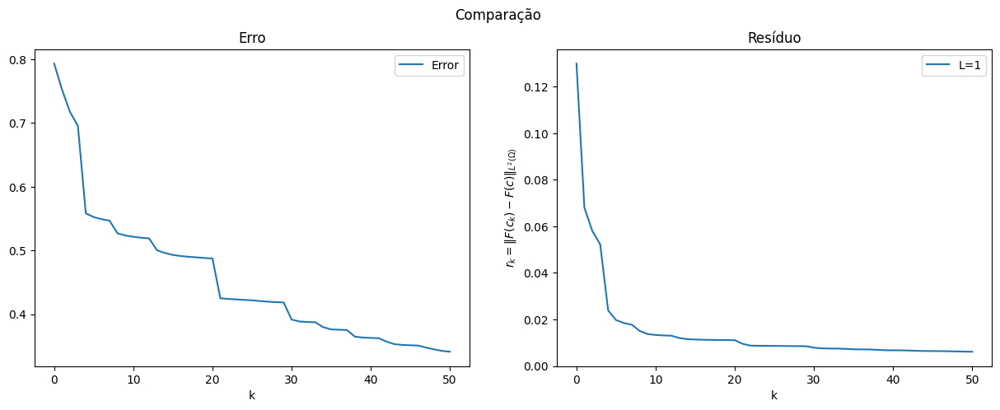

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array,label='Error')
ax[0].set_title("Erro")
ax[0].set_xlabel("k")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array,label ='L=1')
ax[1].set_title("Resíduo")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparação")

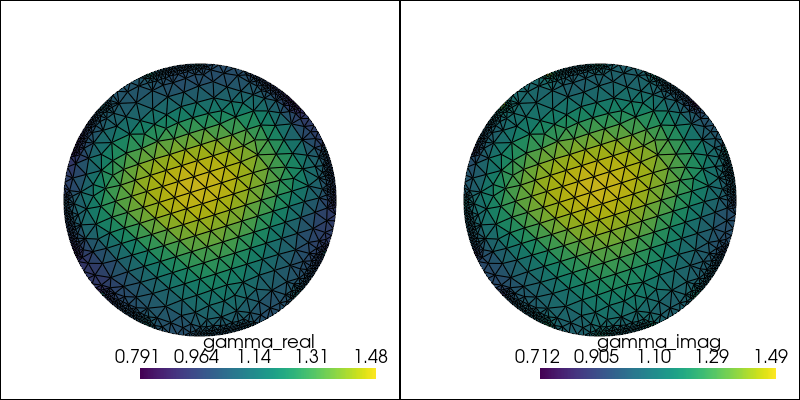

In [ ]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_k.x.array.real
grid.cell_data["gamma_imag"] = gamma_k.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


## REGINN -Gradient

In [53]:
#starting gamma_n and its conjugate
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)
gamma_n = gamma0
gamma_n_conj = dolfinx.fem.Function(V0_inv)

#REGINN parameters
n_iter = 20

#starting error and residual arrays
err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

#Setup for Jacobian
v = ufl.TrialFunction(V0_inv)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
id_matrix = np.eye(L) - 1/L
M = V0_inv.dofmap.index_map.size_global
l = len(I_all)

for n in range(n_iter):
  #compute gamma_n
  problem_inv.set_problem(gamma_n,z_value)
  uk_list, Uk_list = problem_inv.solve_problem_current(I_all)
  Uk_array = np.array(Uk_list).flatten()

  #compute error and residual
  error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
  err_array[n] = dolfinx.fem.assemble_scalar(error_form).real**0.5
  res_array[n] = np.linalg.norm(Uk_array - U_array)

  residual = Uk_array-U_array
  residual_list = np.split(residual,l)


  ### COMPUTE JACOBIAN
  gamma_n_conj.x.array[:] = np.conj(gamma_n.x.array)
  problem_inv_adj.set_problem(gamma_n_conj,np.conj(z_value))
  y_list, Y_list = problem_inv_adj.solve_problem_current(list(id_matrix))
  grad_y_list = [compute_gradient(y_func) for y_func in y_list]
  grad_u_list = [compute_gradient(u) for u in uk_list]

  Jacobian = np.zeros((l*L,M),dtype=np.complex128)
  for h in range(l): #For each experiment
    derivada=[]
    for j in range(L): #for each electrode
      Jacobian[h*L+j] = -1*np.sum(grad_u_list[h]*grad_y_list[j].conj(), axis=1)*cell_area_array


  #Compute sn
  sn_array = np.zeros_like(gamma_n.x.array)
  k = 0
  mu = 0.9
  bn = - residual

  inside_residual = Jacobian @ sn_array - bn
  lambda_k = 100

  while np.linalg.norm(inside_residual) >= mu * res_array[n] and k<15:
    k+=1
    inside_residual = Jacobian @ sn_array - bn
    sn_array -= lambda_k * Jacobian.T.conj() @ (inside_residual)
  print("Inner step:", k+1)


  ## UPDATE GAMMA_n
  gamma_n.x.array[:] = gamma_n.x.array + sn_array


#compute error and residual
error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
err_array[-1] = dolfinx.fem.assemble_scalar(error_form).real**0.5
res_array[-1] = np.linalg.norm(Uk_array - U_array)

residual = Uk_array-U_array
residual_list = np.split(residual,l)



Text(0.5, 0.98, 'Comparação')

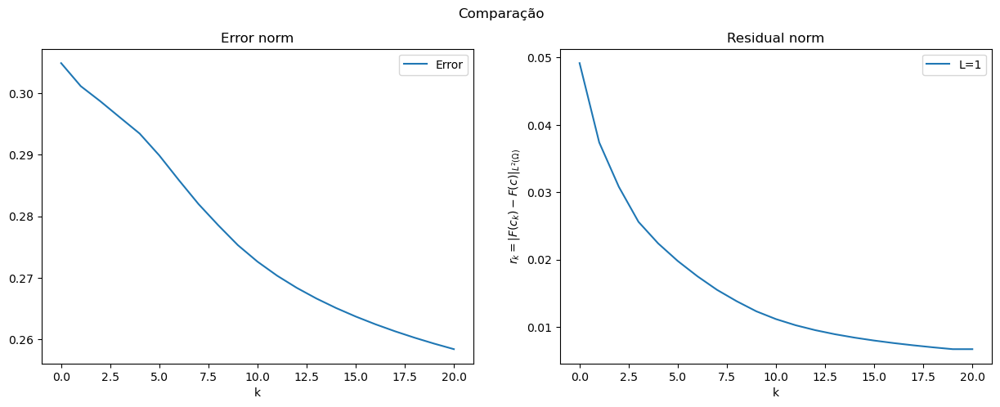

In [54]:
gamma_norm = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(gamma_inv, gamma_inv)*ufl.dx)).real**0.5
U_norm = np.linalg.norm(U_array)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array/gamma_norm,label='Error')
ax[0].set_title("Error norm")
ax[0].set_xlabel("k")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array/U_norm,label ='L=1')
ax[1].set_title("Residual norm")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparação")


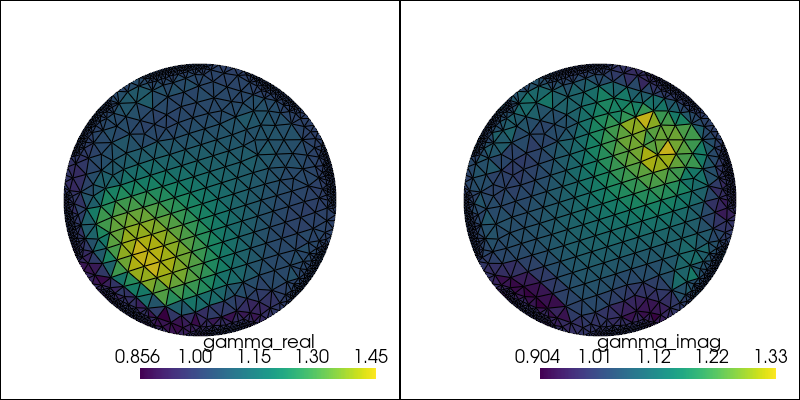

In [55]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_n.x.array.real
grid.cell_data["gamma_imag"] = gamma_n.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


## Noisy data

In [13]:
u_norm = np.linalg.norm(U_array)
Delta = np.random.uniform(-1,1,U_array.shape[0]) + 1j*np.random.uniform(-1,1,U_array.shape[0])
Delta = Delta/np.linalg.norm(Delta)
print(Delta)

[-0.00042244-0.03524738j -0.01639997-0.06220403j  0.14637525+0.09591173j
 -0.1498395 +0.0274384j  -0.05715574-0.11002855j -0.130643  +0.06177951j
  0.12222945-0.09690543j -0.15365177+0.13265466j -0.1503159 -0.10589835j
  0.00613413-0.14754489j  0.00078653-0.04500328j -0.11749465-0.06095866j
  0.15671568-0.14947728j -0.09666125+0.09449659j  0.01496273+0.12044083j
  0.08764079-0.12997473j -0.15332917-0.03680412j  0.07597851+0.04689073j
 -0.15299342+0.04647814j -0.14276754-0.05646528j -0.00872486-0.00346453j
  0.04235385+0.12093677j  0.06796677+0.04670412j -0.02024447-0.04794677j
 -0.00760358+0.01063341j  0.11844701-0.10640704j -0.06037023+0.09074824j
  0.07741974-0.09398297j  0.12677982-0.10873529j  0.15578343+0.12535618j
  0.0843662 +0.05303175j  0.14951738+0.03759759j -0.06520255-0.12805201j
  0.00838656+0.0589041j  -0.11742006-0.0296011j   0.0646012 -0.07645661j
  0.07036289-0.14799631j -0.02496945+0.07286758j  0.11260185-0.0877452j
 -0.08564698-0.13375404j -0.08694226+0.03790175j -0.

In [14]:
delta_r = 0.02
U_delta = U_array + delta_r * Delta * u_norm

Text(0.5, 0.98, 'Potential Data Noise ($U - U^\\delta$) for $\\delta =$ 2.0%')

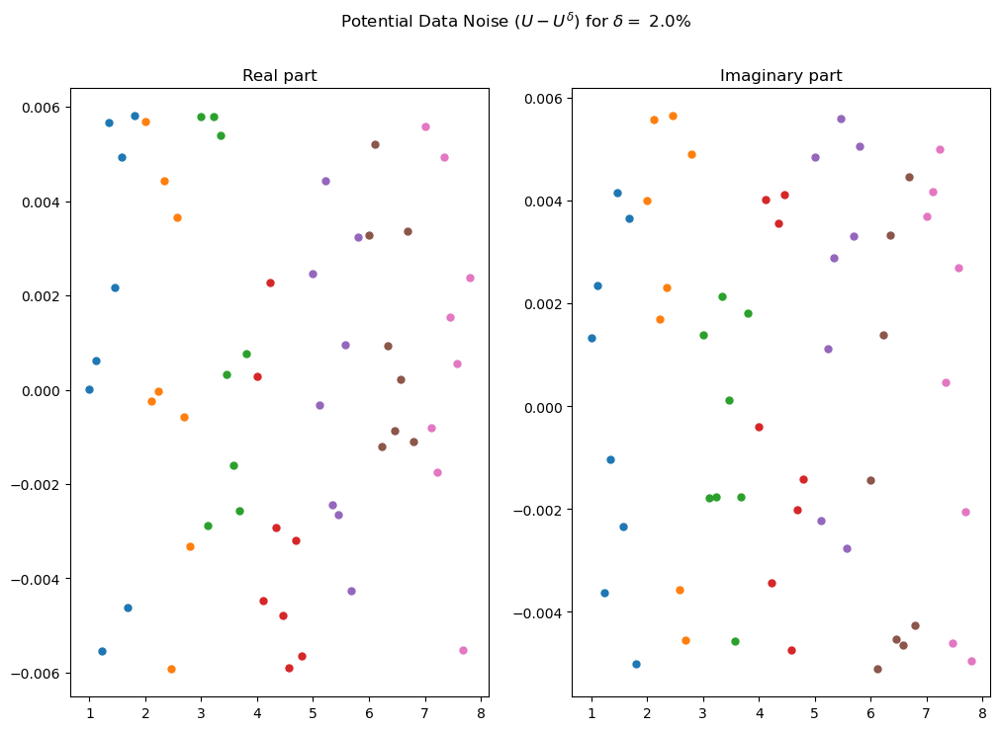

In [25]:
fig, ax = plt.subplots(1,2,figsize=(12,8))

U_list = np.split(U_array,l)
U_delta_list = np.split(U_delta,l)

for i, U_vec in enumerate(zip(U_list,U_delta_list)):
    x = np.linspace(1,1.8,L)+i
    ax[0].plot(x,U_vec[0].real-U_vec[1].real, linewidth=1.3, linestyle='', marker='.', markersize=10);
    # ax[0].plot(x,U_vec[1].real, linewidth=1.3, linestyle='', marker='.',linestyle='--', markersize=10);
    ax[0].set_title('Real part')

    ax[1].plot(x,U_vec[0].imag-U_vec[1].imag, linewidth=1.3, linestyle='', marker='.', markersize=10);
    # ax[1].plot(x,U_vec[1].imag, linewidth=1.3, marker='.',linestyle='--', markersize=10);
    ax[1].set_title('Imaginary part')

fig.suptitle(f"Potential Data Noise ($U - U^\delta$) for $\delta =$ {delta_r*100}%")
# plt.xticks(np.arange(1,l+1,1))

### Landweber

In [21]:
#starting gamma_n and its conjugate
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)
gamma_n = gamma0
gamma_n_conj = dolfinx.fem.Function(V0_inv)

#LW parameters
step = 200
n_iter = 50
tau = 1.005

#starting error and residual arrays
err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

#Setup for Jacobian
v = ufl.TrialFunction(V0_inv)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
id_matrix = np.eye(L) - 1/L

n=0

while n<n_iter:

    problem_inv.set_problem(gamma_n,z_value)

    un_list, Un_list = problem_inv.solve_problem_current(I_all)
    Un_array = np.array(Un_list).flatten()
    residual_norm = np.linalg.norm(Un_array - U_delta)

    error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
    err_array[n] = dolfinx.fem.assemble_scalar(error_form).real**0.5
    res_array[n] = residual_norm

    #check discrepancy
    if residual_norm/u_norm <= tau*delta_r:
        break

    residual_list = np.split(Un_array-U_delta,l)

    ### COMPUTE JACOBIAN
    gamma_n_conj.x.array[:] = np.conj(gamma_n.x.array)
    problem_inv_adj.set_problem(gamma_n_conj,np.conj(z_value))
    u_conj_list, U_conj_list = problem_inv.solve_problem_current(I_all)

    y_list, Y_list = problem_inv_adj.solve_problem_current(list(id_matrix))
    grad_y_list = [compute_gradient(y_func) for y_func in y_list]
    grad_u_list = [compute_gradient(u) for u in u_conj_list]
    M = V0_inv.dofmap.index_map.size_global

    Jacobian = np.zeros((l*L,M),dtype=np.complex128)
    for j in range(M):
    # print("Starting iteration ",j)
        for i in range(l):
            gradus = grad_u_list[i]
            graduj = gradus[j]
            jac_column_j = [np.vdot(grady[j],graduj)*cell_area_array[j] for grady in grad_y_list]
            Jacobian[L*i:L*(i+1),j] = - np.array(jac_column_j)
        adj.x.array[:] = Jacobian.T.conj() @ (Un_array-U_delta)

    ## UPDATE GAMMA_n
    gamma_n.x.array[:] = gamma_n.x.array - step*adj.x.array

    #update n
    n+=1
  
problem_inv.set_problem(gamma_n,z_value)
un_list, Un_list = problem_inv.solve_problem_current(I_all)
Un_array = np.array(Un_list).flatten()
error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
err_array[n] = dolfinx.fem.assemble_scalar(error_form).real**0.5
res_array[n] = np.linalg.norm(Un_array - U_delta)

n stop index: 50


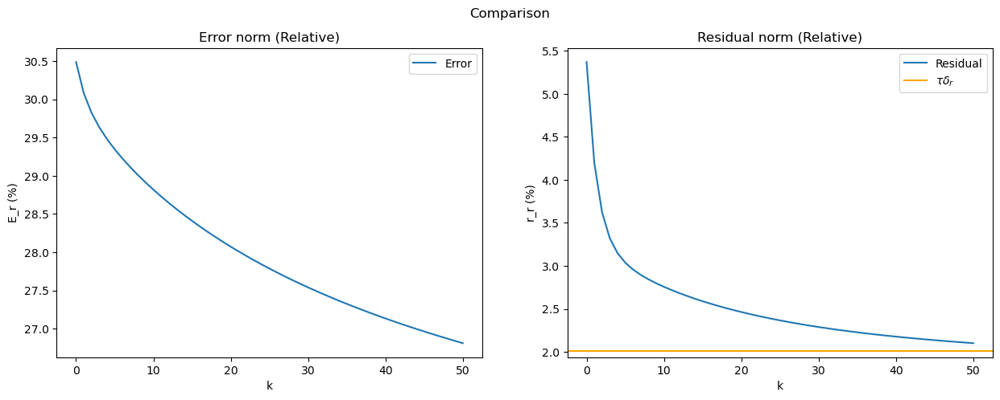

In [32]:
print("n stop index:",n)
gamma_norm = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(gamma_inv, gamma_inv)*ufl.dx)).real**0.5
U_delta_norm = np.linalg.norm(U_delta)
U_norm = np.linalg.norm(U_array)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array[:n+1]/gamma_norm * 100,label='Error')
ax[0].set_title("Error norm (Relative)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("E_r (%)")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array[:n+1]/U_delta_norm * 100,label ='Residual')
ax[1].axhline(tau*delta_r*100,label ='$\\tau \delta_r$',color='orange')
ax[1].set_title("Residual norm (Relative)")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
ax[1].set_ylabel("r_r (%)")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparison")
plt.show()

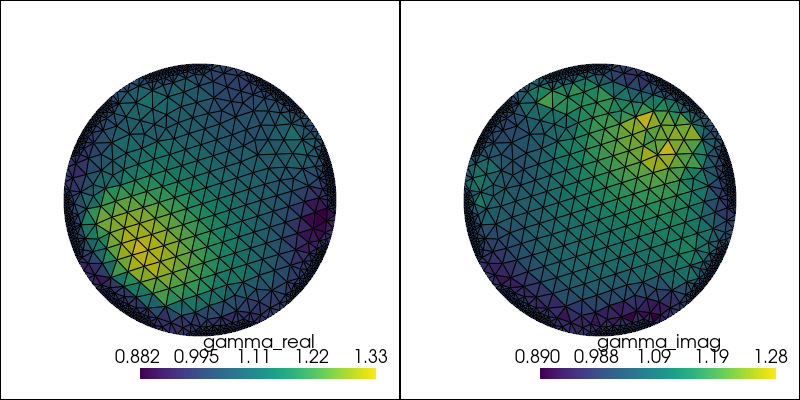

In [33]:
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_n.x.array.real
grid.cell_data["gamma_imag"] = gamma_n.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


### LM

In [34]:
#starting gamma_n and its conjugate
gamma0  = dolfinx.fem.Function(V0_inv)
gamma0.x.array[:] = 1+1j
adj = dolfinx.fem.Function(V0_inv)
gamma_n = gamma0
gamma_n_conj = dolfinx.fem.Function(V0_inv)

#LM parameters
alpha =  1e-5
alpha_ratio = 0.75
n_iter = 50
tau = 1.005

#starting error and residual arrays
err_array = np.zeros(n_iter+1)
res_array = np.zeros(n_iter+1)

#Setup for Jacobian
v = ufl.TrialFunction(V0_inv)
cell_area_form = dolfinx.fem.form(v*ufl.dx)
cell_area = dolfinx.fem.assemble_vector(cell_area_form)
cell_area_array = cell_area.array.real
id_matrix = np.eye(L) - 1/L
M = V0_inv.dofmap.index_map.size_global
l = len(I_all)

U_delta_norm = np.linalg.norm(U_delta)

n=0
while n<n_iter:
  #compute gamma_n
  problem_inv.set_problem(gamma_n,z_value)
  un_list, Un_list = problem_inv.solve_problem_current(I_all)
  Un_array = np.array(Un_list).flatten()

  #compute error and residual
  error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
  err_array[n] = dolfinx.fem.assemble_scalar(error_form).real**0.5
  residual = Un_array-U_delta
  residual_norm = np.linalg.norm(Un_array-U_delta)
  res_array[n] = residual_norm

  #check discrepancy
  if residual_norm/U_delta_norm <= tau*delta_r:
    break

  ### COMPUTE JACOBIAN
  gamma_n_conj.x.array[:] = np.conj(gamma_n.x.array)
  problem_inv_adj.set_problem(gamma_n_conj,np.conj(z_value))
  y_list, Y_list = problem_inv_adj.solve_problem_current(list(id_matrix))
  grad_y_list = [compute_gradient(y_func) for y_func in y_list]
  grad_u_list = [compute_gradient(u) for u in un_list]

  Jacobian = np.zeros((l*L,M),dtype=np.complex128)
  for h in range(l): #For each experiment
    derivada=[]
    for j in range(L): #for each electrode
      Jacobian[h*L+j] = -1*np.sum(grad_u_list[h]*grad_y_list[j].conj(), axis=1)*cell_area_array

  sn_array = np.linalg.solve(Jacobian.T.conj()@Jacobian + alpha * np.eye(M,M),Jacobian.T.conj()@(-residual))
  alpha *= alpha_ratio

  ## UPDATE GAMMA_n
  gamma_n.x.array[:] = gamma_n.x.array + sn_array
  n+=1

problem_inv.set_problem(gamma_n,z_value)
un_list, Un_list = problem_inv.solve_problem_current(I_all)
Un_array = np.array(Un_list).flatten()
error_form = dolfinx.fem.form(ufl.inner(gamma_n-gamma_inv, gamma_n-gamma_inv)*ufl.dx)
err_array[n] = dolfinx.fem.assemble_scalar(error_form).real**0.5
res_array[n] = np.linalg.norm(Un_array - U_delta)

n stop index: 1


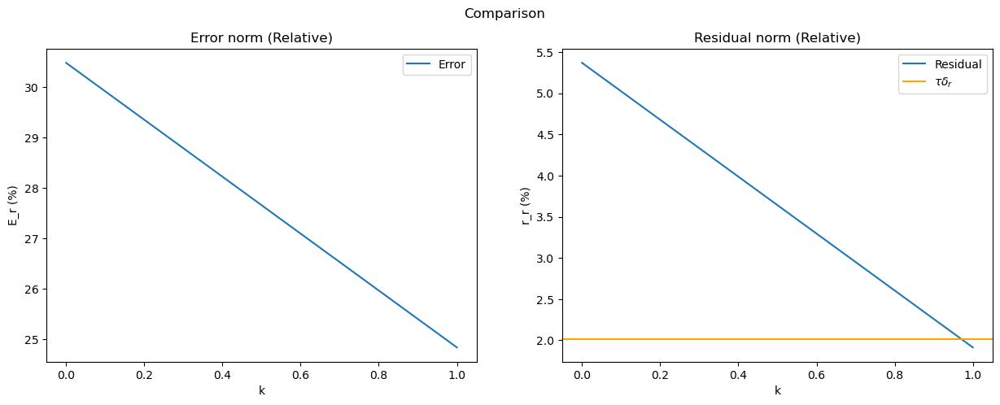

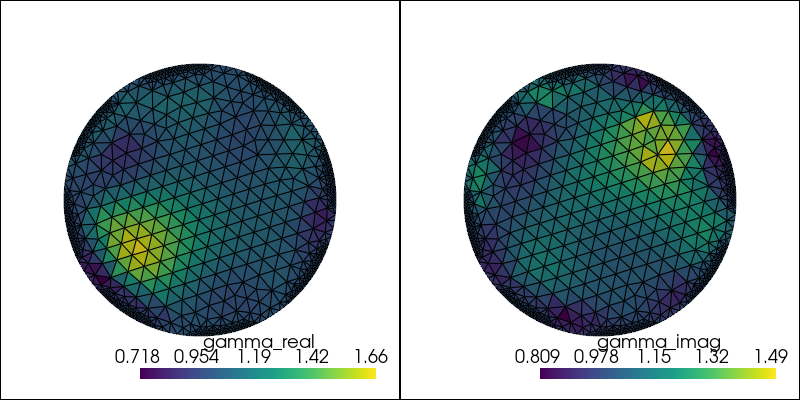

In [36]:
print("n stop index:",n)
gamma_norm = dolfinx.fem.assemble_scalar(dolfinx.fem.form(ufl.inner(gamma_inv, gamma_inv)*ufl.dx)).real**0.5
U_delta_norm = np.linalg.norm(U_delta)
U_norm = np.linalg.norm(U_array)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].plot(err_array[:n+1]/gamma_norm * 100,label='Error')
ax[0].set_title("Error norm (Relative)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("E_r (%)")
# ax[0].set_yscale("log")
ax[0].legend()

ax[1].plot(res_array[:n+1]/U_delta_norm * 100,label ='Residual')
ax[1].axhline(tau*delta_r*100,label ='$\\tau \delta_r$',color='orange')
ax[1].set_title("Residual norm (Relative)")
ax[1].set_ylabel("$r_k = \|F(c_k) - F(c)\|_{L^2(\Omega)}$")
ax[1].set_xlabel("k")
ax[1].set_ylabel("r_r (%)")
# ax[1].set_yscale("log")
ax[1].legend()

fig.suptitle("Comparison")
plt.show()

pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh_inv,dim=2))
# grid = pyvista.UnstructuredGrid(pyvista_cells, cell_types, geometry)

grid.cell_data["gamma_real"] = gamma_n.x.array.real
grid.cell_data["gamma_imag"] = gamma_n.x.array.imag
# p.add_text("U real solution", position="upper_edge", font_size=14, color="black")
p = pyvista.Plotter(shape=(1,2),notebook=True,window_size=(800,400))#,shape=(1,2),)

p.subplot(0,0)
p.add_mesh(grid,scalars="gamma_real",show_edges=True,copy_mesh=True)
p.view_xy()
p.subplot(0,1)
p.add_mesh(grid,scalars="gamma_imag",show_edges=True,copy_mesh=True)
p.view_xy()
p.set_background("white")
if not pyvista.OFF_SCREEN:
    p.show(jupyter_backend="static")


# Extra tests

## Theta paramether location

In [ ]:
t = np.linspace(0,2*np.pi,40)
x = np.array([np.cos(t),np.sin(t)])
np.where(theta(x)>=electrodes.position[14][0],1,0)
boundaries =[
    (i, lambda x,i=i: np.where(theta(x)>=electrodes.position[i][0],1,0))
    for i in range(L)
]
boundaries[1][1](x)